# Analytics of ML Features Usage in IDEs

## Executive Summary

This analysis examines user activity data for Large Language Model (LLM) features in IDEs over a three-month period (March-May 2025). The dataset contains user interactions across different models, features, license types, along with request counts and spending metrics.

**Key objectives:**
- Understand user behavior patterns and engagement
- Analyze relationships between models, features, and licenses
- Identify trends and usage patterns over time
- Provide actionable business recommendations

---

## 0. Environment Setup

In [1]:
import sys
import os

# Detect the execution environment (Colab or Local)
try:
    import google.colab
    IN_COLAB = True
    print("Running in: Google Colab")
except ImportError:
    IN_COLAB = False
    print("Running in: Local Environment")

# Configure dependencies
REQUIREMENTS_FILE = "requirements.txt"

if IN_COLAB:
    # Install the dependencies in Colab
    print("Colab environment detected. Installing dependencies...")
    
    if os.path.exists(REQUIREMENTS_FILE):
        print(f"-> Installing packages from '{REQUIREMENTS_FILE}'...")
        !pip install -r {REQUIREMENTS_FILE}
    else:
        print(f"'{REQUIREMENTS_FILE}' not found. Installing default packages...")
        !pip install pandas numpy matplotlib seaborn altair
        
    print("Colab setup complete.")

else:
    # WARN the user to install the dependencies in a local environment.
    print("Local environment detected. Checking dependencies...")
    
    if os.path.exists(REQUIREMENTS_FILE):
        print(f"-> This notebook relies on packages listed in '{REQUIREMENTS_FILE}'.")
        print(f"-> To ensure all dependencies are met, run this in your terminal:")
        print(f"   pip install -r {REQUIREMENTS_FILE}")
    else:
        print(f"-> WARNING: '{REQUIREMENTS_FILE}' not found.")
        print("-> Please ensure you have pandas, numpy, matplotlib, seaborn, and altair installed.")

print("\n--- Environment setup finished. ---\n")

Running in: Local Environment
Local environment detected. Checking dependencies...
-> This notebook relies on packages listed in 'requirements.txt'.
-> To ensure all dependencies are met, run this in your terminal:
   pip install -r requirements.txt

--- Environment setup finished. ---



## 1. Setup & Data Loading

In [2]:
# Import required libraries for data analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import altair as alt
from datetime import datetime
import warnings

# Configure visualization settings
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
alt.data_transformers.enable('json')
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries successfully imported and configured")

Libraries successfully imported and configured


In [3]:
# Load the dataset
dataset_file = 'da_internship_task_dataset.csv'

try:
    df = pd.read_csv(dataset_file)
    print(f"Dataset successfully loaded from '{dataset_file}'")
    print(f"Dataset shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"Date range: {df['day_id'].min()} to {df['day_id'].max()}")
except FileNotFoundError:
    print(f"ERROR: File '{dataset_file}' not found.")
    print("Please ensure the dataset is in the same directory as this notebook.")
except Exception as e:
    print(f"Error loading dataset: {e}")
    df = None

Dataset successfully loaded from 'da_internship_task_dataset.csv'
Dataset shape: 122,746 rows x 7 columns
Date range: 2025-03-01 to 2025-05-31


In [4]:
# Display basic dataset information
if df is not None:
    print("=" * 50)
    print("DATASET OVERVIEW")
    print("=" * 50)
    
    # Show first few rows
    print("\nFirst 5 rows:")
    display(df.head())
    
    print("\nDataset Info:")
    df.info()
    
    print("\nStatistical Summary:")
    display(df.describe())

DATASET OVERVIEW

First 5 rows:


,uuid,day_id,license,model,feature,requests_cnt,spent_amount
0,user_920,2025-05-01,Premium,Model_A,Feature_1,44.0,16.38
1,user_717,2025-03-04,Premium,Model_B,Feature_2,72.0,27.92
2,user_610,2025-05-08,Premium,Model_A,Feature_2,27.0,9.87
3,user_94,2025-03-11,Basic,Model_D,Feature_1,76.0,14.67
4,user_920,2025-05-14,Premium,Model_E,Feature_3,47.0,9.88



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122746 entries, 0 to 122745
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   uuid          122746 non-null  object 
 1   day_id        122746 non-null  object 
 2   license       122746 non-null  object 
 3   model         122746 non-null  object 
 4   feature       122746 non-null  object 
 5   requests_cnt  122746 non-null  float64
 6   spent_amount  122746 non-null  float64
dtypes: float64(2), object(5)
memory usage: 6.6+ MB

Statistical Summary:


,requests_cnt,spent_amount
count,122746.000000,122746.000000
mean,51.260742,12.227798
std,167.977380,37.588494
min,1.000000,0.270000
25%,18.000000,5.140000
50%,32.000000,8.020000
75%,54.000000,13.060000
max,12900.000000,2599.000000


## 2. Data Preprocessing

In [5]:
# Data type conversions and preprocessing
print("DATA PREPROCESSING")
print("=" * 50)

# Convert requests_cnt to integer for correctness
df['requests_cnt'] = df['requests_cnt'].astype(int)
print("Converted 'requests_cnt' to integer")

# Convert day_id to datetime
df['day_id'] = pd.to_datetime(df['day_id'])
print("Date conversion completed")

# Create additional time-based features
df['year'] = df['day_id'].dt.year
df['month'] = df['day_id'].dt.month
df['month_name'] = df['day_id'].dt.month_name()
df['day_of_week'] = df['day_id'].dt.day_name()
df['week_number'] = df['day_id'].dt.isocalendar().week

print("Time-based features created:")
print("  - year")
print("  - month (numeric)")
print("  - month_name")
print("  - day_of_week") 
print("  - week_number")

# Create business metrics
df['cost_per_request'] = (df['spent_amount'] / df['requests_cnt']).replace([np.inf, -np.inf], np.nan)
print("Business metrics created:")
print("  - cost_per_request")

# Verify data types after conversion
print(f"\nData types after preprocessing:")
for col, dtype in df.dtypes.items():
    print(f"  {col}: {dtype}")

print(f"\nData quality check:")
print(f"  cost_per_request - min: ${df['cost_per_request'].min():.3f}, max: ${df['cost_per_request'].max():.3f}")
print(f"  cost_per_request - mean: ${df['cost_per_request'].mean():.3f}, median: ${df['cost_per_request'].median():.3f}")

DATA PREPROCESSING
Converted 'requests_cnt' to integer
Date conversion completed
Time-based features created:
  - year
  - month (numeric)
  - month_name
  - day_of_week
  - week_number
Business metrics created:
  - cost_per_request

Data types after preprocessing:
  uuid: object
  day_id: datetime64[ns]
  license: object
  model: object
  feature: object
  requests_cnt: int64
  spent_amount: float64
  year: int32
  month: int32
  month_name: object
  day_of_week: object
  week_number: UInt32
  cost_per_request: float64

Data quality check:
  cost_per_request - min: $0.007, max: $0.640
  cost_per_request - mean: $0.279, median: $0.283


## 3. Data Understanding & Quality Assessment

CATEGORICAL VARIABLES ANALYSIS

LICENSE:
  Unique values: 4
    Basic: 39,233 (32.0%)
    Standard: 37,368 (30.4%)
    Enterprise: 23,516 (19.2%)
    Premium: 22,629 (18.4%)

MODEL:
  Unique values: 5
    Model_A: 38,042 (31.0%)
    Model_C: 24,433 (19.9%)
    Model_D: 24,423 (19.9%)
    Model_B: 23,110 (18.8%)
    Model_E: 12,738 (10.4%)

FEATURE:
  Unique values: 5
    Feature_1: 45,399 (37.0%)
    Feature_2: 36,449 (29.7%)
    Feature_3: 26,283 (21.4%)
    Feature_5: 7,372 (6.0%)
    Feature_4: 7,243 (5.9%)


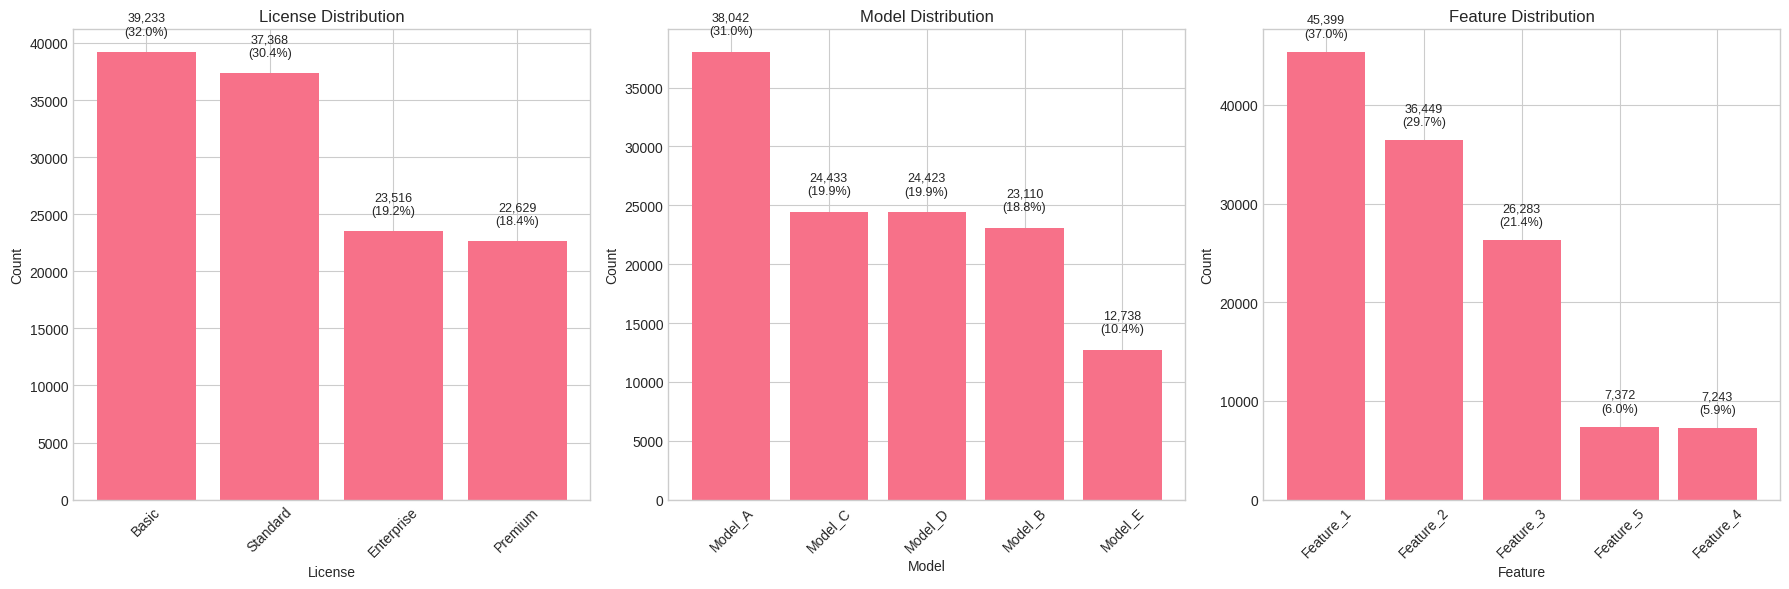

In [6]:
# Categorical variables analysis with visualizations
print("CATEGORICAL VARIABLES ANALYSIS")
print("=" * 50)

# Create visualizations for categorical variables
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

categorical_cols = ['license', 'model', 'feature']

for i, col in enumerate(categorical_cols):
    # Get value counts
    value_counts = df[col].value_counts()
    
    # Create bar plot
    ax = axes[i]
    bars = ax.bar(value_counts.index, value_counts.values)
    ax.set_title(f'{col.title()} Distribution')
    ax.set_xlabel(col.title())
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value labels on bars
    for bar, count in zip(bars, value_counts.values):
        percentage = (count / len(df)) * 100
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + len(df)*0.01, 
                f'{count:,}\n({percentage:.1f}%)', 
                ha='center', va='bottom', fontsize=9)
    
    # Print summary
    print(f"\n{col.upper()}:")
    print(f"  Unique values: {len(value_counts)}")
    for val, count in value_counts.items():
        percentage = (count / len(df)) * 100
        print(f"    {val}: {count:,} ({percentage:.1f}%)")

plt.tight_layout()
plt.show()

In [7]:
# Data quality assessment
print("DATA QUALITY ASSESSMENT")
print("=" * 50)

# Check for missing values
print("\nMissing Values:")
missing_values = df.isnull().sum()
for col, missing in missing_values.items():
    percentage = (missing / len(df)) * 100
    print(f"  {col}: {missing} ({percentage:.2f}%)")

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nDuplicate rows: {duplicates}")

# Check data types
print(f"\nData Types:")
for col, dtype in df.dtypes.items():
    print(f"  {col}: {dtype}")

# Examine user count
unique_users = df['uuid'].nunique()
total_records = len(df)
avg_records_per_user = total_records / unique_users
print(f"\nUser Analysis:")
print(f"  Unique users: {unique_users:,}")
print(f"  Total records: {total_records:,}")
print(f"  Average records per user: {avg_records_per_user:.1f}")

DATA QUALITY ASSESSMENT

Missing Values:
  uuid: 0 (0.00%)
  day_id: 0 (0.00%)
  license: 0 (0.00%)
  model: 0 (0.00%)
  feature: 0 (0.00%)
  requests_cnt: 0 (0.00%)
  spent_amount: 0 (0.00%)
  year: 0 (0.00%)
  month: 0 (0.00%)
  month_name: 0 (0.00%)
  day_of_week: 0 (0.00%)
  week_number: 0 (0.00%)
  cost_per_request: 0 (0.00%)

Duplicate rows: 0

Data Types:
  uuid: object
  day_id: datetime64[ns]
  license: object
  model: object
  feature: object
  requests_cnt: int64
  spent_amount: float64
  year: int32
  month: int32
  month_name: object
  day_of_week: object
  week_number: UInt32
  cost_per_request: float64

User Analysis:
  Unique users: 1,866
  Total records: 122,746
  Average records per user: 65.8


In [8]:
# Analyze date range and time period coverage
print("TIME PERIOD ANALYSIS")
print("=" * 50)

# Basic time analysis (day_id already converted to datetime in preprocessing)
start_date = df['day_id'].min()
end_date = df['day_id'].max()
total_days = (end_date - start_date).days + 1

print(f"\nTime Range:")
print(f"  Start date: {start_date.strftime('%Y-%m-%d')}")
print(f"  End date: {end_date.strftime('%Y-%m-%d')}")
print(f"  Total days: {total_days}")

# Check for date gaps
unique_dates = df['day_id'].nunique()
print(f"  Unique dates in data: {unique_dates}")
print(f"  Coverage: {(unique_dates/total_days)*100:.1f}%")

# Monthly breakdown using the new month_name feature
monthly_records = df['month_name'].value_counts().reindex(['March', 'April', 'May'])
print(f"\nMonthly Record Distribution:")
for month, count in monthly_records.items():
    percentage = (count / len(df)) * 100
    print(f"  {month}: {count:,} records ({percentage:.1f}%)")

TIME PERIOD ANALYSIS

Time Range:
  Start date: 2025-03-01
  End date: 2025-05-31
  Total days: 92
  Unique dates in data: 92
  Coverage: 100.0%

Monthly Record Distribution:
  March: 37,793 records (30.8%)
  April: 38,590 records (31.4%)
  May: 46,363 records (37.8%)


## 4. User Behavior Analysis

In [9]:
# User activity distribution analysis
print("USER ACTIVITY DISTRIBUTION")
print("=" * 50)

# Aggregate user-level statistics
user_stats = df.groupby('uuid').agg({
    'requests_cnt': ['sum', 'mean', 'count'],
    'spent_amount': ['sum', 'mean']
}).round(2)

# Flatten column names
user_stats.columns = ['total_requests', 'avg_requests_per_day', 'active_days', 'total_spent', 'avg_spent_per_day']

# User activity segments
print("\nUser Activity Summary:")
print(f"  Total users: {len(user_stats):,}")
print(f"  Average requests per user: {user_stats['total_requests'].mean():.1f}")
print(f"  Average spending per user: ${user_stats['total_spent'].mean():.2f}")
print(f"  Average active days per user: {user_stats['active_days'].mean():.1f}")

# Activity level segments
segment_distribution = [0, 20, 100, 1000, 10000, np.inf]
def categorize_user_activity(total_requests):
    if total_requests >= segment_distribution[4]:
        return 'Very High Activity'
    elif total_requests >= segment_distribution[3]:
        return 'High Activity'
    elif total_requests >= segment_distribution[2]:
        return 'Medium Activity'
    elif total_requests >= segment_distribution[1]:
        return 'Low Activity'
    else:
        return 'Minimal Activity'

user_stats['activity_level'] = user_stats['total_requests'].apply(categorize_user_activity)
activity_segments = user_stats['activity_level'].value_counts()

print(f"\nUser Activity Segments:")
for segment, count in activity_segments.items():
    percentage = (count / len(user_stats)) * 100
    avg_requests = user_stats[user_stats['activity_level'] == segment]['total_requests'].mean()
    avg_spent = user_stats[user_stats['activity_level'] == segment]['total_spent'].mean()
    print(f"  {segment}: {count:,} users ({percentage:.1f}%) - Avg requests: {avg_requests:.1f}, Avg spend: ${avg_spent:.2f}")

USER ACTIVITY DISTRIBUTION

User Activity Summary:
  Total users: 1,866
  Average requests per user: 3371.9
  Average spending per user: $804.35
  Average active days per user: 65.8

User Activity Segments:
  High Activity: 1,187 users (63.6%) - Avg requests: 3658.7, Avg spend: $901.76
  Medium Activity: 416 users (22.3%) - Avg requests: 442.4, Avg spend: $132.46
  Low Activity: 148 users (7.9%) - Avg requests: 57.1, Avg spend: $17.82
  Very High Activity: 87 users (4.7%) - Avg requests: 20187.2, Avg spend: $4283.29
  Minimal Activity: 28 users (1.5%) - Avg requests: 12.9, Avg spend: $4.85


In [10]:
# Requests vs Spending relationship analysis
print("REQUESTS vs SPENDING CORRELATION ANALYSIS")
print("=" * 50)

# Calculate correlation between requests and spending
correlation = df['requests_cnt'].corr(df['spent_amount'])
print(f"\nOverall correlation between requests and spending: {correlation:.3f}")

# Cost per request analysis (already created in preprocessing)
avg_cost_per_request = df['cost_per_request'].mean()
print(f"Average cost per request: ${avg_cost_per_request:.3f}")

# Cost efficiency by different dimensions
print(f"\nCost per request by License Type:")
license_cost = df.groupby('license')['cost_per_request'].mean().sort_values(ascending=False)
for license_type, cost in license_cost.items():
    print(f"  {license_type}: ${cost:.3f}")

print(f"\nCost per request by Model:")
model_cost = df.groupby('model')['cost_per_request'].mean().sort_values(ascending=False)
for model, cost in model_cost.items():
    print(f"  {model}: ${cost:.3f}")

print(f"\nCost per request by Feature:")
feature_cost = df.groupby('feature')['cost_per_request'].mean().sort_values(ascending=False)
for feature, cost in feature_cost.items():
    print(f"  {feature}: ${cost:.3f}")

REQUESTS vs SPENDING CORRELATION ANALYSIS

Overall correlation between requests and spending: 0.944
Average cost per request: $0.279

Cost per request by License Type:
  Standard: $0.282
  Basic: $0.279
  Enterprise: $0.277
  Premium: $0.276

Cost per request by Model:
  Model_A: $0.369
  Model_B: $0.366
  Model_D: $0.192
  Model_E: $0.190
  Model_C: $0.190

Cost per request by Feature:
  Feature_3: $0.283
  Feature_5: $0.282
  Feature_2: $0.280
  Feature_4: $0.277
  Feature_1: $0.276


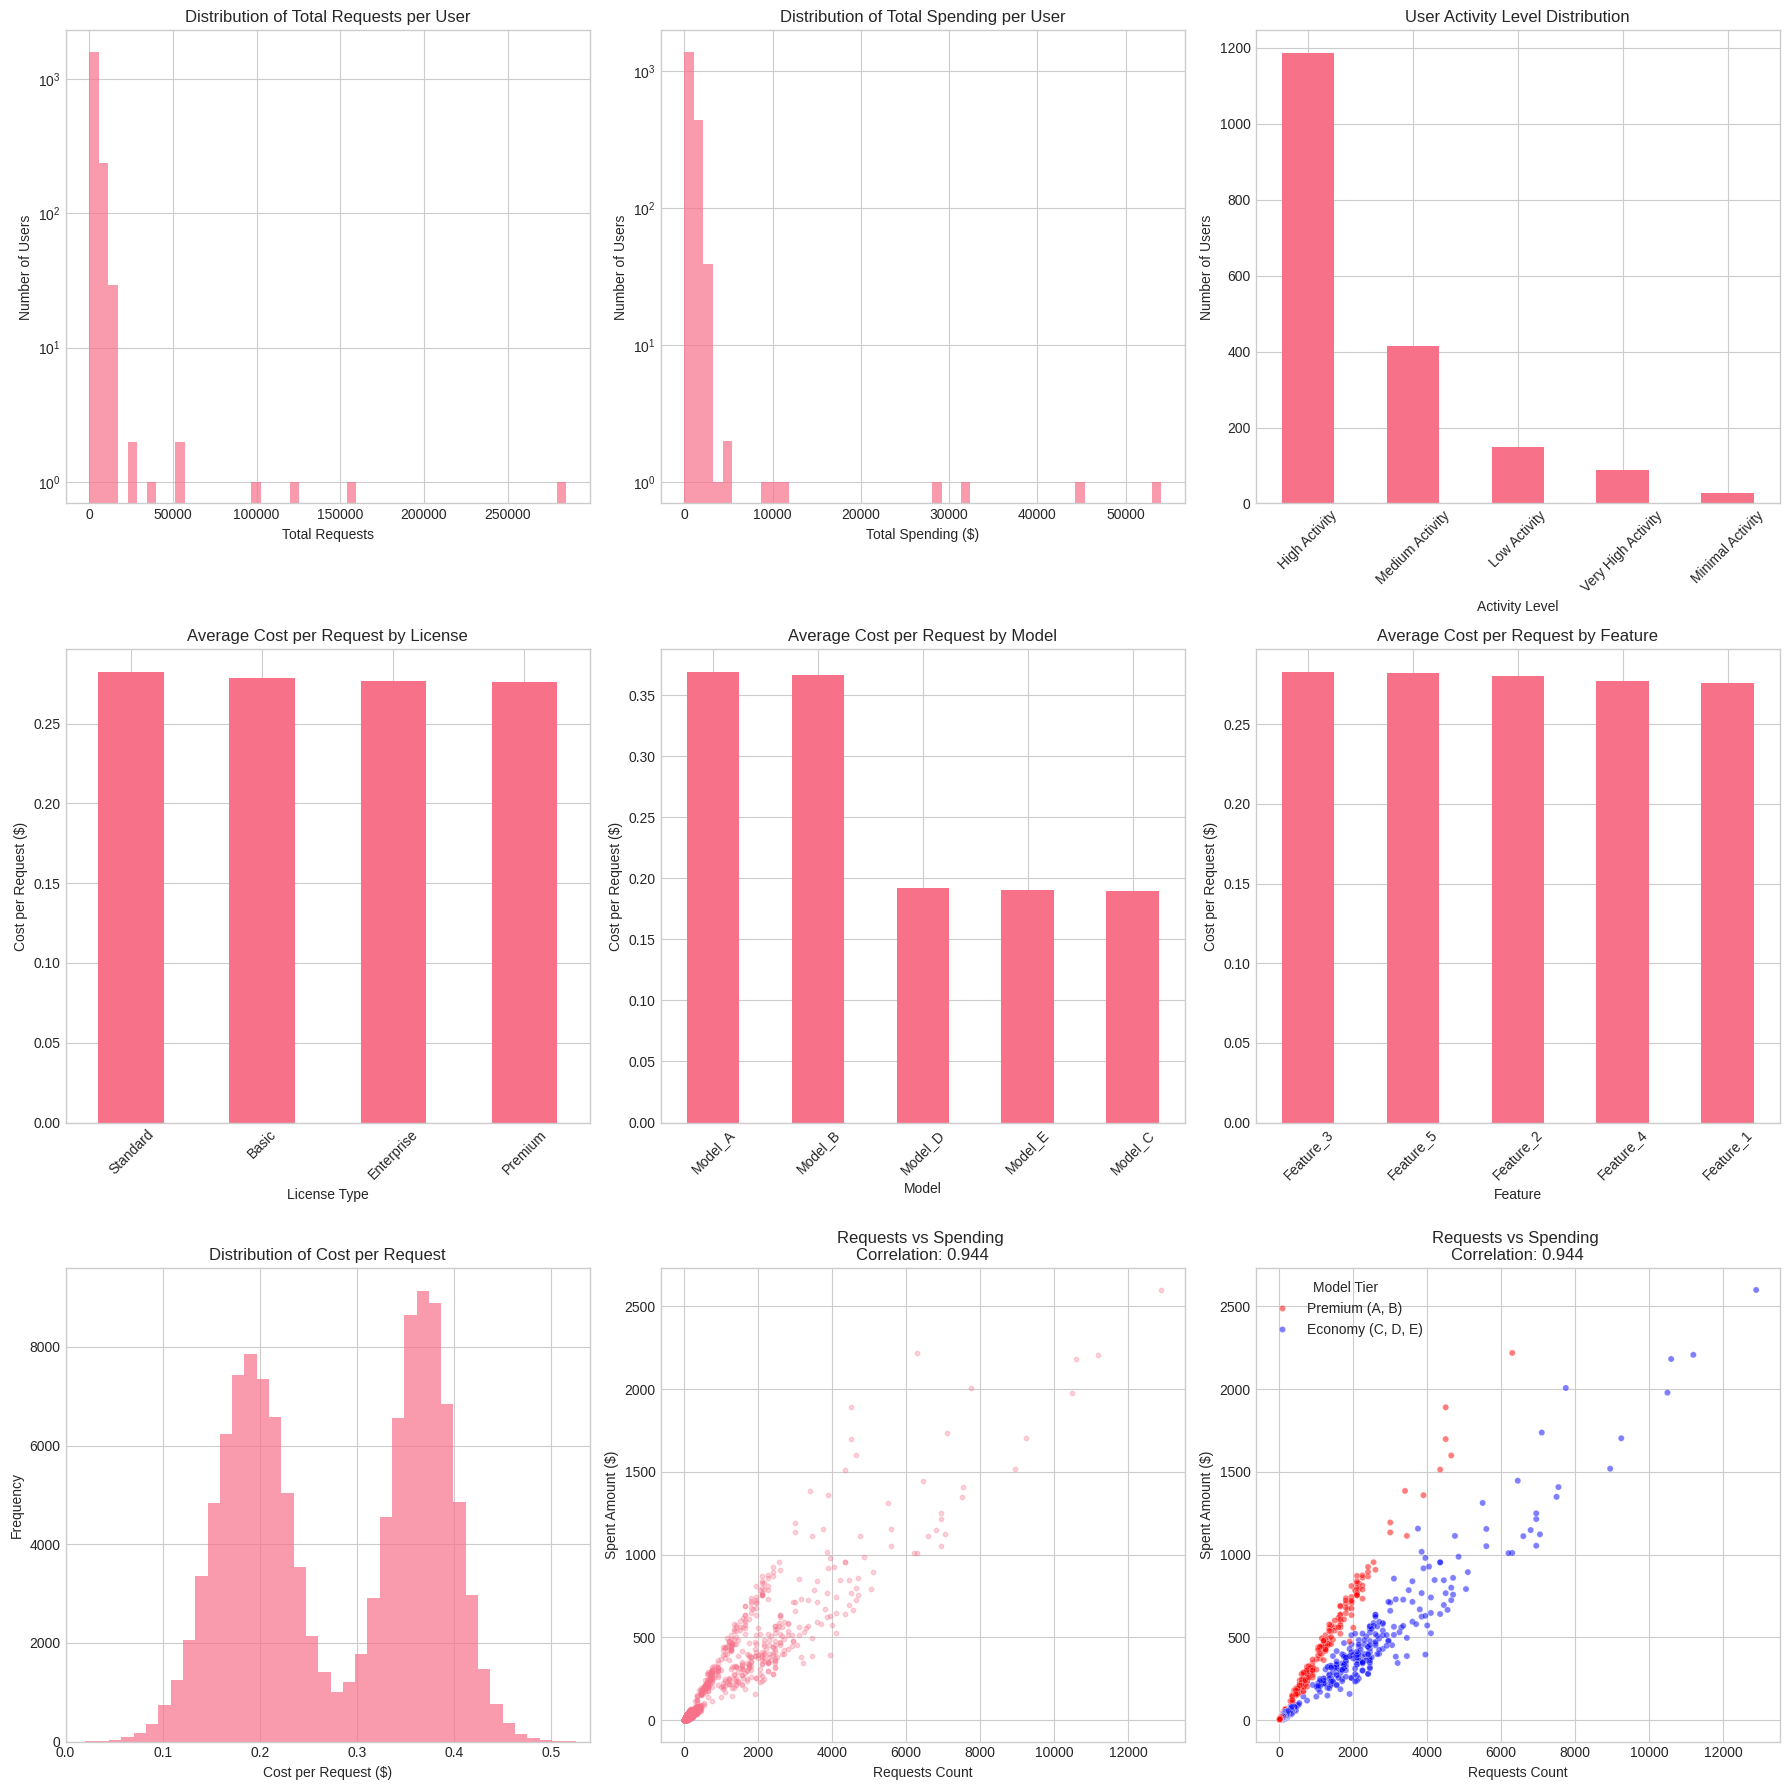

Cost per request 95th percentile: $0.411
Cost per request visualization limited to: $0.540


In [11]:
# Create visualizations for user behavior
# fig, axes = plt.subplots(3, 3, figsize=(18, 18))

fig, axes = plt.subplots(3, 3, figsize=(18, 18))

# User activity distribution
ax1 = axes[0, 0]
user_stats['total_requests'].hist(bins=50, alpha=0.7, ax=ax1)
ax1.set_title('Distribution of Total Requests per User')
ax1.set_xlabel('Total Requests')
ax1.set_ylabel('Number of Users')
ax1.set_yscale('log')
# ax1.set_xscale('log')

# User spending distribution
ax2 = axes[0, 1]
user_stats['total_spent'].hist(bins=50, alpha=0.7, ax=ax2)
ax2.set_title('Distribution of Total Spending per User')
ax2.set_xlabel('Total Spending ($)')
ax2.set_ylabel('Number of Users')
ax2.set_yscale('log')

# Activity level distribution
ax3 = axes[0, 2]
activity_segments.plot(kind='bar', ax=ax3)
ax3.set_title('User Activity Level Distribution')
ax3.set_xlabel('Activity Level')
ax3.set_ylabel('Number of Users')
ax3.tick_params(axis='x', rotation=45)


# Average cost by license type
ax4 = axes[1, 0]
license_cost.plot(kind='bar', ax=ax4)
ax4.set_title('Average Cost per Request by License')
ax4.set_xlabel('License Type')
ax4.set_ylabel('Cost per Request ($)')
ax4.tick_params(axis='x', rotation=45)

# Average cost by model type
ax5 = axes[1, 1]
model_cost.plot(kind='bar', ax=ax5)
ax5.set_title('Average Cost per Request by Model')
ax5.set_xlabel('Model')
ax5.set_ylabel('Cost per Request ($)')
ax5.tick_params(axis='x', rotation=45)

# Average cost by feature type
ax6 = axes[1, 2]
feature_cost.plot(kind='bar', ax=ax6)
ax6.set_title('Average Cost per Request by Feature')
ax6.set_xlabel('Feature')
ax6.set_ylabel('Cost per Request ($)')
ax6.tick_params(axis='x', rotation=45)

# Cost per request distribution
ax7 = axes[2, 0]
# Check 95th percentile to set reasonable limit
cost_95th = df['cost_per_request'].quantile(0.95)
df['cost_per_request'].hist(bins=50, alpha=0.7, ax=ax7)
ax7.set_title('Distribution of Cost per Request')
ax7.set_xlabel('Cost per Request ($)')
ax7.set_ylabel('Frequency')
ax7.set_ylim(0, None)
ax7.set_xlim(0, min(cost_95th * 1.5, df['cost_per_request'].quantile(0.99) + 0.1))
# ax7.set_xlim(0, None)

# Requests vs Spending
ax8 = axes[2, 1]
ax8.scatter(df['requests_cnt'], df['spent_amount'], alpha=0.3, s=10)
ax8.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax8.set_xlabel('Requests Count')
ax8.set_ylabel('Spent Amount ($)')

# Requests vs Spending (Colored by Model Tier
ax9 = axes[2, 2]
economy_models = ['Model_C', 'Model_D', 'Model_E']
df['model_tier'] = df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)
correlation = df['requests_cnt'].corr(df['spent_amount'])
sns.scatterplot(
    data=df,
    x='requests_cnt',
    y='spent_amount',
    hue='model_tier',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=20,
    ax=ax9
)
ax9.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax9.set_xlabel('Requests Count')
ax9.set_ylabel('Spent Amount ($)')
ax9.legend(title='Model Tier')

plt.tight_layout()
plt.show()

print(f"Cost per request 95th percentile: ${cost_95th:.3f}")
print(f"Cost per request visualization limited to: ${min(cost_95th * 1.5, df['cost_per_request'].quantile(0.99) + 0.1):.3f}")

In [12]:
# Custom Binning for User Activity Analysis
custom_bins = segment_distribution if segment_distribution else [0, 20, 100, 1000, 10000, np.inf]
custom_labels = [f'Minimal Activity \n < {custom_bins[1]}',
            f'Low Activity \n {custom_bins[1]}-{custom_bins[2]}',
            f'Medium Activity \n {custom_bins[2]}-{custom_bins[3]}',
            f'High Activity \n {custom_bins[3]}-{custom_bins[4]}',
            f'Very High Activity \n > {custom_bins[4]}']
user_stats['activity_bin_custom'] = pd.cut(user_stats['total_requests'], bins=custom_bins, labels=custom_labels)
spend_by_bin = user_stats.groupby('activity_bin_custom')['total_spent'].sum()
users_per_bin = user_stats.groupby('activity_bin_custom').size()
spend_by_bin_df = pd.DataFrame({
    'Total Spending ($)': spend_by_bin,
    'User Count': users_per_bin
}).reset_index()
print(" - 'spend_by_bin_df' created.")

def get_preference_data(df_in, user_stats_in, category_col, N_BINS_rest=20, CHUNK_SIZE_very_high=20):
    
    # Split users into "Rest" and "Very High Activity"
    rest_users_df = user_stats_in[user_stats_in['activity_level'] != 'Very High Activity'].copy()
    very_high_users_df = user_stats_in[user_stats_in['activity_level'] == 'Very High Activity'].copy()


    # Bin the "Body" (Rest users)
    # (Bins from 0 to N_BINS_rest-1)
    rest_users_df['activity_bin_numeric'] = pd.qcut(
        rest_users_df['total_requests'], 
        q=N_BINS_rest, 
        labels=False, 
        duplicates='drop'
    )
    
    # Bin the "Tail" (Very High Activity users)
    all_bins_series = rest_users_df['activity_bin_numeric'] # Initialize with "Rest" bins
    
    if not very_high_users_df.empty:
        # Sort "Very High" users by total_requests
        very_high_users_df = very_high_users_df.sort_values('total_requests')

        # Isolate top-1
        top_1_user_uuid = very_high_users_df.index[-1]

        # Isolate *all others* in the "tail"
        other_very_high_users = very_high_users_df.iloc[:-1]
        n_others = len(other_very_high_users)

        # Generate bins for "chunks" (starting from N_BINS_rest)
        # e.g., users 0-19 -> bin 20; users 20-39 -> bin 21
        other_bins_array = N_BINS_rest + (np.arange(n_others) // CHUNK_SIZE_very_high)
        other_bins_series = pd.Series(other_bins_array, index=other_very_high_users.index, name='activity_bin_numeric')
        
        # Determine bin for top-1 user
        if n_others > 0:
            last_bin_for_chunks = other_bins_array.max()
            top_1_bin = last_bin_for_chunks + 1
        else:
            top_1_bin = N_BINS_rest
            
        top_1_bin_series = pd.Series([top_1_bin], index=[top_1_user_uuid], name='activity_bin_numeric')

        # Combine all bins ("Body" + "Chunks" + "Top-1")
        all_bins_series = pd.concat([rest_users_df['activity_bin_numeric'], other_bins_series, top_1_bin_series])
        
    
    # Map bins back to the main dataframe
    df_in['activity_bin_numeric'] = df_in['uuid'].map(all_bins_series)
    df_in['activity_bin_numeric'] = df_in['activity_bin_numeric'].fillna(0).astype(int)

    # Calculate average requests per bin
    user_stats_with_bins = user_stats_in.join(all_bins_series)
    bin_request_map = user_stats_with_bins.groupby('activity_bin_numeric')['total_requests'].mean().round(0)

    # Calculate preference data
    grouped_df = df_in.groupby(['activity_bin_numeric', category_col])['requests_cnt'].sum().to_frame()
    bin_totals = grouped_df.groupby(level='activity_bin_numeric')['requests_cnt'].transform('sum')
    grouped_df['percentage'] = (grouped_df['requests_cnt'] / bin_totals).fillna(0)
    normalized_data = grouped_df.reset_index()
    normalized_data['activity_mean_requests'] = normalized_data['activity_bin_numeric'].map(bin_request_map)
    
    return normalized_data


# Run the calculation for 'model' and 'license'
norm_data_model = get_preference_data(df.copy(), user_stats.copy(), 'model')
print(" - 'norm_data_model' created.")
norm_data_feature = get_preference_data(df.copy(), user_stats.copy(), 'feature')
print(" - 'norm_data_feature' created.")
norm_data_license = get_preference_data(df.copy(), user_stats.copy(), 'license')
print(" - 'norm_data_license' created.")

 - 'spend_by_bin_df' created.
 - 'norm_data_model' created.
 - 'norm_data_feature' created.
 - 'norm_data_license' created.


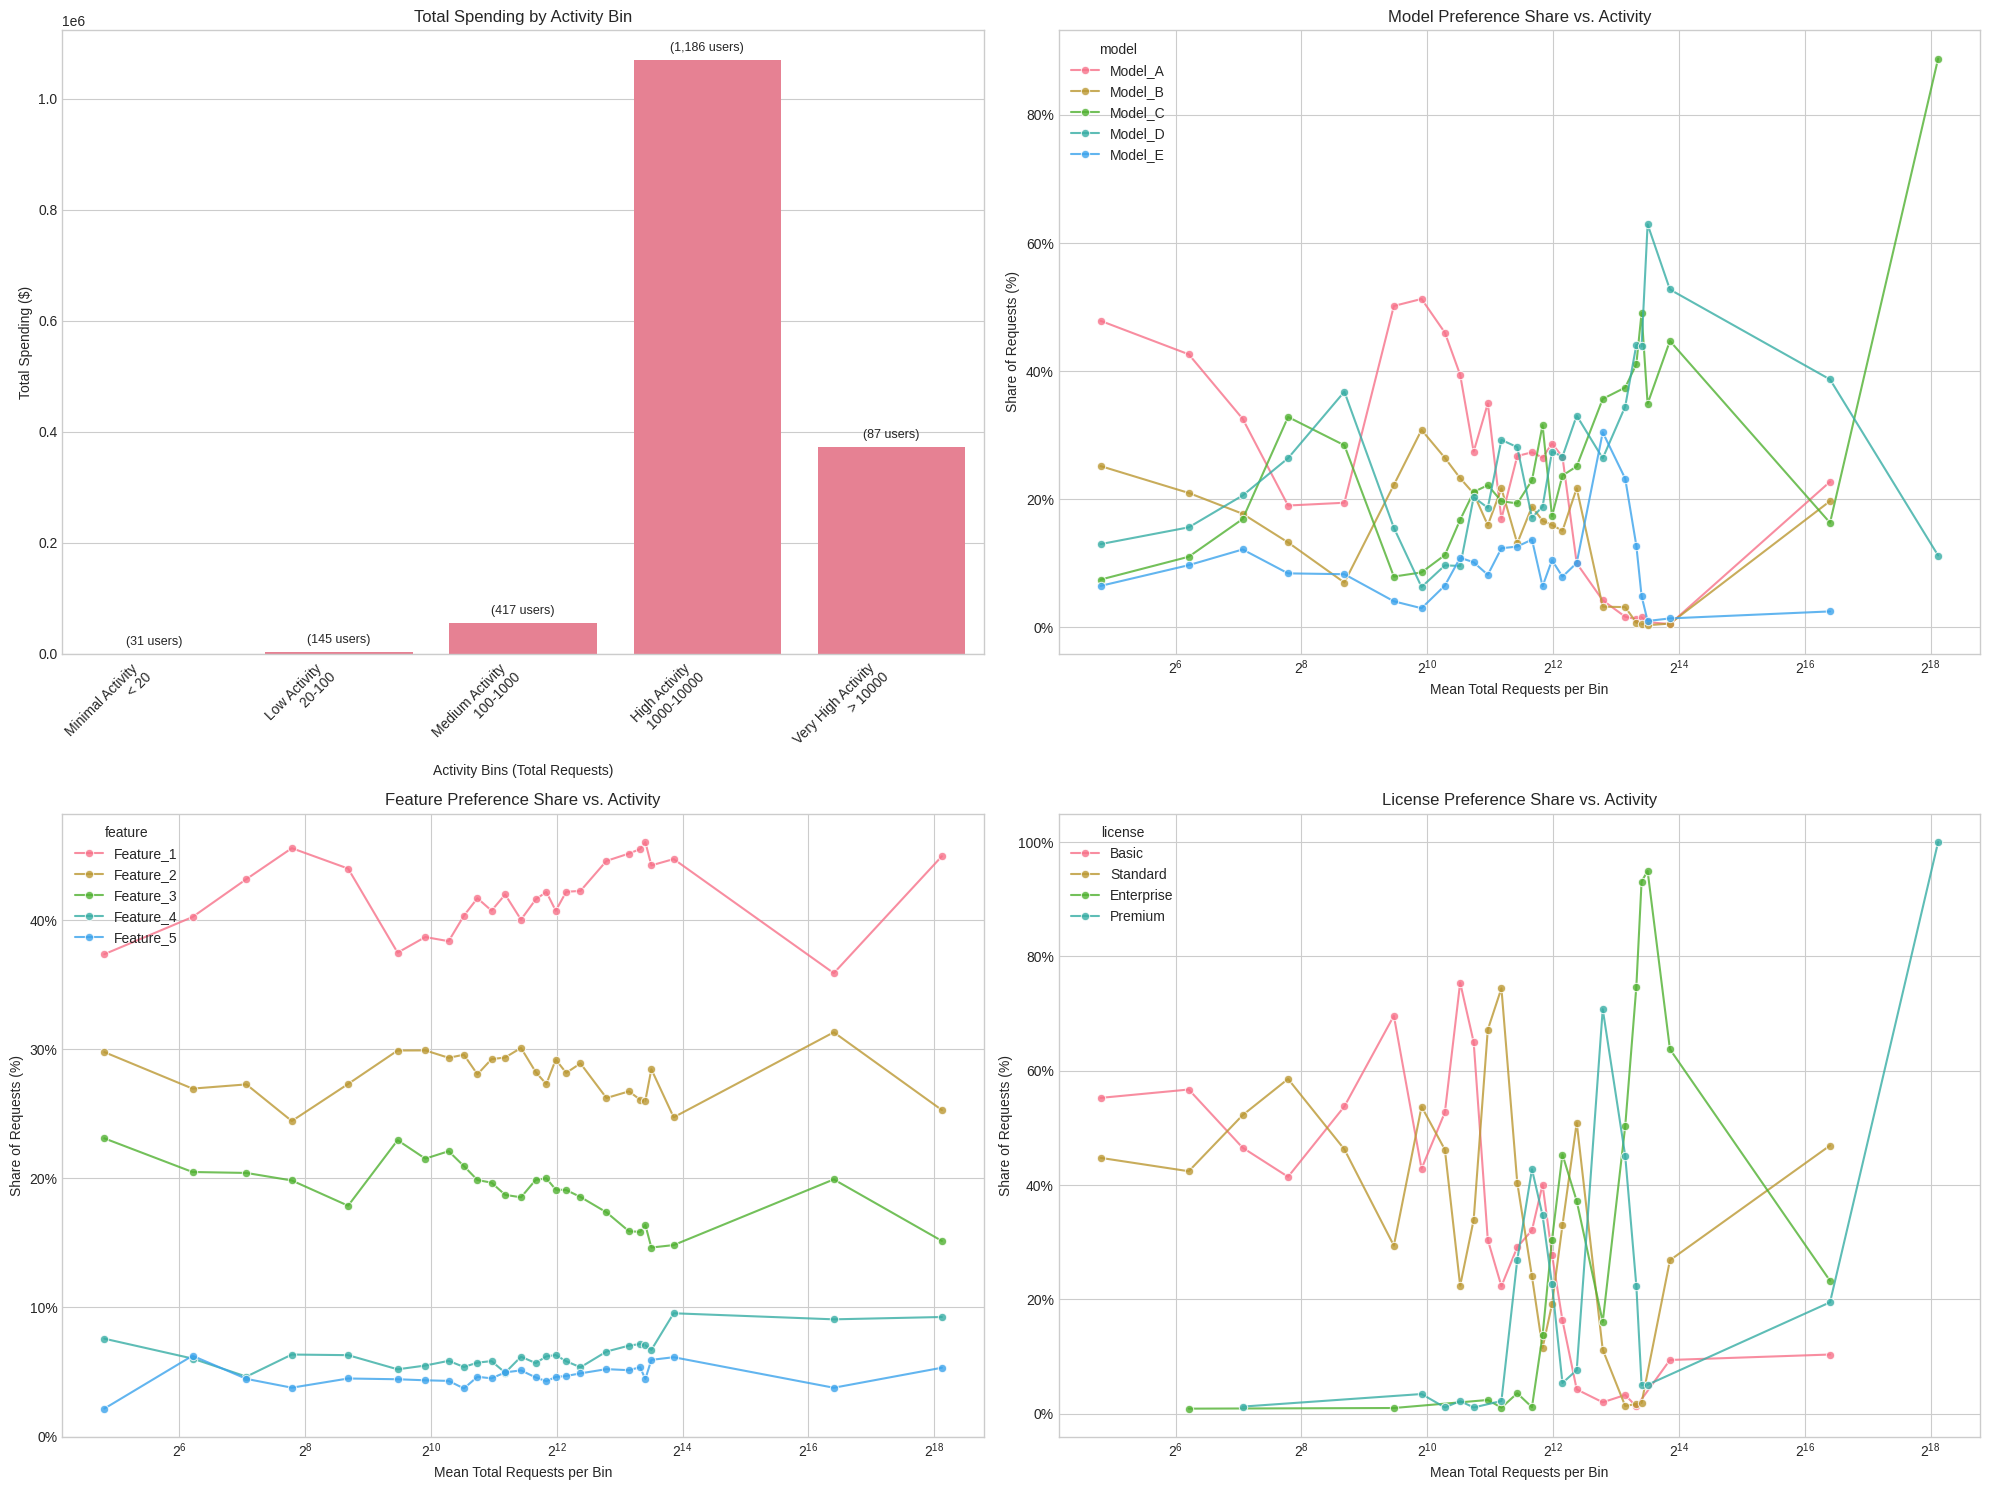

In [13]:
# Create visualizations for activity and preferences
fig, axes = plt.subplots(2, 2, figsize=(20, 15))

# Spending Distribution by Activity (Custom Bins)
ax_00 = axes[0, 0]
sns.barplot(
    data=spend_by_bin_df, 
    x='activity_bin_custom', y='Total Spending ($)',
    ax=ax_00, color=sns.color_palette("husl", 1)[0]
)
ax_00.set_title('Total Spending by Activity Bin')
ax_00.set_xlabel('Activity Bins (Total Requests)')
ax_00.set_ylabel('Total Spending ($)')
ax_00.set_xticklabels(ax_00.get_xticklabels(), rotation=45, ha='right')

for bar, count in zip(ax_00.patches, spend_by_bin_df['User Count']):
    bar_height = bar.get_height() + (spend_by_bin_df['Total Spending ($)'].max() * 0.01)
    label_text = f"({count:,.0f} users)"
    ax_00.text(
        x=bar.get_x() + bar.get_width() / 2,
        y=bar_height,     
        s=label_text,
        ha='center',
        va='bottom',
        fontsize=9
    )

# Model Preference Shift
ax_01 = axes[0, 1]
sns.lineplot(
    data=norm_data_model, 
    x='activity_mean_requests', y='percentage',
    hue='model', marker='o', alpha=0.8, ax=ax_01
)
ax_01.set_title('Model Preference Share vs. Activity')
ax_01.set_xlabel('Mean Total Requests per Bin')
ax_01.set_ylabel('Share of Requests (%)')
ax_01.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_01.set_xscale('log', base=2)

# Feature Preference Shift
ax_10 = axes[1, 0]
sns.lineplot(
    data=norm_data_feature, 
    x='activity_mean_requests', y='percentage',
    hue='feature', marker='o', alpha=0.8, ax=ax_10
)
ax_10.set_title('Feature Preference Share vs. Activity')
ax_10.set_xlabel('Mean Total Requests per Bin')
ax_10.set_ylabel('Share of Requests (%)')
ax_10.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_10.set_xscale('log', base=2)

# License Preference Shift
ax_11 = axes[1, 1]
sns.lineplot(
    data=norm_data_license, 
    x='activity_mean_requests', y='percentage',
    hue='license', marker='o', alpha=0.8, ax=ax_11
)
ax_11.set_title('License Preference Share vs. Activity')
ax_11.set_xlabel('Mean Total Requests per Bin')
ax_11.set_ylabel('Share of Requests (%)')
ax_11.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax_11.set_xscale('log', base=2)

# Final Touches
plt.tight_layout()
plt.show()

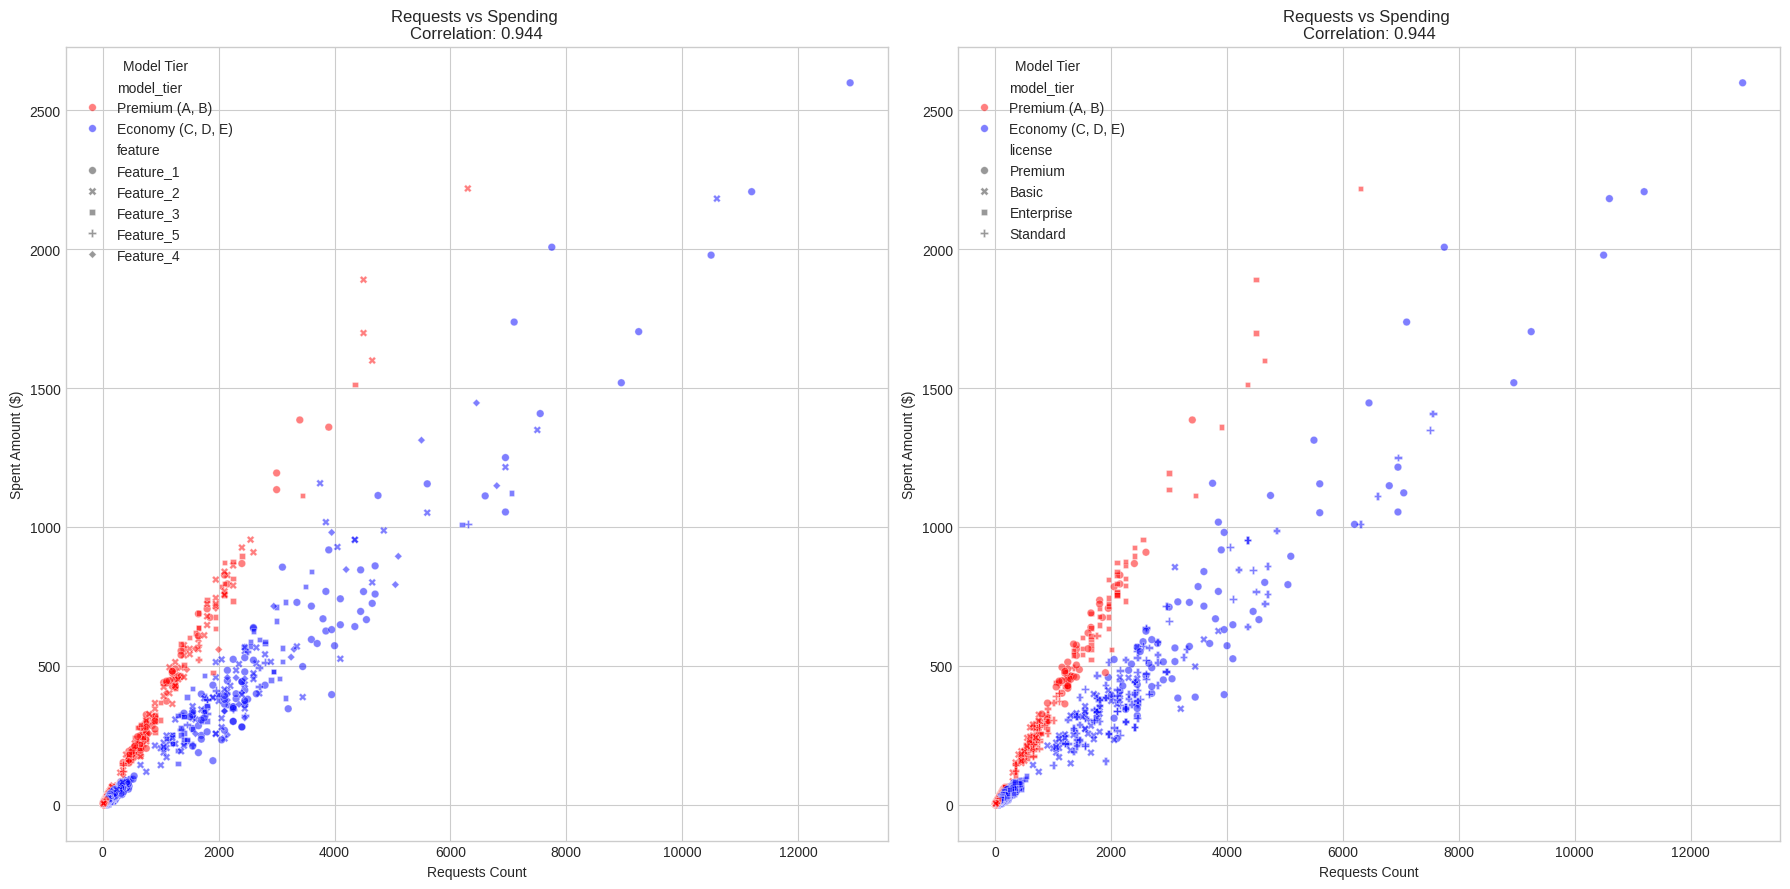

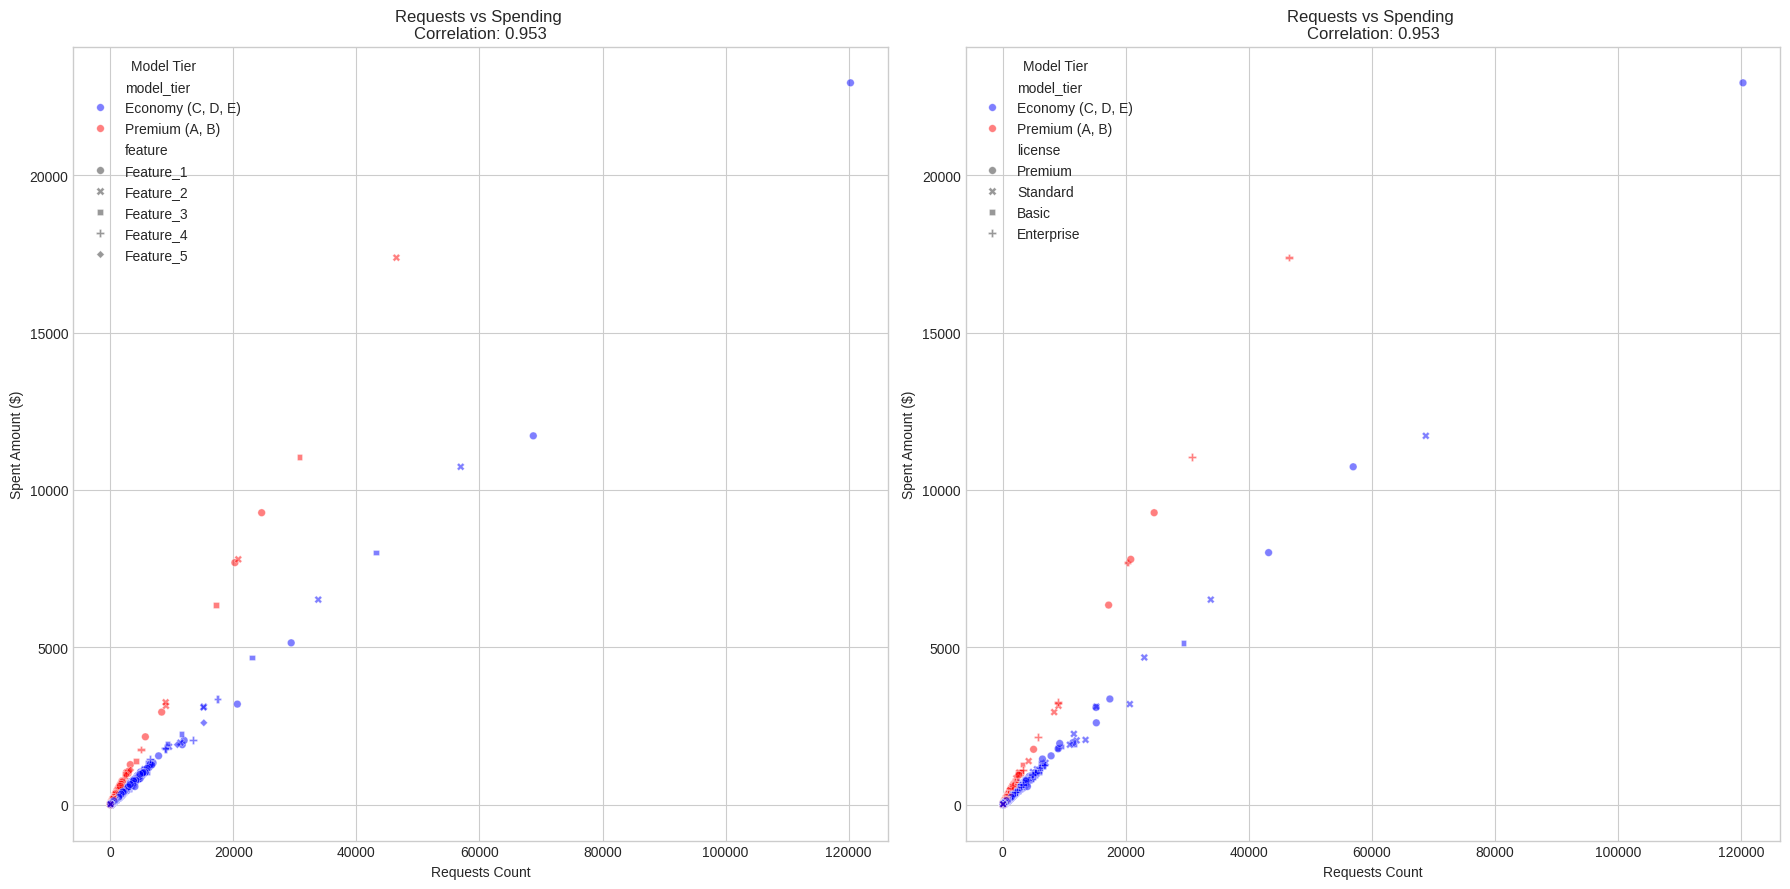

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ax = axes[0]
economy_models = ['Model_C', 'Model_D', 'Model_E']
df['model_tier'] = df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)
correlation = df['requests_cnt'].corr(df['spent_amount'])
sns.scatterplot(
    data=df,
    x='requests_cnt',
    y='spent_amount',
    hue='model_tier',
    style='feature',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=30,
    ax=ax
)
ax.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax.set_xlabel('Requests Count')
ax.set_ylabel('Spent Amount ($)')
ax.legend(title='Model Tier')

ax = axes[1]
economy_models = ['Model_C', 'Model_D', 'Model_E']
df['model_tier'] = df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)
correlation = df['requests_cnt'].corr(df['spent_amount'])
sns.scatterplot(
    data=df,
    x='requests_cnt',
    y='spent_amount',
    hue='model_tier',
    style='license',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=30,
    ax=ax
)
ax.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax.set_xlabel('Requests Count')
ax.set_ylabel('Spent Amount ($)')
ax.legend(title='Model Tier')

plt.tight_layout()
plt.show()



##########

nodate_df = df.groupby(['uuid', 'model', 'license', 'feature']).agg({
    'requests_cnt': ['sum', 'mean', 'count'],
    'spent_amount': ['sum', 'mean']
}).round(2)



nodate_df.columns = ['_'.join(col) for col in nodate_df.columns.values]

nodate_df = nodate_df.reset_index()

nodate_df = nodate_df.rename(columns={
    'requests_cnt_sum': 'total_requests',
    'requests_cnt_mean': 'avg_requests_per_day',
    'requests_cnt_count': 'active_days',
    'spent_amount_sum': 'total_spent',
    'spent_amount_mean': 'avg_spent_per_day'
})

fig, axes = plt.subplots(1, 2, figsize=(18, 9))

ax = axes[0]
economy_models = ['Model_C', 'Model_D', 'Model_E']
nodate_df['model_tier'] = nodate_df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)
correlation = nodate_df['total_requests'].corr(nodate_df['total_spent'])
sns.scatterplot(
    data=nodate_df,
    x='total_requests',
    y='total_spent',
    hue='model_tier',
    style='feature',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=30,
    ax=ax
)
ax.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax.set_xlabel('Requests Count')
ax.set_ylabel('Spent Amount ($)')
ax.legend(title='Model Tier')

ax = axes[1]
economy_models = ['Model_C', 'Model_D', 'Model_E']
nodate_df['model_tier'] = nodate_df['model'].apply(
    lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)'
)
correlation = nodate_df['total_requests'].corr(nodate_df['total_spent'])
sns.scatterplot(
    data=nodate_df,
    x='total_requests',
    y='total_spent',
    hue='model_tier',
    style='license',
    palette={'Economy (C, D, E)': 'blue', 'Premium (A, B)': 'red'},
    alpha=0.5,
    s=30,
    ax=ax
)
ax.set_title(f'Requests vs Spending \nCorrelation: {correlation:.3f}')
ax.set_xlabel('Requests Count')
ax.set_ylabel('Spent Amount ($)')
ax.legend(title='Model Tier')

plt.tight_layout()
plt.show()

ADVANCED 2D BINNING: Preference = f(Activity, Frequency)
Enriched user_stats with 'pct_premium_usage' (our Z-axis).
Created X-axis bins (Total Activity): ['(0-100]', '(100-500]', '(500-1k]', '(1k-10k]', '(10k+]']
Created Y-axis bins (Frequency): ['Freq Q1', 'Freq Q2', 'Freq Q3', 'Freq Q4', 'Freq Q5']
Calculating 2D binned data...


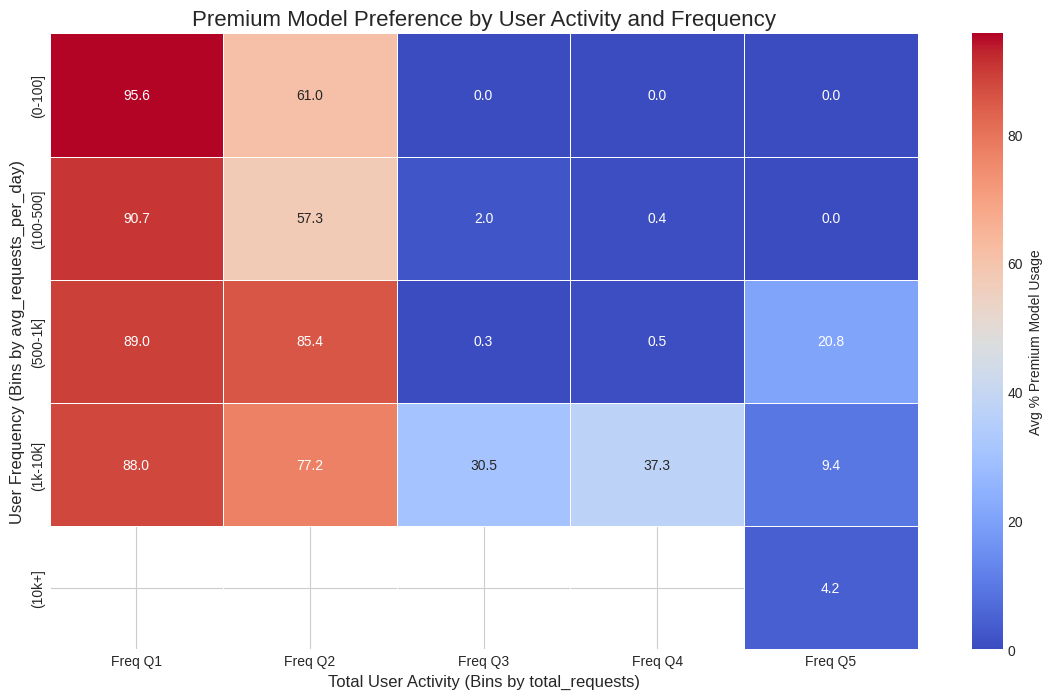


Analysis complete.
The heatmap shows 'hot' (red) zones where users strongly prefer
Premium models, based on BOTH their total activity and frequency.


In [15]:
# --- 7. Advanced 2D Binning Analysis (3D Heatmap) ---

print("ADVANCED 2D BINNING: Preference = f(Activity, Frequency)")
print("=" * 60)

# --- Step 1: Enrich user_stats with the Z-axis (Preference) ---
# We need to calculate '% Premium Model Usage' for each *user*.

# Define Premium models
premium_models = ['Model_A', 'Model_B']
df['is_premium_model'] = df['model'].isin(premium_models)

# Group the main 'df' to find total premium requests for each user
premium_requests_per_user = df[df['is_premium_model']].groupby('uuid')['requests_cnt'].sum()

# Map this back to user_stats (which has total_requests)
user_stats['premium_requests'] = user_stats.index.map(premium_requests_per_user).fillna(0)

# Calculate our Z-axis metric: % of a user's requests that are 'Premium'
user_stats['pct_premium_usage'] = (
    (user_stats['premium_requests'] / user_stats['total_requests']) * 100
).fillna(0).round(1)

print("Enriched user_stats with 'pct_premium_usage' (our Z-axis).")

# --- Step 2: Bin the X-axis (Total Activity) ---
# We use the 'custom_bins' (pd.cut) that you liked.
x_bins = [0, 100, 500, 1000, 10000, np.inf]
x_labels = ['(0-100]', '(100-500]', '(500-1k]', '(1k-10k]', '(10k+]']
user_stats['x_bin_activity'] = pd.cut(user_stats['total_requests'], bins=x_bins, labels=x_labels)

print(f"Created X-axis bins (Total Activity): {x_labels}")

# --- Step 3: Bin the Y-axis (Frequency) ---
# We use 'pd.qcut' (quantiles) for frequency, as it's robust against skew.
# We'll make 5 bins (quintiles).
y_bins = 5
y_labels = [f'Freq Q{i+1}' for i in range(y_bins)] # Q1=Lowest Freq, Q5=Highest Freq
user_stats['y_bin_frequency'] = pd.qcut(
    user_stats['avg_requests_per_day'], 
    q=y_bins, 
    labels=y_labels, 
    duplicates='drop' # Handles cases where quintiles overlap
)

print(f"Created Y-axis bins (Frequency): {y_labels}")

# --- Step 4: Group & Pivot (The 2D Binning) ---
# This is the core of your idea.
# We group by our X and Y bins, and get the *mean* of our Z-metric.
print("Calculating 2D binned data...")
binned_2d_data = user_stats.groupby(
    ['x_bin_activity', 'y_bin_frequency']
)['pct_premium_usage'].mean()

# Unstack the data to create the 2D grid for the heatmap
heatmap_data = binned_2d_data.unstack(level='y_bin_frequency')

# --- Step 5: Plot the 3D Heatmap ---
plt.figure(figsize=(14, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,     # Show the % value in each cell
    fmt=".1f",      # Format to one decimal place (e.g., "80.1")
    cmap="coolwarm",# Use Blue (cold, low %) to Red (hot, high %)
    linewidths=.5,  # Add thin lines between cells
    cbar_kws={'label': 'Avg % Premium Model Usage'} # Label for the color bar
)
plt.title('Premium Model Preference by User Activity and Frequency', fontsize=16)
plt.xlabel('Total User Activity (Bins by total_requests)', fontsize=12)
plt.ylabel('User Frequency (Bins by avg_requests_per_day)', fontsize=12)
plt.show()

print("\nAnalysis complete.")
print("The heatmap shows 'hot' (red) zones where users strongly prefer")
print("Premium models, based on BOTH their total activity and frequency.")

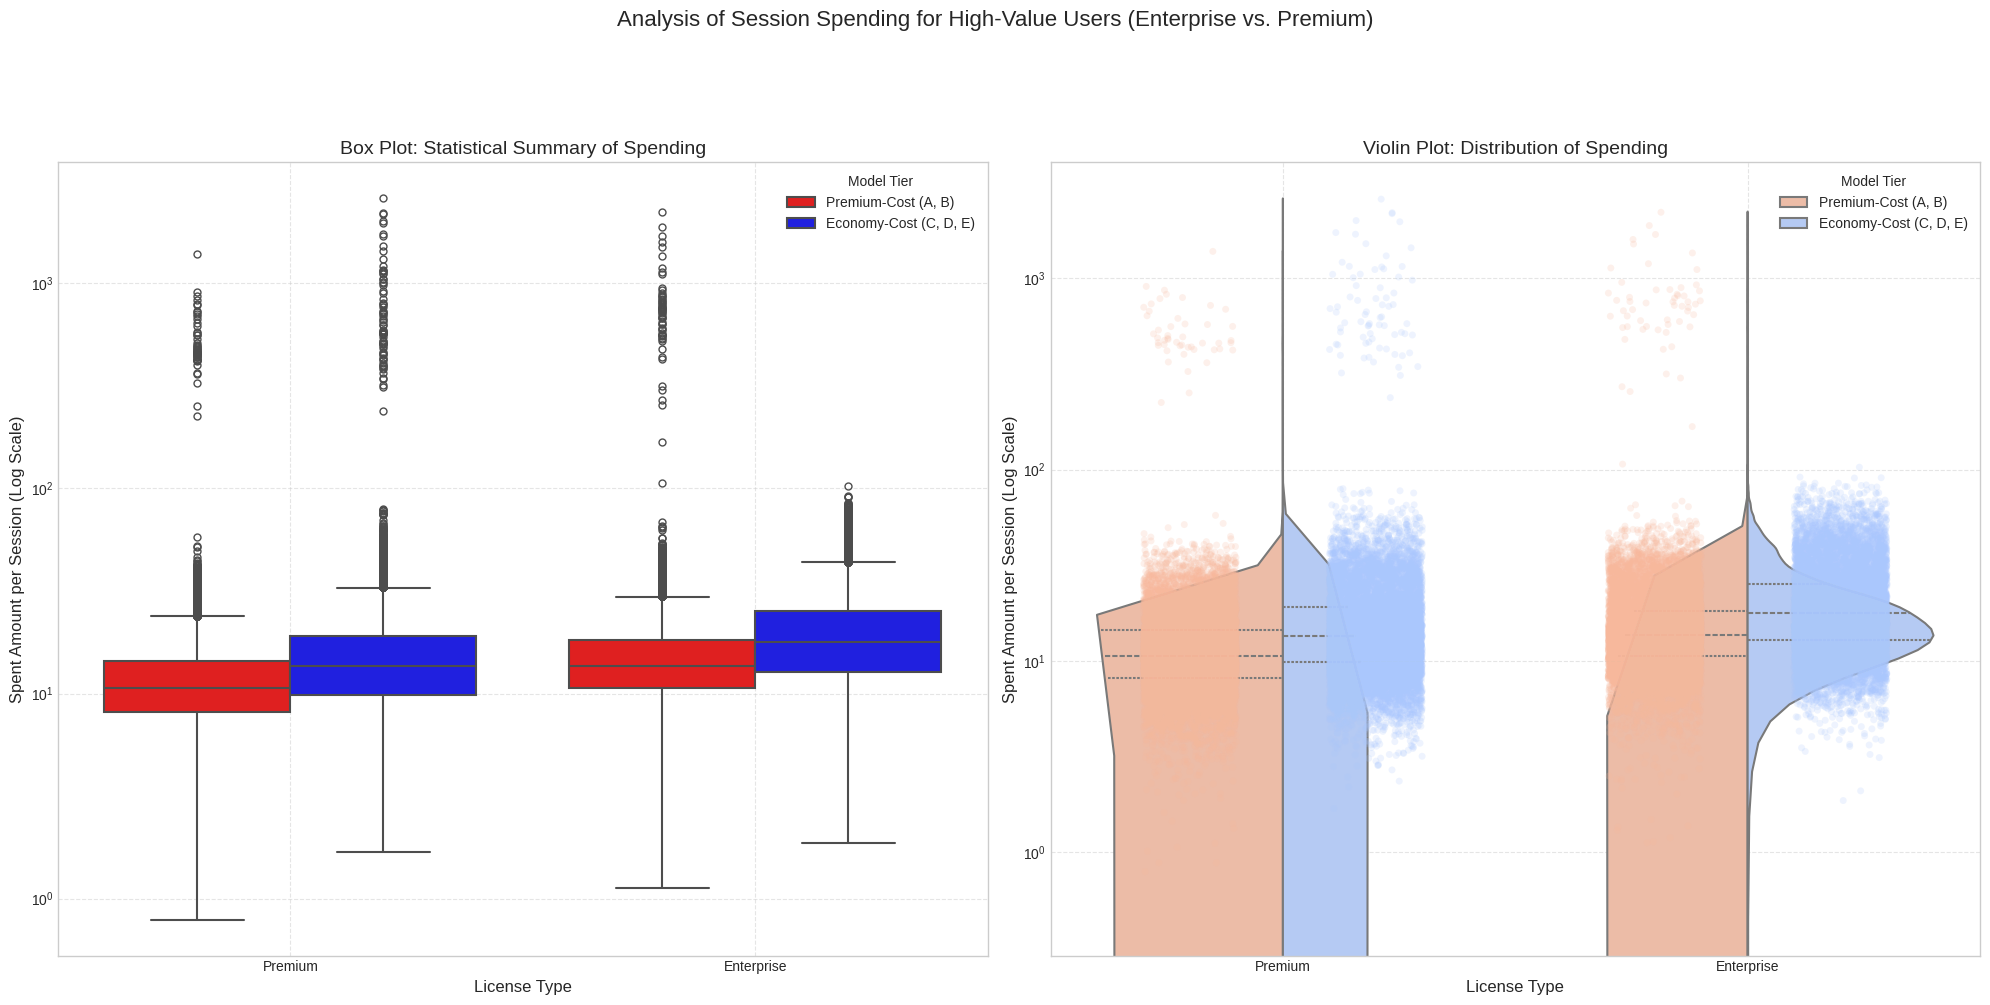

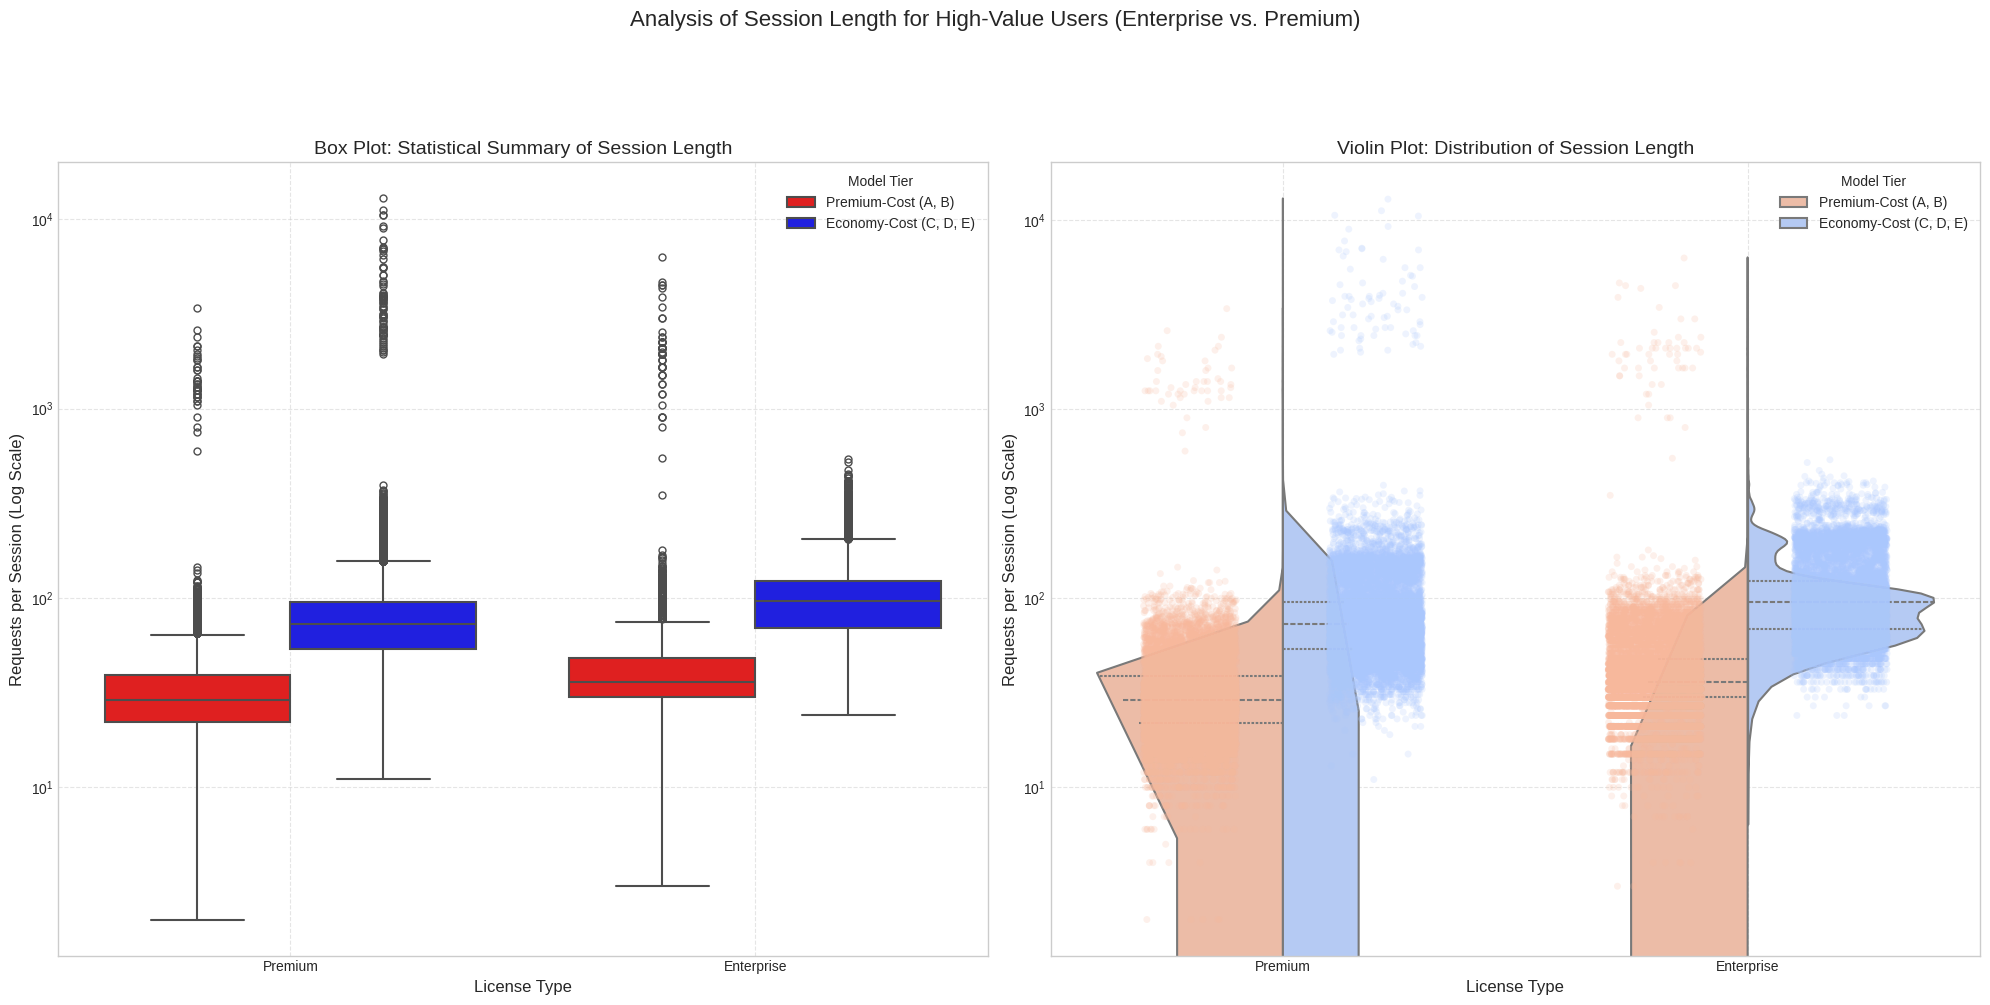

In [16]:
# Analysis of Session Spending

user_activity_analysis_df = df.merge(
    user_stats[['activity_level']], 
    left_on='uuid', 
    right_index=True,
    how='left'
)

premium_models_list = ['Model_A', 'Model_B']
user_activity_analysis_df['model_tier'] = user_activity_analysis_df['model'].apply(
    lambda x: 'Premium-Cost (A, B)' if x in premium_models_list else 'Economy-Cost (C, D, E)'
)

high_activity_df = user_activity_analysis_df[
    user_activity_analysis_df['activity_level'].isin(['High Activity', 'Very High Activity'])
]
target_licenses_df = high_activity_df[
    high_activity_df['license'].isin(['Enterprise', 'Premium'])
]


fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Analysis of Session Spending for High-Value Users (Enterprise vs. Premium)', fontsize=16, y=1.03)

# Plot 1: Box Plot (spent_amount) 
ax1 = axes[0]
sns.boxplot(
    data=target_licenses_df,
    x='license',
    y='spent_amount',
    hue='model_tier',
    palette={'Premium-Cost (A, B)': '#FF0000', 'Economy-Cost (C, D, E)': '#0000FF'},
    linewidth=1.5,
    fliersize=5,
    ax=ax1
)
ax1.set_title("Box Plot: Statistical Summary of Spending", fontsize=14)
ax1.set_xlabel("License Type", fontsize=12)
ax1.set_ylabel("Spent Amount per Session (Log Scale)", fontsize=12)
ax1.set_yscale('log')
ax1.legend(title='Model Tier')
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

# Plot 2: Violin Plot (spent_amount)
ax2 = axes[1]
sns.violinplot(
    data=target_licenses_df,
    x='license',
    y='spent_amount',
    hue='model_tier',
    split=True,
    inner='quartile',
    palette='coolwarm_r', 
    linewidth=1.5,
    ax=ax2
)
sns.stripplot(
    data=target_licenses_df,
    x='license',
    y='spent_amount',
    hue='model_tier',
    dodge=True,
    alpha=0.2,
    jitter=0.2,
    palette='coolwarm_r',
    legend=False,
    ax=ax2
)
ax2.set_title("Violin Plot: Distribution of Spending", fontsize=14)
ax2.set_xlabel("License Type", fontsize=12)
ax2.set_ylabel("Spent Amount per Session (Log Scale)", fontsize=12)
ax2.set_yscale('log')
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[0:2], labels[0:2], title='Model Tier')
ax2.grid(True, which='major', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()




fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle('Analysis of Session Length for High-Value Users (Enterprise vs. Premium)', fontsize=16, y=1.03)

# Plot 1: Box Plot (requests_cnt)
ax1 = axes[0]
sns.boxplot(
    data=target_licenses_df,
    x='license',
    y='requests_cnt', 
    hue='model_tier',
    palette={'Premium-Cost (A, B)': '#FF0000', 'Economy-Cost (C, D, E)': '#0000FF'},
    linewidth=1.5,
    fliersize=5, 
    ax=ax1
)
ax1.set_title("Box Plot: Statistical Summary of Session Length", fontsize=14)
ax1.set_xlabel("License Type", fontsize=12)
ax1.set_ylabel("Requests per Session (Log Scale)", fontsize=12)
ax1.set_yscale('log')
ax1.legend(title='Model Tier')
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

# Plot 2: Violin Plot (requests_cnt)
ax2 = axes[1]
sns.violinplot(
    data=target_licenses_df,
    x='license',
    y='requests_cnt', 
    hue='model_tier',
    split=True,
    inner='quartile',
    palette='coolwarm_r', 
    linewidth=1.5,
    ax=ax2
)
sns.stripplot(
    data=target_licenses_df,
    x='license',
    y='requests_cnt', 
    hue='model_tier',
    dodge=True,
    alpha=0.2,
    jitter=0.2,
    palette='coolwarm_r',
    legend=False,
    ax=ax2
)
ax2.set_title("Violin Plot: Distribution of Session Length", fontsize=14)
ax2.set_xlabel("License Type", fontsize=12)
ax2.set_ylabel("Requests per Session (Log Scale)", fontsize=12)
ax2.set_yscale('log')
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles[0:2], labels[0:2], title='Model Tier')
ax2.grid(True, which='major', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Interactive Dashbords

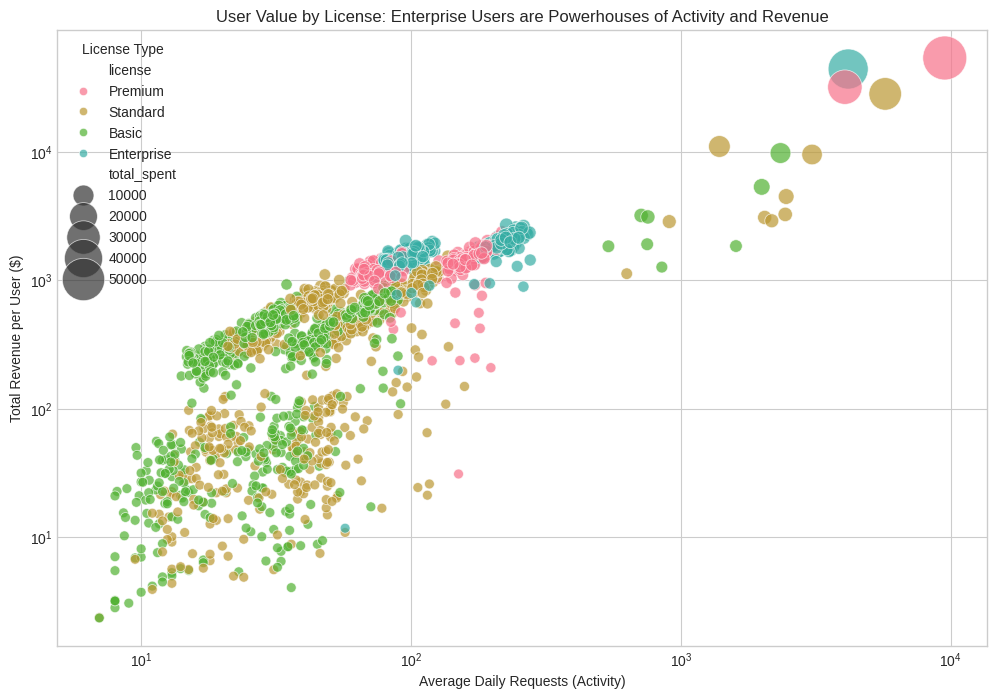

In [17]:
premium_enterprise_uuids = df[df['license'].isin(['Premium', 'Enterprise'])]['uuid'].unique()
filtered_df = df[df['uuid'].isin(premium_enterprise_uuids)]
filtered_df = df

user_level_stats = filtered_df.groupby(['uuid', 'license']).agg(
    total_requests=('requests_cnt', 'sum'),
    total_spent=('spent_amount', 'sum'),
    active_days=('day_id', 'nunique')
).reset_index()

user_level_stats['avg_daily_requests'] = user_level_stats['total_requests'] / user_level_stats['active_days']
user_level_stats['avg_revenue_per_user'] = user_level_stats['total_spent']
user_level_stats['abs_total_spent'] = user_level_stats.groupby('uuid')['total_spent'].transform('sum')

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=user_level_stats,
    x='avg_daily_requests',
    y='total_spent', 
    hue='license',
    size='total_spent',
    sizes=(50, 1000),
    alpha=0.7
)

plt.title('User Value by License: Enterprise Users are Powerhouses of Activity and Revenue')
plt.xlabel('Average Daily Requests (Activity)')
plt.ylabel('Total Revenue per User ($)')
plt.xscale('log') # Use log scale if data is skewed
plt.yscale('log')
plt.legend(title='License Type')
plt.grid(True)
plt.show()

In [18]:
import pandas as pd
import numpy as np
import altair as alt
import ipywidgets as widgets
from ipywidgets import interact, Layout

global_user_stats = df.groupby(['uuid', 'license']).agg(
    total_requests=('requests_cnt', 'sum'),
    total_spent=('spent_amount', 'sum'),
    active_days=('day_id', 'nunique')
).reset_index()

global_user_stats = global_user_stats[global_user_stats['active_days'] > 0]
global_user_stats['avg_daily_requests'] = global_user_stats['total_requests'] / global_user_stats['active_days']

global_x_domain = (
    global_user_stats['avg_daily_requests'].min()*0.9,
    global_user_stats['avg_daily_requests'].max()*1.2
)
positive_spent = global_user_stats[global_user_stats['total_spent'] > 0]
global_y_domain = (
    positive_spent['total_spent'].min()*0.9 if not positive_spent.empty else 0.1,
    global_user_stats['total_spent'].max()*1.4
)

total_overall_revenue = df['spent_amount'].sum()


def create_final_plot_pro_style_final(licenses_to_filter, mode):
    if not licenses_to_filter:
        uuids_to_highlight = global_user_stats['uuid'].unique()
        title_suffix = "All Users"
    else:
        target_uuids = global_user_stats[global_user_stats['license'].isin(licenses_to_filter)]['uuid'].unique()
        if mode == 'Include':
            uuids_to_highlight = target_uuids
            title_suffix = f"Users who have had: {', '.join(licenses_to_filter)}"
        else:
            all_uuids = set(global_user_stats['uuid'].unique())
            target_uuids_set = set(target_uuids)
            uuids_to_highlight = list(all_uuids - target_uuids_set)
            title_suffix = f"Users who NEVER had: {', '.join(licenses_to_filter)}"

    source_data = global_user_stats.copy()
    source_data['group'] = np.where(
        source_data['uuid'].isin(uuids_to_highlight),
        source_data['license'],
        'Others'
    )
    
    scatter_plot = alt.Chart(source_data).mark_circle(
        stroke='white'
    ).encode(
        x=alt.X('avg_daily_requests:Q', scale=alt.Scale(type="log", domain=global_x_domain, zero=False), title='Average Daily Requests (Activity)'),
        y=alt.Y('total_spent:Q', scale=alt.Scale(type="log", domain=global_y_domain, zero=False), title='Total Spent ($)'),
        color=alt.Color('license:N', legend=alt.Legend(title="License Type")),
        size=alt.Size('total_spent:Q',
                      scale=alt.Scale(domain=global_y_domain, range=[50, 1000]),
                      legend=None),
        opacity=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0.08)),
        strokeWidth=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0)),
        order=alt.Order('z_order:Q'),
        tooltip=[
            'uuid:N', 'license:N',
            alt.Tooltip('total_spent:Q', format='$,.2f'),
            alt.Tooltip('avg_daily_requests:Q', format='.1f'),
            'active_days:Q'
        ]
    ).transform_calculate(
        z_order="datum.group != 'Others' ? 1 : 0"
    ).properties(
        title=f'User Value Analysis: {title_suffix}',
        width=650,
        height=500
    ).interactive()


    filtered_revenue = source_data[source_data['group'] != 'Others']['total_spent'].sum()
    percent_of_total_revenue = (filtered_revenue / total_overall_revenue) * 100 if total_overall_revenue > 0 else 0
    bar_chart = alt.Chart(source_data).mark_bar(width=50).encode(
        y=alt.Y('sum(total_spent):Q', scale=alt.Scale(domain=[0, total_overall_revenue]), axis=alt.Axis(title='Total Revenue ($)', format='~s')),
        x=alt.X('category:N', axis=None, title=''),
        color=alt.condition(alt.datum.group == 'Others', alt.value('lightgray'), alt.Color('group:N', legend=None)),
        order=alt.Order('sort_order:Q', sort='ascending'),
        tooltip=[
            alt.Tooltip('group:N', title='License Group'),
            alt.Tooltip('sum(total_spent):Q', title='Revenue', format='$,.0f'),
            alt.Tooltip('sum(total_requests):Q', title='Total Requests', format=',.0f'),
            alt.Tooltip('count(uuid):Q', title='Unique Users')
        ]
    ).transform_calculate(
        category='" "',
        sort_order="datum.group == 'Others' ? 1 : 0"
    ).properties(
        title=f"Contribution ({percent_of_total_revenue:.1f}% of Total)",
        width=50,
        height=450
    )

    table_data = source_data[source_data['group'] != 'Others'].groupby('group').agg(
        total_spent=('total_spent', 'sum'),
        total_requests=('total_requests', 'sum'),
        unique_users=('uuid', 'nunique')
    ).reset_index()

    if not table_data.empty and filtered_revenue > 0:
        table_data['percentage'] = (table_data['total_spent'] / filtered_revenue)
    else:
        table_data['percentage'] = 0

    base_table = alt.Chart(table_data).properties(width=150, title="Share of Filtered")

    common_tooltip = [
        alt.Tooltip('group:N', title='License Group'),
        alt.Tooltip('total_spent:Q', title='Revenue', format='$,.0f'),
        alt.Tooltip('total_requests:Q', title='Total Requests', format=',.0f'),
        alt.Tooltip('unique_users:Q', title='Unique Users')
    ]

    table_names = base_table.mark_text(align='left', dx=-80).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text='group:N',
        tooltip=common_tooltip
    )
    table_percents = base_table.mark_text(align='left', dx=10).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text=alt.Text('percentage:Q', format='.1%'),
        tooltip=common_tooltip
    )
    summary_table = (table_names + table_percents)



    dashboard = (scatter_plot | bar_chart | summary_table).properties(
        title=alt.TitleParams(text='User Value Interactive Dashboard', anchor='middle', fontSize=18)
    ).configure_view(
        stroke=None 
    )

    return dashboard





all_licenses = sorted(df['license'].unique().tolist())

interact(
    create_final_plot_pro_style_final,
    licenses_to_filter=widgets.SelectMultiple(
        options=all_licenses,
        value=['Premium', 'Enterprise'],
        description='Filter by Licenses:',
        style={'description_width': 'initial'},
        layout=Layout(width='50%')
    ),
    mode=widgets.RadioButtons(
        options=['Include', 'Exclude'],
        value='Include',
        description='Filter Mode:',
        style={'description_width': 'initial'}
    )
);

interactive(children=(SelectMultiple(description='Filter by Licenses:', index=(2, 1), layout=Layout(width='50%…

In [19]:
import pandas as pd
import numpy as np
import altair as alt
import ipywidgets as widgets
from ipywidgets import interact, Layout

global_user_stats_model = df.groupby(['uuid', 'model']).agg(
    total_requests=('requests_cnt', 'sum'),
    total_spent=('spent_amount', 'sum'),
    active_days=('day_id', 'nunique')
).reset_index()

global_user_stats_model = global_user_stats_model[global_user_stats_model['active_days'] > 0]
global_user_stats_model['avg_daily_requests'] = global_user_stats_model['total_requests'] / global_user_stats_model['active_days']

global_x_domain_model = (
    global_user_stats_model['avg_daily_requests'].min() * 0.9,
    global_user_stats_model['avg_daily_requests'].max() * 1.2
)
positive_spent_model = global_user_stats_model[global_user_stats_model['total_spent'] > 0]
global_y_domain_model = (
    positive_spent_model['total_spent'].min() * 0.9 if not positive_spent_model.empty else 0.1,
    global_user_stats_model['total_spent'].max() * 1.4
)

total_overall_revenue = df['spent_amount'].sum()

def create_model_report(models_to_filter, mode):
    if not models_to_filter:
        uuids_to_highlight = global_user_stats_model['uuid'].unique()
        title_suffix = "All Users"
    else:
        target_uuids = global_user_stats_model[global_user_stats_model['model'].isin(models_to_filter)]['uuid'].unique()
        if mode == 'Include':
            uuids_to_highlight = target_uuids
            title_suffix = f"Users who have used: {', '.join(models_to_filter)}"
        else:
            all_uuids = set(global_user_stats_model['uuid'].unique())
            target_uuids_set = set(target_uuids)
            uuids_to_highlight = list(all_uuids - target_uuids_set)
            title_suffix = f"Users who NEVER used: {', '.join(models_to_filter)}"

    source_data = global_user_stats_model.copy()
    source_data['group'] = np.where(
        source_data['uuid'].isin(uuids_to_highlight),
        source_data['model'],
        'Others'
    )
    
    scatter_plot = alt.Chart(source_data).mark_circle(
        stroke='white'
    ).encode(
        x=alt.X('avg_daily_requests:Q', scale=alt.Scale(type="log", domain=global_x_domain_model, zero=False), title='Average Daily Requests (Activity)'),
        y=alt.Y('total_spent:Q', scale=alt.Scale(type="log", domain=global_y_domain_model, zero=False), title='Total Spent ($)'),
        color=alt.Color('model:N', legend=alt.Legend(title="Model Type")),
        size=alt.Size('total_spent:Q',
                      scale=alt.Scale(domain=global_y_domain_model, range=[50, 1000]),
                      legend=None),
        opacity=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0.08)),
        strokeWidth=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0)),
        order=alt.Order('z_order:Q'),
        tooltip=[
            'uuid:N', 'model:N',
            alt.Tooltip('total_spent:Q', format='$,.2f'),
            alt.Tooltip('avg_daily_requests:Q', format='.1f'),
            'active_days:Q'
        ]
    ).transform_calculate(
        z_order="datum.group != 'Others' ? 1 : 0"
    ).properties(
        title=f'User Value Analysis by Model: {title_suffix}',
        width=650,
        height=500
    ).interactive()

    filtered_revenue = source_data[source_data['group'] != 'Others']['total_spent'].sum()
    percent_of_total_revenue = (filtered_revenue / total_overall_revenue) * 100 if total_overall_revenue > 0 else 0
    bar_chart = alt.Chart(source_data).mark_bar(width=50).encode(
        y=alt.Y('sum(total_spent):Q', scale=alt.Scale(domain=[0, total_overall_revenue]), axis=alt.Axis(title='Total Revenue ($)', format='~s')),
        x=alt.X('category:N', axis=None, title=''),
        color=alt.condition(alt.datum.group == 'Others', alt.value('lightgray'), alt.Color('group:N', legend=None)),
        order=alt.Order('sort_order:Q', sort='ascending'),
        tooltip=[
            alt.Tooltip('group:N', title='Model Group'),
            alt.Tooltip('sum(total_spent):Q', title='Revenue', format='$,.0f'),
            alt.Tooltip('sum(total_requests):Q', title='Total Requests', format=',.0f'),
            alt.Tooltip('count(uuid):Q', title='Unique Users')
        ]
    ).transform_calculate(
        category='" "',
        sort_order="datum.group == 'Others' ? 1 : 0"
    ).properties(
        title=f"Contribution ({percent_of_total_revenue:.1f}% of Total)",
        width=50
    )

    table_data = source_data[source_data['group'] != 'Others'].groupby('group').agg(
        total_spent=('total_spent', 'sum'),
        total_requests=('total_requests', 'sum'),
        unique_users=('uuid', 'nunique')
    ).reset_index()

    if not table_data.empty and filtered_revenue > 0:
        table_data['percentage'] = (table_data['total_spent'] / filtered_revenue)
    else:
        table_data['percentage'] = 0

    base_table = alt.Chart(table_data).properties(width=150, title="Share of Filtered")

    common_tooltip = [
        alt.Tooltip('group:N', title='Model Group'),
        alt.Tooltip('total_spent:Q', title='Revenue', format='$,.0f'),
        alt.Tooltip('total_requests:Q', title='Total Requests', format=',.0f'),
        alt.Tooltip('unique_users:Q', title='Unique Users')
    ]

    table_names = base_table.mark_text(align='left', dx=-80).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text='group:N',
        tooltip=common_tooltip
    )
    table_percents = base_table.mark_text(align='left', dx=10).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text=alt.Text('percentage:Q', format='.1%'),
        tooltip=common_tooltip
    )
    summary_table = (table_names + table_percents)

    dashboard = (scatter_plot | bar_chart | summary_table).properties(
        title=alt.TitleParams(text='User Value Interactive Dashboard by Model', anchor='middle', fontSize=18)
    ).configure_view(
        stroke=None 
    )

    return dashboard

all_models = sorted(df['model'].unique().tolist())

interact(
    create_model_report,
    models_to_filter=widgets.SelectMultiple(
        options=all_models,
        value=[all_models[0]] if all_models else [],
        description='Filter by Models:',
        style={'description_width': 'initial'},
        layout=Layout(width='50%')
    ),
    mode=widgets.RadioButtons(
        options=['Include', 'Exclude'],
        value='Include',
        description='Filter Mode:',
        style={'description_width': 'initial'}
    )
);

interactive(children=(SelectMultiple(description='Filter by Models:', index=(0,), layout=Layout(width='50%'), …

In [20]:

import pandas as pd
import numpy as np
import altair as alt
import ipywidgets as widgets
from ipywidgets import interact, Layout


global_user_stats_combined = df.groupby(['uuid', 'license', 'model']).agg(
    total_requests=('requests_cnt', 'sum'),
    total_spent=('spent_amount', 'sum'),
    active_days=('day_id', 'nunique')
).reset_index()

global_user_stats_combined = global_user_stats_combined[global_user_stats_combined['active_days'] > 0]
global_user_stats_combined['avg_daily_requests'] = global_user_stats_combined['total_requests'] / global_user_stats_combined['active_days']

global_x_domain_combined = (
    global_user_stats_combined['avg_daily_requests'].min() * 0.9,
    global_user_stats_combined['avg_daily_requests'].max() * 1.2
)
positive_spent_combined = global_user_stats_combined[global_user_stats_combined['total_spent'] > 0]
global_y_domain_combined = (
    positive_spent_combined['total_spent'].min() * 0.9 if not positive_spent_combined.empty else 0.1,
    global_user_stats_combined['total_spent'].max() * 1.4
)

total_overall_revenue = df['spent_amount'].sum()

def create_combined_report(models_to_filter, mode):
    if not models_to_filter:
        uuids_to_highlight = global_user_stats_combined['uuid'].unique()
        title_suffix = "All Users"
    else:
        target_uuids = global_user_stats_combined[global_user_stats_combined['model'].isin(models_to_filter)]['uuid'].unique()
        if mode == 'Include':
            uuids_to_highlight = target_uuids
            title_suffix = f"Users who have used: {', '.join(models_to_filter)}"
        else:
            all_uuids = set(global_user_stats_combined['uuid'].unique())
            target_uuids_set = set(target_uuids)
            uuids_to_highlight = list(all_uuids - target_uuids_set)
            title_suffix = f"Users who NEVER used: {', '.join(models_to_filter)}"

    source_data = global_user_stats_combined.copy()
    source_data['group'] = np.where(
        source_data['uuid'].isin(uuids_to_highlight),
        source_data['model'],
        'Others'
    )
    
    scatter_plot = alt.Chart(source_data).mark_point(
        stroke='white', filled=True
    ).encode(
        x=alt.X('avg_daily_requests:Q', scale=alt.Scale(type="log", domain=global_x_domain_combined, zero=False), title='Average Daily Requests (Activity)'),
        y=alt.Y('total_spent:Q', scale=alt.Scale(type="log", domain=global_y_domain_combined, zero=False), title='Total Spent ($)'),
        color=alt.Color('license:N', legend=alt.Legend(title="License Type")),
        shape=alt.Shape('model:N', legend=alt.Legend(title="Model Type")),
        size=alt.Size('total_spent:Q',
                      scale=alt.Scale(domain=global_y_domain_combined, range=[50, 1000]),
                      legend=None),
        opacity=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0.15)),
        strokeWidth=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(0.5), alt.value(0)),
        order=alt.Order('z_order:Q'),
        tooltip=[
            'uuid:N', 'license:N', 'model:N',
            alt.Tooltip('total_spent:Q', format='$,.2f'),
            alt.Tooltip('avg_daily_requests:Q', format='.1f'),
            'active_days:Q'
        ]
    ).transform_calculate(
        z_order="datum.group != 'Others' ? 1 : 0"
    ).properties(
        title=f'User Value Analysis (License & Model): {title_suffix}',
        width=650,
        height=500
    ).interactive()

    filtered_revenue = source_data[source_data['group'] != 'Others']['total_spent'].sum()
    percent_of_total_revenue = (filtered_revenue / total_overall_revenue) * 100 if total_overall_revenue > 0 else 0
    bar_chart = alt.Chart(source_data).mark_bar(width=50).encode(
        y=alt.Y('sum(total_spent):Q', scale=alt.Scale(domain=[0, total_overall_revenue]), axis=alt.Axis(title='Total Revenue ($)', format='~s')),
        x=alt.X('category:N', axis=None, title=''),
        color=alt.condition(alt.datum.group == 'Others', alt.value('lightgray'), alt.Color('group:N', legend=None)),
        order=alt.Order('sort_order:Q', sort='ascending'),
        tooltip=[
            alt.Tooltip('group:N', title='Model Group'),
            alt.Tooltip('sum(total_spent):Q', title='Revenue', format='$,.0f'),
            alt.Tooltip('sum(total_requests):Q', title='Total Requests', format=',.0f'),
            alt.Tooltip('count(uuid):Q', title='Unique Users')
        ]
    ).transform_calculate(
        category='" "',
        sort_order="datum.group == 'Others' ? 1 : 0"
    ).properties(
        title=f"Contribution ({percent_of_total_revenue:.1f}% of Total)",
        width=50
    )

    table_data = source_data[source_data['group'] != 'Others'].groupby('group').agg(
        total_spent=('total_spent', 'sum'),
        total_requests=('total_requests', 'sum'),
        unique_users=('uuid', 'nunique')
    ).reset_index()

    if not table_data.empty and filtered_revenue > 0:
        table_data['percentage'] = (table_data['total_spent'] / filtered_revenue)
    else:
        table_data['percentage'] = 0

    base_table = alt.Chart(table_data).properties(width=150, title="Share of Filtered")

    common_tooltip = [
        alt.Tooltip('group:N', title='Model Group'),
        alt.Tooltip('total_spent:Q', title='Revenue', format='$,.0f'),
        alt.Tooltip('total_requests:Q', title='Total Requests', format=',.0f'),
        alt.Tooltip('unique_users:Q', title='Unique Users')
    ]

    table_names = base_table.mark_text(align='left', dx=-80).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text='group:N',
        tooltip=common_tooltip
    )
    table_percents = base_table.mark_text(align='left', dx=10).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text=alt.Text('percentage:Q', format='.1%'),
        tooltip=common_tooltip
    )
    summary_table = (table_names + table_percents)

    dashboard = (scatter_plot | bar_chart | summary_table).properties(
        title=alt.TitleParams(text='User Value Interactive Dashboard (Combined)', anchor='middle', fontSize=18)
    ).configure_view(
        stroke=None 
    )

    return dashboard


all_models = sorted(df['model'].unique().tolist())

interact(
    create_combined_report,
    models_to_filter=widgets.SelectMultiple(
        options=all_models,
        value=[all_models[0]] if all_models else [],
        description='Filter by Models:',
        style={'description_width': 'initial'},
        layout=Layout(width='50%')
    ),
    mode=widgets.RadioButtons(
        options=['Include', 'Exclude'],
        value='Include',
        description='Filter Mode:',
        style={'description_width': 'initial'}
    )
);

interactive(children=(SelectMultiple(description='Filter by Models:', index=(0,), layout=Layout(width='50%'), …

## 5. Product & Feature Analysis

ADVANCED ANALYSIS: USER PREFERENCES vs ACTIVITY LEVEL
Analyzing how preferences shift between low, medium, and high activity users...


MODEL PREFERENCES BY ACTIVITY LEVEL
----------------------------------------

Minimal Activity Users (28 users):
  Total requests: 361
  Model_A: 64.0%
  Model_B: 36.0%

Low Activity Users (148 users):
  Total requests: 8,451
  Model_A: 44.3%
  Model_B: 22.1%
  Model_D: 15.9%
  Model_E: 8.9%
  Model_C: 8.8%

Medium Activity Users (416 users):
  Total requests: 184,021
  Model_A: 39.8%
  Model_B: 21.0%
  Model_D: 18.4%
  Model_C: 14.9%
  Model_E: 5.9%

High Activity Users (1187 users):
  Total requests: 4,342,932
  Model_C: 27.0%
  Model_D: 26.2%
  Model_A: 18.1%
  Model_E: 15.3%
  Model_B: 13.4%

Very High Activity Users (87 users):
  Total requests: 1,756,286
  Model_C: 42.3%
  Model_D: 41.1%
  Model_A: 7.3%
  Model_B: 6.1%
  Model_E: 3.2%


FEATURE PREFERENCES BY ACTIVITY LEVEL
----------------------------------------

Minimal Activity Users (28 user

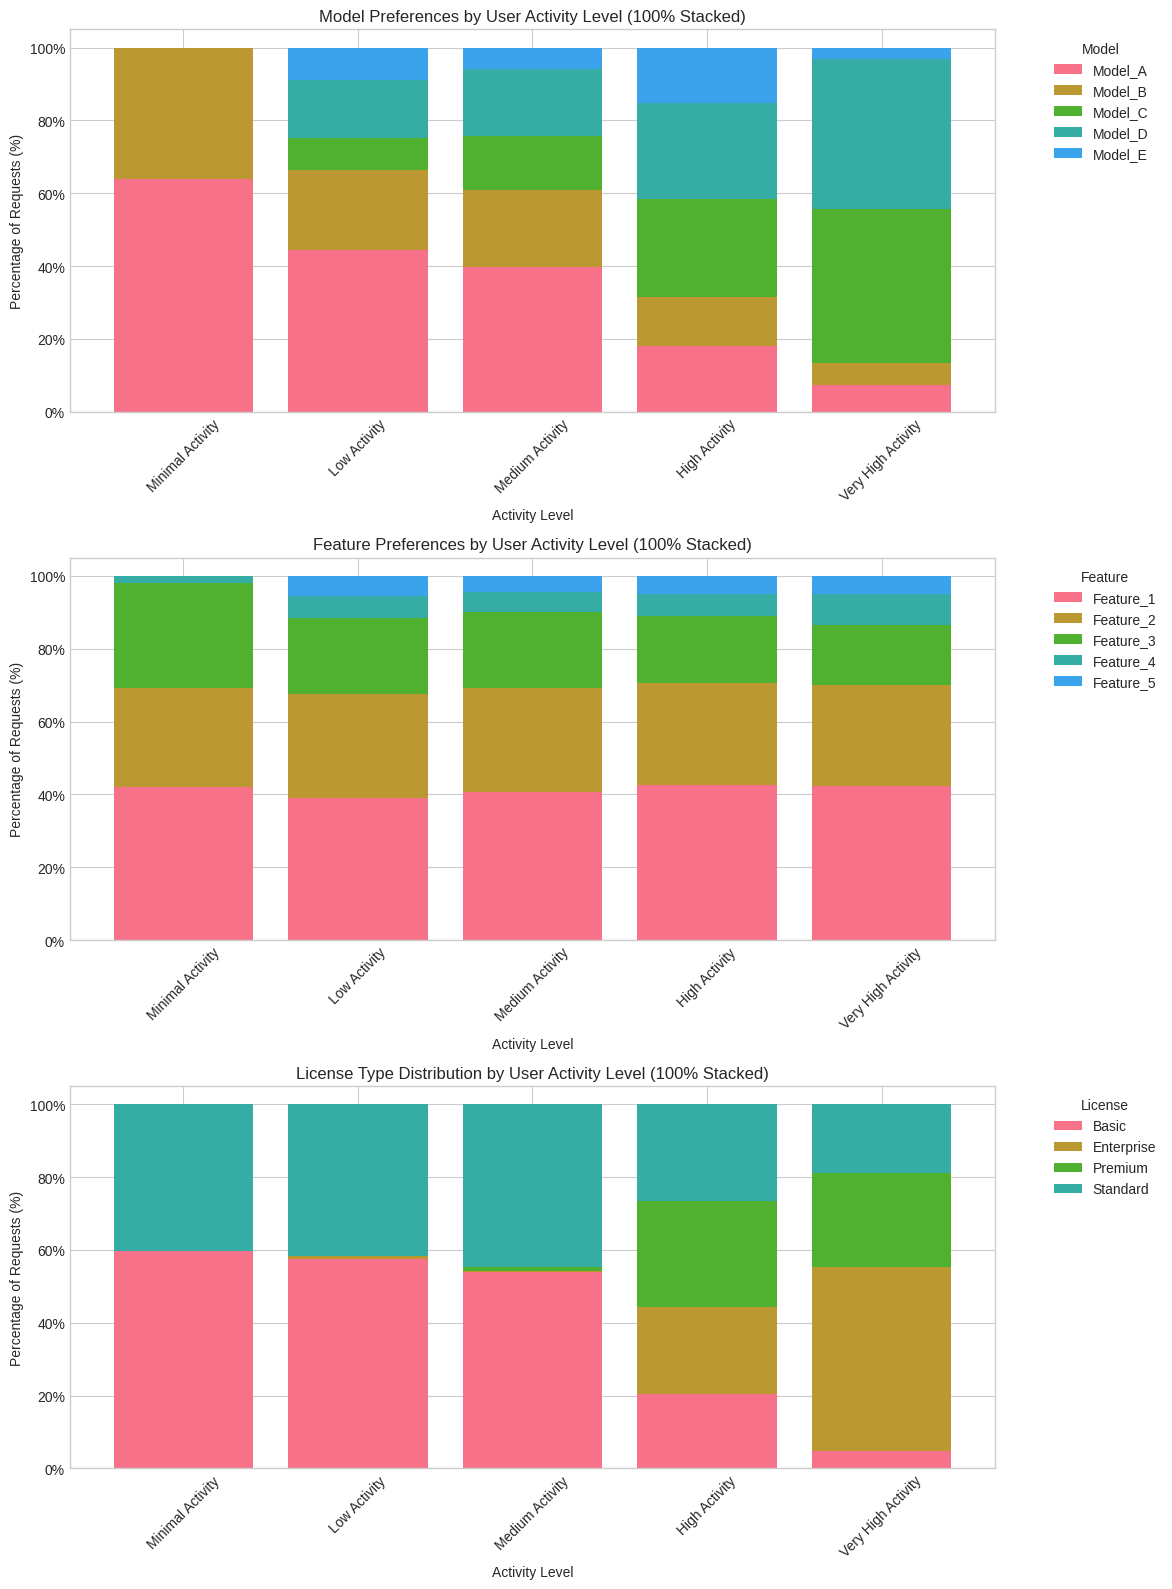


KEY INSIGHTS

Activity Level Summary:
  Minimal Activity: 28 users, 13 avg requests, $4.85 avg revenue
  Low Activity: 148 users, 57 avg requests, $17.82 avg revenue
  Medium Activity: 416 users, 442 avg requests, $132.46 avg revenue
  High Activity: 1187 users, 3659 avg requests, $901.76 avg revenue
  Very High Activity: 87 users, 20187 avg requests, $4283.29 avg revenue

Analysis complete! Check the visualizations above to see how user preferences
for models, features, and licenses change as users become more active.


In [21]:
# 5. Advanced Analysis: How User Preferences Change with Activity Level

print("ADVANCED ANALYSIS: USER PREFERENCES vs ACTIVITY LEVEL")
print("=" * 50)
print("Analyzing how preferences shift between low, medium, and high activity users...")

# Create comprehensive user dataset with activity levels and preferences
# We merge 'activity_level' from user_stats into the main df based on 'uuid'
# This links every *request* (from df) to its user's *activity segment*
user_activity_analysis = df.merge(user_stats[['activity_level']], left_on='uuid', right_index=True)

# Define activity groups for analysis (in logical order)
activity_groups = ['Minimal Activity', 'Low Activity', 'Medium Activity', 'High Activity', 'Very High Activity']

# Function to analyze preferences by activity level
def analyze_preferences_by_activity(category_col, title):
    print(f"\n{title} PREFERENCES BY ACTIVITY LEVEL")
    print("-" * 40)
    
    # Calculate preferences for each activity level
    preference_data = []
    
    for activity in activity_groups:
        # Check if this activity level exists in our data
        if activity in user_activity_analysis['activity_level'].values:
            subset = user_activity_analysis[user_activity_analysis['activity_level'] == activity]
            total_requests = subset['requests_cnt'].sum()
            
            # Get preference distribution (as percentage)
            prefs = subset.groupby(category_col)['requests_cnt'].sum().sort_values(ascending=False)
            prefs_pct = (prefs / total_requests * 100).round(1)
            
            print(f"\n{activity} Users ({len(subset['uuid'].unique())} users):")
            print(f"  Total requests: {total_requests:,}")
            
            for item, pct in prefs_pct.items():
                print(f"  {item}: {pct}%")
                preference_data.append({
                    'activity_level': activity,
                    category_col: item,
                    'percentage': pct,
                    'requests': prefs[item]
                })
        # else:
            # print(f"\nNo users found for {activity}") # Optional: for debugging
    
    return pd.DataFrame(preference_data)

# Analyze preferences for each category
print("\n" + "="*60)
model_prefs = analyze_preferences_by_activity('model', 'MODEL')

print("\n" + "="*60)
feature_prefs = analyze_preferences_by_activity('feature', 'FEATURE') 

print("\n" + "="*60)
license_prefs = analyze_preferences_by_activity('license', 'LICENSE')

# --- Create visualizations ---
fig, axes = plt.subplots(3, 1, figsize=(14, 16))

# Model preferences by activity level
if not model_prefs.empty:
    model_pivot = model_prefs.pivot(index='activity_level', columns='model', values='percentage').fillna(0)
    # Re-order the index to match our logical 'activity_groups' list
    model_pivot = model_pivot.reindex(activity_groups).dropna() 
    
    ax1 = axes[0]
    # We use a 100% stacked bar chart for a clearer comparison
    model_pivot.plot(kind='bar', stacked=True, ax=ax1, width=0.8) 
    ax1.set_title('Model Preferences by User Activity Level (100% Stacked)')
    ax1.set_xlabel('Activity Level')
    ax1.set_ylabel('Percentage of Requests (%)')
    ax1.legend(title='Model', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax1.tick_params(axis='x', rotation=45)
    ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%')) # Format Y axis

# Feature preferences by activity level  
if not feature_prefs.empty:
    feature_pivot = feature_prefs.pivot(index='activity_level', columns='feature', values='percentage').fillna(0)
    feature_pivot = feature_pivot.reindex(activity_groups).dropna()
    
    ax2 = axes[1]
    # Using 100% stacked bar for features as well
    feature_pivot.plot(kind='bar', stacked=True, ax=ax2, width=0.8)
    ax2.set_title('Feature Preferences by User Activity Level (100% Stacked)')
    ax2.set_xlabel('Activity Level')
    ax2.set_ylabel('Percentage of Requests (%)')
    ax2.legend(title='Feature', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.tick_params(axis='x', rotation=45)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

# License preferences by activity level
if not license_prefs.empty:
    license_pivot = license_prefs.pivot(index='activity_level', columns='license', values='percentage').fillna(0)
    license_pivot = license_pivot.reindex(activity_groups).dropna()
    
    ax3 = axes[2]
    # Using 100% stacked bar for licenses
    license_pivot.plot(kind='bar', stacked=True, ax=ax3, width=0.8)
    ax3.set_title('License Type Distribution by User Activity Level (100% Stacked)')
    ax3.set_xlabel('Activity Level')
    ax3.set_ylabel('Percentage of Requests (%)')
    ax3.legend(title='License', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax3.tick_params(axis='x', rotation=45)
    ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0f}%'))

plt.tight_layout(rect=[0, 0, 0.85, 1])
plt.show()

# --- Summary insights ---
print("\n" + "="*60)
print("KEY INSIGHTS")
print("="*60)

# Activity level insights
activity_summary = user_activity_analysis.groupby('activity_level').agg({
    'uuid': 'nunique',
    'requests_cnt': 'sum',
    'spent_amount': 'sum'
}).round(2)

print(f"\nActivity Level Summary:")
# Re-order the summary to match our logical 'activity_groups'
activity_summary = activity_summary.reindex(activity_groups).dropna()

for activity in activity_summary.index:
    stats = activity_summary.loc[activity]
    avg_requests = stats['requests_cnt'] / stats['uuid']
    avg_revenue = stats['spent_amount'] / stats['uuid']
    print(f"  {activity}: {stats['uuid']:.0f} users, {avg_requests:.0f} avg requests, ${avg_revenue:.2f} avg revenue")

print(f"\nAnalysis complete! Check the visualizations above to see how user preferences")
print(f"for models, features, and licenses change as users become more active.")

In [22]:
# Feature usage analysis and popularity
print("FEATURE ANALYSIS")
print("=" * 50)

# Feature usage statistics
feature_stats = df.groupby('feature').agg({
    'requests_cnt': ['sum', 'mean', 'count'],
    'spent_amount': ['sum', 'mean'],
    'uuid': 'nunique'
}).round(2)

feature_stats.columns = ['total_requests', 'avg_requests_per_record', 'record_count', 'total_revenue', 'avg_revenue_per_record', 'unique_users']

# Calculate additional metrics
feature_stats['avg_requests_per_user'] = (feature_stats['total_requests'] / feature_stats['unique_users']).round(1)
feature_stats['avg_revenue_per_user'] = (feature_stats['total_revenue'] / feature_stats['unique_users']).round(2)
feature_stats['market_share_requests'] = (feature_stats['total_requests'] / feature_stats['total_requests'].sum() * 100).round(1)
feature_stats['market_share_revenue'] = (feature_stats['total_revenue'] / feature_stats['total_revenue'].sum() * 100).round(1)

print("\nFeature Performance Summary:")
for feature in feature_stats.index:
    stats = feature_stats.loc[feature]
    print(f"\n{feature}:")
    print(f"  Users: {stats['unique_users']:,} ({stats['unique_users']/df['uuid'].nunique()*100:.1f}% of total)")
    print(f"  Total requests: {stats['total_requests']:,.0f} ({stats['market_share_requests']}% market share)")
    print(f"  Total revenue: ${stats['total_revenue']:,.2f} ({stats['market_share_revenue']}% market share)")
    print(f"  Avg requests per user: {stats['avg_requests_per_user']}")
    print(f"  Avg revenue per user: ${stats['avg_revenue_per_user']}")

# Sort by total revenue
feature_ranking = feature_stats.sort_values('total_revenue', ascending=False)
print(f"\nFeature Ranking by Revenue:")
for i, (feature, stats) in enumerate(feature_ranking.iterrows(), 1):
    print(f"  {i}. {feature}: ${stats['total_revenue']:,.2f}")

FEATURE ANALYSIS

Feature Performance Summary:

Feature_1:
  Users: 1,808.0 (96.9% of total)
  Total requests: 2,669,779 (42.4% market share)
  Total revenue: $610,509.16 (40.7% market share)
  Avg requests per user: 1476.6
  Avg revenue per user: $337.67

Feature_2:
  Users: 1,771.0 (94.9% of total)
  Total requests: 1,756,475 (27.9% market share)
  Total revenue: $432,843.51 (28.8% market share)
  Avg requests per user: 991.8
  Avg revenue per user: $244.41

Feature_3:
  Users: 1,733.0 (92.9% of total)
  Total requests: 1,135,679 (18.0% market share)
  Total revenue: $291,964.51 (19.5% market share)
  Avg requests per user: 655.3
  Avg revenue per user: $168.47

Feature_4:
  Users: 1,507.0 (80.8% of total)
  Total requests: 424,855 (6.8% market share)
  Total revenue: $95,352.19 (6.4% market share)
  Avg requests per user: 281.9
  Avg revenue per user: $63.27

Feature_5:
  Users: 1,508.0 (80.8% of total)
  Total requests: 305,263 (4.9% market share)
  Total revenue: $70,243.97 (4.7% 

In [23]:
# License type analysis and comparison
print("LICENSE TYPE ANALYSIS")
print("=" * 50)

# License usage statistics
license_stats = df.groupby('license').agg({
    'requests_cnt': ['sum', 'mean', 'count'],
    'spent_amount': ['sum', 'mean'],
    'uuid': 'nunique'
}).round(2)

license_stats.columns = ['total_requests', 'avg_requests_per_record', 'record_count', 'total_revenue', 'avg_revenue_per_record', 'unique_users']

# Calculate additional metrics
license_stats['avg_requests_per_user'] = (license_stats['total_requests'] / license_stats['unique_users']).round(1)
license_stats['avg_revenue_per_user'] = (license_stats['total_revenue'] / license_stats['unique_users']).round(2)
license_stats['market_share_requests'] = (license_stats['total_requests'] / license_stats['total_requests'].sum() * 100).round(1)
license_stats['market_share_revenue'] = (license_stats['total_revenue'] / license_stats['total_revenue'].sum() * 100).round(1)

print("\nLicense Performance Summary:")
for license_type in license_stats.index:
    stats = license_stats.loc[license_type]
    print(f"\n{license_type}:")
    print(f"  Users: {stats['unique_users']:,} ({stats['unique_users']/df['uuid'].nunique()*100:.1f}% of total)")
    print(f"  Total requests: {stats['total_requests']:,.0f} ({stats['market_share_requests']}% market share)")
    print(f"  Total revenue: ${stats['total_revenue']:,.2f} ({stats['market_share_revenue']}% market share)")
    print(f"  Avg requests per user: {stats['avg_requests_per_user']}")
    print(f"  Avg revenue per user: ${stats['avg_revenue_per_user']}")

# Sort by total revenue
license_ranking = license_stats.sort_values('total_revenue', ascending=False)
print(f"\nLicense Ranking by Revenue:")
for i, (license_type, stats) in enumerate(license_ranking.iterrows(), 1):
    print(f"  {i}. {license_type}: ${stats['total_revenue']:,.2f}")

# License profitability analysis
print(f"\nLicense Profitability (Revenue per User):")
license_profitability = license_stats.sort_values('avg_revenue_per_user', ascending=False)
for license_type, stats in license_profitability.iterrows():
    print(f"  {license_type}: ${stats['avg_revenue_per_user']}/user")

LICENSE TYPE ANALYSIS

License Performance Summary:

Basic:
  Users: 717.0 (38.4% of total)
  Total requests: 1,078,123 (17.1% market share)
  Total revenue: $256,253.86 (17.1% market share)
  Avg requests per user: 1503.7
  Avg revenue per user: $357.4

Enterprise:
  Users: 251.0 (13.5% of total)
  Total requests: 1,925,374 (30.6% market share)
  Total revenue: $473,237.77 (31.5% market share)
  Avg requests per user: 7670.8
  Avg revenue per user: $1885.41

Premium:
  Users: 247.0 (13.2% of total)
  Total requests: 1,719,628 (27.3% market share)
  Total revenue: $403,971.50 (26.9% market share)
  Avg requests per user: 6962.1
  Avg revenue per user: $1635.51

Standard:
  Users: 708.0 (37.9% of total)
  Total requests: 1,568,926 (24.9% market share)
  Total revenue: $367,450.21 (24.5% market share)
  Avg requests per user: 2216.0
  Avg revenue per user: $519.0

License Ranking by Revenue:
  1. Enterprise: $473,237.77
  2. Premium: $403,971.50
  3. Standard: $367,450.21
  4. Basic: $25

In [24]:
# Model usage analysis and popularity
print("MODEL ANALYSIS")
print("=" * 50)

# Model usage statistics
model_stats = df.groupby('model').agg({
    'requests_cnt': ['sum', 'mean', 'count'],
    'spent_amount': ['sum', 'mean'],
    'uuid': 'nunique'
}).round(2)

model_stats.columns = ['total_requests', 'avg_requests_per_record', 'record_count', 'total_revenue', 'avg_revenue_per_record', 'unique_users']

# Calculate additional metrics
model_stats['avg_requests_per_user'] = (model_stats['total_requests'] / model_stats['unique_users']).round(1)
model_stats['avg_revenue_per_user'] = (model_stats['total_revenue'] / model_stats['unique_users']).round(2)
model_stats['market_share_requests'] = (model_stats['total_requests'] / model_stats['total_requests'].sum() * 100).round(1)
model_stats['market_share_revenue'] = (model_stats['total_revenue'] / model_stats['total_revenue'].sum() * 100).round(1)

print("\nModel Performance Summary:")
for model in model_stats.index:
    stats = model_stats.loc[model]
    print(f"\n{model}:")
    print(f"  Users: {stats['unique_users']:,} ({stats['unique_users']/df['uuid'].nunique()*100:.1f}% of total)")
    print(f"  Total requests: {stats['total_requests']:,.0f} ({stats['market_share_requests']}% market share)")
    print(f"  Total revenue: ${stats['total_revenue']:,.2f} ({stats['market_share_revenue']}% market share)")
    print(f"  Avg requests per user: {stats['avg_requests_per_user']}")
    print(f"  Avg revenue per user: ${stats['avg_revenue_per_user']}")

# Sort by total revenue
model_ranking = model_stats.sort_values('total_revenue', ascending=False)
print(f"\nModel Ranking by Revenue:")
for i, (model, stats) in enumerate(model_ranking.iterrows(), 1):
    print(f"  {i}. {model}: ${stats['total_revenue']:,.2f}")

MODEL ANALYSIS

Model Performance Summary:

Model_A:
  Users: 843.0 (45.2% of total)
  Total requests: 991,933 (15.8% market share)
  Total revenue: $365,077.08 (24.3% market share)
  Avg requests per user: 1176.7
  Avg revenue per user: $433.07

Model_B:
  Users: 610.0 (32.7% of total)
  Total requests: 730,371 (11.6% market share)
  Total revenue: $268,166.08 (17.9% market share)
  Avg requests per user: 1197.3
  Avg revenue per user: $439.62

Model_C:
  Users: 644.0 (34.5% of total)
  Total requests: 1,941,796 (30.9% market share)
  Total revenue: $366,621.74 (24.4% market share)
  Avg requests per user: 3015.2
  Avg revenue per user: $569.29

Model_D:
  Users: 705.0 (37.8% of total)
  Total requests: 1,894,150 (30.1% market share)
  Total revenue: $361,607.23 (24.1% market share)
  Avg requests per user: 2686.7
  Avg revenue per user: $512.92

Model_E:
  Users: 441.0 (23.6% of total)
  Total requests: 733,801 (11.7% market share)
  Total revenue: $139,441.21 (9.3% market share)
  A

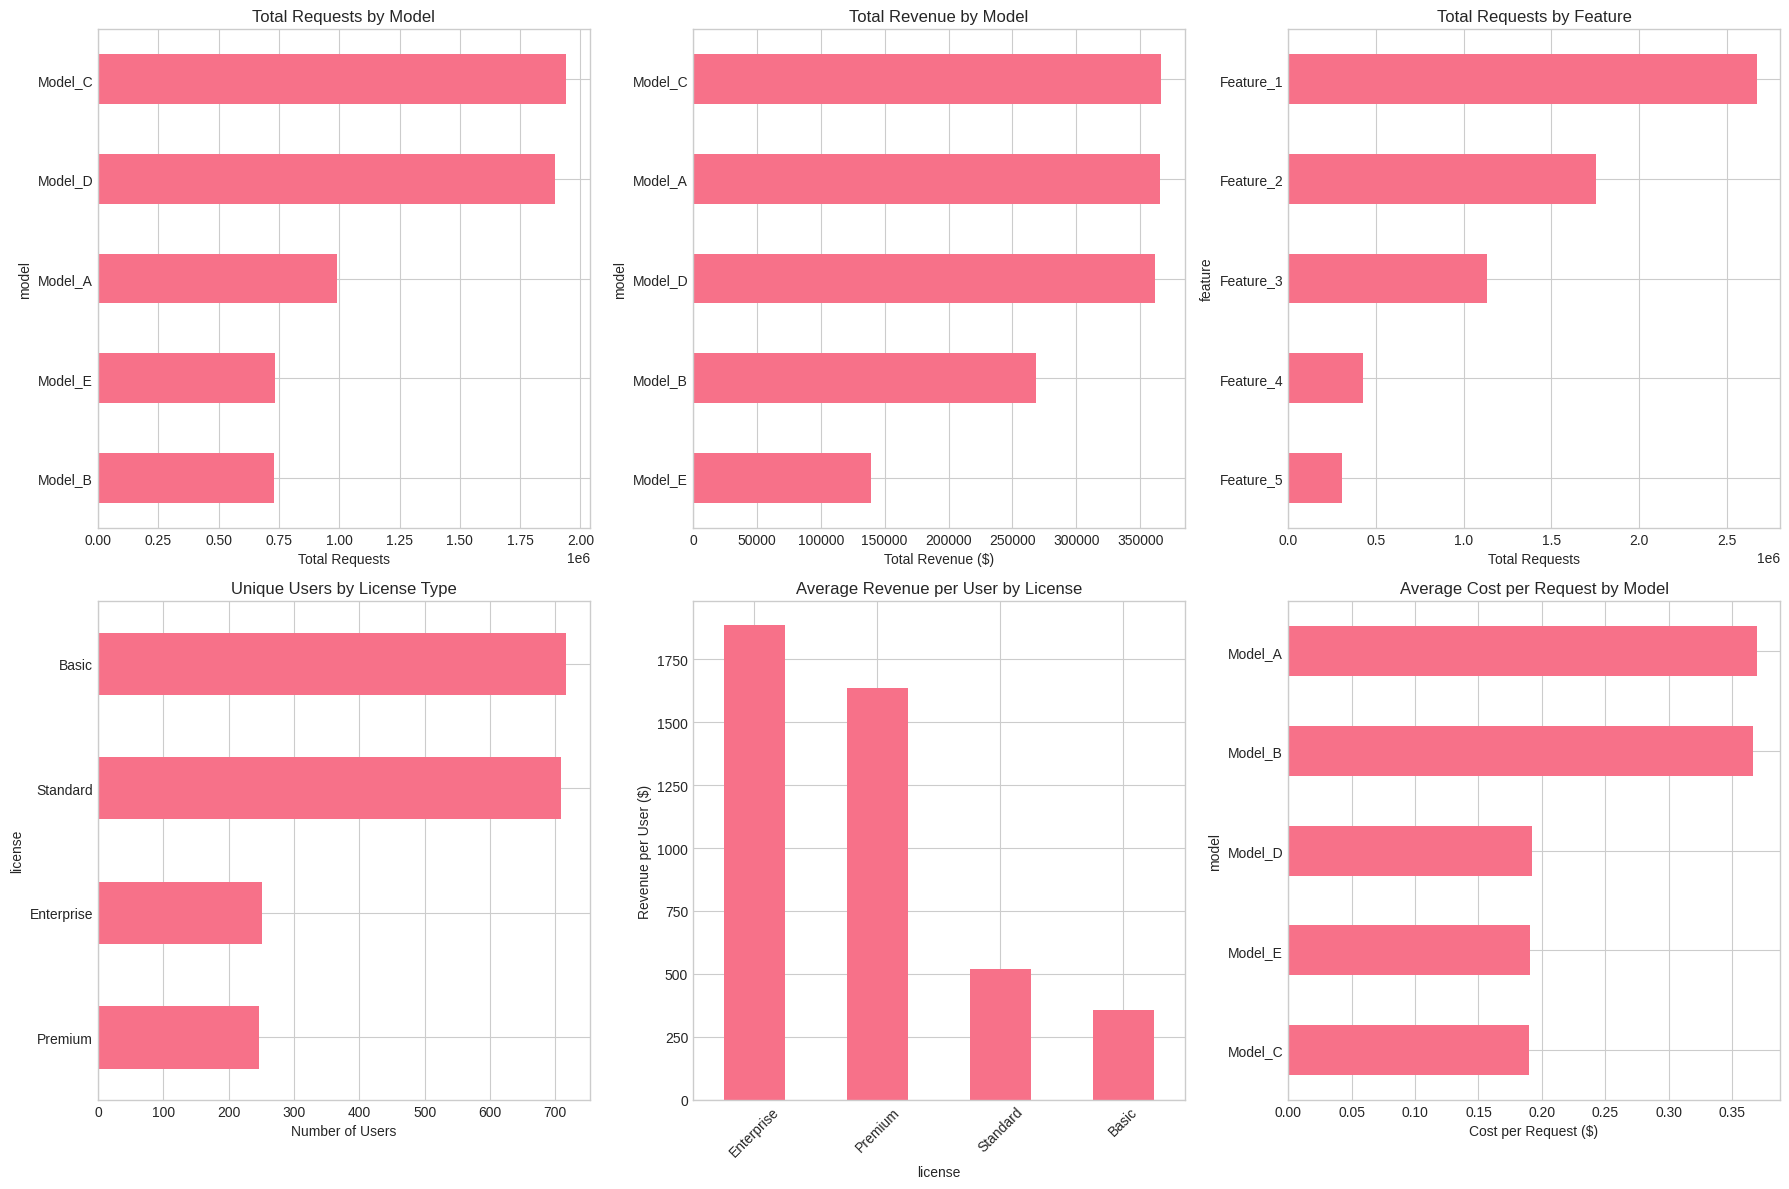

In [25]:
# Create comprehensive product analysis visualizations
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Model market share by requests
ax1 = axes[0, 0]
model_requests = model_stats.sort_values('total_requests', ascending=True)
model_requests['total_requests'].plot(kind='barh', ax=ax1)
ax1.set_title('Total Requests by Model')
ax1.set_xlabel('Total Requests')

# Model market share by revenue
ax2 = axes[0, 1]
model_revenue = model_stats.sort_values('total_revenue', ascending=True)
model_revenue['total_revenue'].plot(kind='barh', ax=ax2)
ax2.set_title('Total Revenue by Model')
ax2.set_xlabel('Total Revenue ($)')

# Feature market share by requests
ax3 = axes[0, 2]
feature_requests = feature_stats.sort_values('total_requests', ascending=True)
feature_requests['total_requests'].plot(kind='barh', ax=ax3)
ax3.set_title('Total Requests by Feature')
ax3.set_xlabel('Total Requests')

# License distribution by users
ax4 = axes[1, 0]
license_users = license_stats.sort_values('unique_users', ascending=True)
license_users['unique_users'].plot(kind='barh', ax=ax4)
ax4.set_title('Unique Users by License Type')
ax4.set_xlabel('Number of Users')

# Revenue per user comparison
ax5 = axes[1, 1]
license_profitability['avg_revenue_per_user'].plot(kind='bar', ax=ax5)
ax5.set_title('Average Revenue per User by License')
ax5.set_ylabel('Revenue per User ($)')
ax5.tick_params(axis='x', rotation=45)

# Cost per request by model
ax6 = axes[1, 2]
model_cost_comparison = df.groupby('model')['cost_per_request'].mean().sort_values(ascending=True)
model_cost_comparison.plot(kind='barh', ax=ax6)
ax6.set_title('Average Cost per Request by Model')
ax6.set_xlabel('Cost per Request ($)')

plt.tight_layout()
plt.show()

## 6. Temporal Trends Analysis

In [26]:
# Daily trends analysis
print("DAILY TRENDS ANALYSIS")
print("=" * 50)

# Daily aggregations
daily_trends = df.groupby('day_id').agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

daily_trends.columns = ['date', 'total_requests', 'total_revenue', 'active_users']
daily_trends['avg_requests_per_user'] = (daily_trends['total_requests'] / daily_trends['active_users']).round(1)
daily_trends['avg_revenue_per_user'] = (daily_trends['total_revenue'] / daily_trends['active_users']).round(2)

print(f"\nDaily Activity Summary:")
print(f"  Average daily requests: {daily_trends['total_requests'].mean():,.0f}")
print(f"  Average daily revenue: ${daily_trends['total_revenue'].mean():,.2f}")
print(f"  Average daily active users: {daily_trends['active_users'].mean():,.0f}")
print(f"  Peak day requests: {daily_trends['total_requests'].max():,} ({daily_trends.loc[daily_trends['total_requests'].idxmax(), 'date'].strftime('%Y-%m-%d')})")
print(f"  Peak day revenue: ${daily_trends['total_revenue'].max():,.2f} ({daily_trends.loc[daily_trends['total_revenue'].idxmax(), 'date'].strftime('%Y-%m-%d')})")

# Day of week analysis
daily_trends['day_of_week'] = daily_trends['date'].dt.day_name()
daily_trends['day_of_week_num'] = daily_trends['date'].dt.dayofweek

dow_analysis = daily_trends.groupby('day_of_week').agg({
    'total_requests': 'mean',
    'total_revenue': 'mean',
    'active_users': 'mean'
}).round(2)

# Sort by day of week
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_analysis = dow_analysis.reindex(day_order)

print(f"\nDay of Week Patterns:")
for day, stats in dow_analysis.iterrows():
    print(f"  {day}: {stats['total_requests']:,.0f} requests, ${stats['total_revenue']:,.2f} revenue, {stats['active_users']:,.0f} users")

DAILY TRENDS ANALYSIS

Daily Activity Summary:
  Average daily requests: 68,392
  Average daily revenue: $16,314.28
  Average daily active users: 716
  Peak day requests: 121,083 (2025-05-07)
  Peak day revenue: $28,232.01 (2025-04-17)

Day of Week Patterns:
  Monday: 86,522 requests, $20,818.69 revenue, 914 users
  Tuesday: 88,080 requests, $20,819.93 revenue, 883 users
  Wednesday: 84,709 requests, $20,075.44 revenue, 891 users
  Thursday: 84,404 requests, $20,408.15 revenue, 897 users
  Friday: 91,259 requests, $21,722.39 revenue, 928 users
  Saturday: 25,362 requests, $5,963.24 revenue, 269 users
  Sunday: 21,717 requests, $5,188.32 revenue, 266 users


In [27]:
# Weekly and monthly trends
print("WEEKLY AND MONTHLY TRENDS")
print("=" * 50)

# Weekly trends
weekly_trends = df.groupby(['year', 'week_number']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

weekly_trends.columns = ['year', 'week', 'total_requests', 'total_revenue', 'active_users']
weekly_trends['week_id'] = weekly_trends['year'].astype(str) + '-W' + weekly_trends['week'].astype(str).str.zfill(2)

print(f"\nWeekly Trends:")
print(f"  Total weeks analyzed: {len(weekly_trends)}")
print(f"  Average weekly requests: {weekly_trends['total_requests'].mean():,.0f}")
print(f"  Average weekly revenue: ${weekly_trends['total_revenue'].mean():,.2f}")
print(f"  Best performing week: {weekly_trends.loc[weekly_trends['total_revenue'].idxmax(), 'week_id']} (${weekly_trends['total_revenue'].max():,.2f})")

# Monthly trends 
monthly_trends = df.groupby('month_name').agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reindex(['March', 'April', 'May'])

monthly_trends.columns = ['total_requests', 'total_revenue', 'active_users']
monthly_trends['avg_requests_per_user'] = (monthly_trends['total_requests'] / monthly_trends['active_users']).round(1)
monthly_trends['avg_revenue_per_user'] = (monthly_trends['total_revenue'] / monthly_trends['active_users']).round(2)

print(f"\nMonthly Growth Analysis:")
for month, stats in monthly_trends.iterrows():
    print(f"\n{month}:")
    print(f"  Total requests: {stats['total_requests']:,}")
    print(f"  Total revenue: ${stats['total_revenue']:,.2f}")
    print(f"  Active users: {stats['active_users']:,}")
    print(f"  Requests per user: {stats['avg_requests_per_user']}")
    print(f"  Revenue per user: ${stats['avg_revenue_per_user']}")

# Calculate month-over-month growth
print(f"\nMonth-over-Month Growth:")
for i in range(1, len(monthly_trends)):
    current_month = monthly_trends.index[i]
    prev_month = monthly_trends.index[i-1]
    
    revenue_growth = ((monthly_trends.loc[current_month, 'total_revenue'] - monthly_trends.loc[prev_month, 'total_revenue']) / monthly_trends.loc[prev_month, 'total_revenue'] * 100)
    requests_growth = ((monthly_trends.loc[current_month, 'total_requests'] - monthly_trends.loc[prev_month, 'total_requests']) / monthly_trends.loc[prev_month, 'total_requests'] * 100)
    
    print(f"  {prev_month} to {current_month}: {revenue_growth:+.1f}% revenue, {requests_growth:+.1f}% requests")

WEEKLY AND MONTHLY TRENDS

Weekly Trends:
  Total weeks analyzed: 14
  Average weekly requests: 449,432
  Average weekly revenue: $107,208.10
  Best performing week: 2025-W21 ($137,326.90)

Monthly Growth Analysis:

March:
  Total requests: 1,668,402.0
  Total revenue: $403,473.18
  Active users: 1,455.0
  Requests per user: 1146.7
  Revenue per user: $277.3

April:
  Total requests: 2,056,461.0
  Total revenue: $494,638.82
  Active users: 1,638.0
  Requests per user: 1255.5
  Revenue per user: $301.98

May:
  Total requests: 2,567,188.0
  Total revenue: $602,801.34
  Active users: 1,864.0
  Requests per user: 1377.2
  Revenue per user: $323.39

Month-over-Month Growth:
  March to April: +22.6% revenue, +23.3% requests
  April to May: +21.9% revenue, +24.8% requests


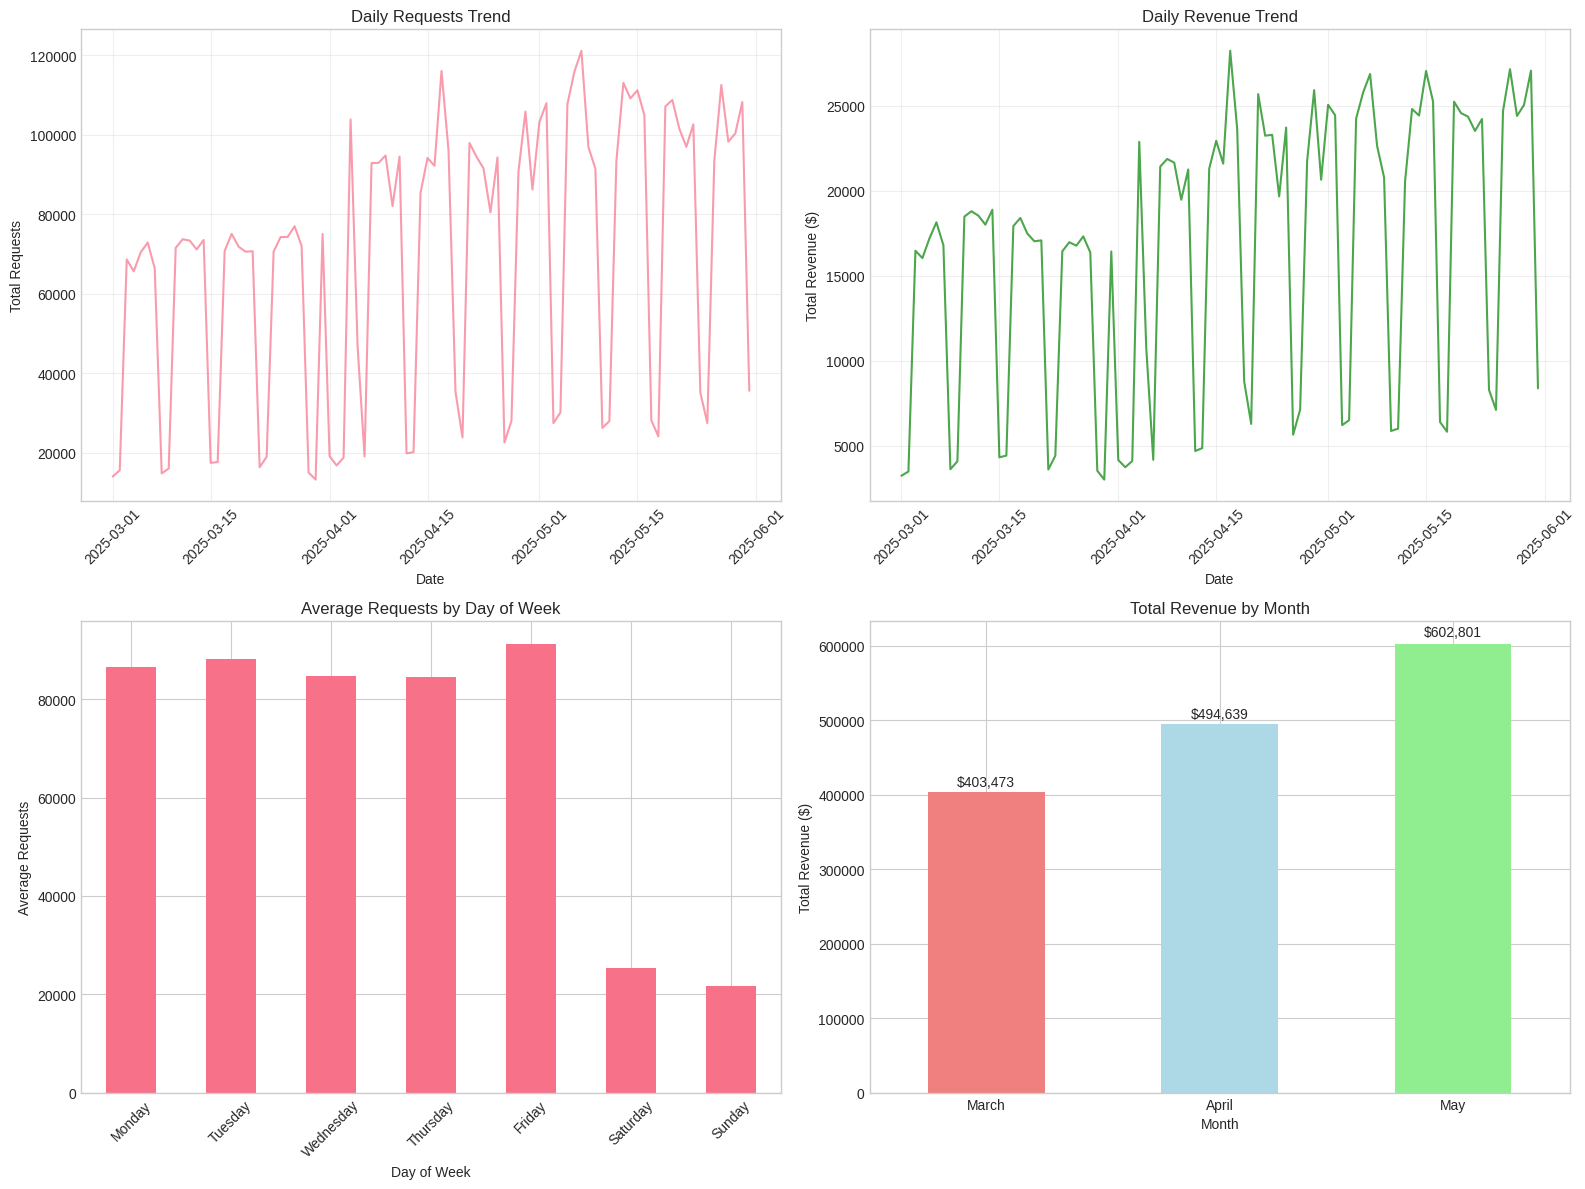

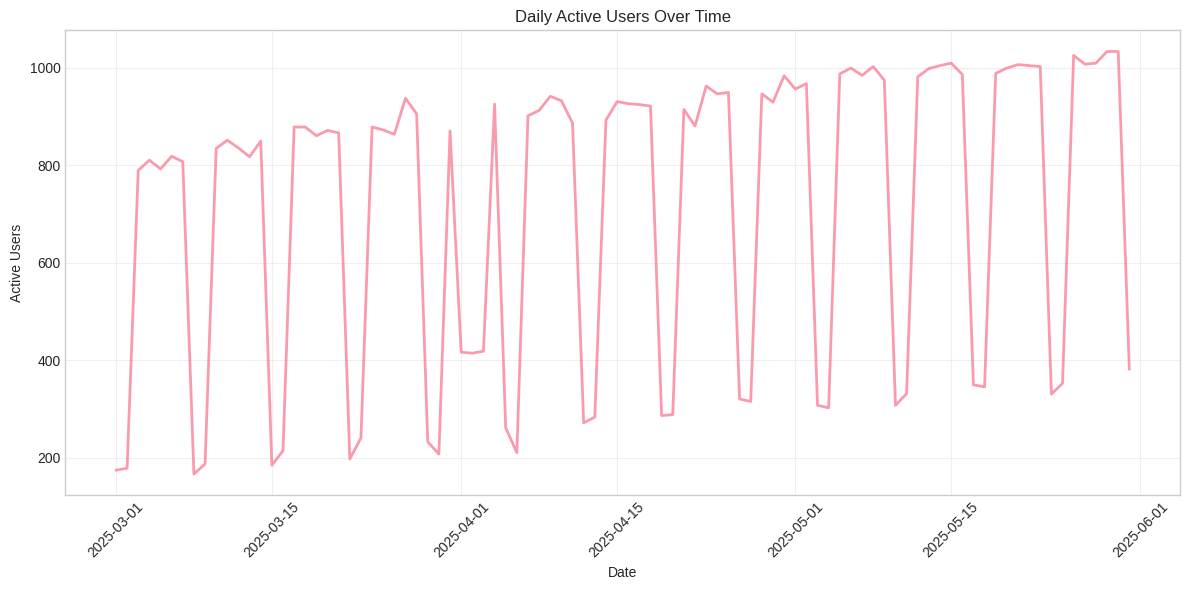

In [28]:
# Temporal trends visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Daily trends over time
ax1 = axes[0, 0]
ax1.plot(daily_trends['date'], daily_trends['total_requests'], label='Requests', alpha=0.7)
ax1.set_title('Daily Requests Trend')
ax1.set_xlabel('Date')
ax1.set_ylabel('Total Requests')
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

# Daily revenue trends
ax2 = axes[0, 1]
ax2.plot(daily_trends['date'], daily_trends['total_revenue'], label='Revenue', color='green', alpha=0.7)
ax2.set_title('Daily Revenue Trend')
ax2.set_xlabel('Date')
ax2.set_ylabel('Total Revenue ($)')
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3)

# Day of week patterns
ax3 = axes[1, 0]
dow_analysis['total_requests'].plot(kind='bar', ax=ax3)
ax3.set_title('Average Requests by Day of Week')
ax3.set_xlabel('Day of Week')
ax3.set_ylabel('Average Requests')
ax3.tick_params(axis='x', rotation=45)

# Monthly comparison
ax4 = axes[1, 1]
monthly_trends['total_revenue'].plot(kind='bar', ax=ax4, color=['lightcoral', 'lightblue', 'lightgreen'])
ax4.set_title('Total Revenue by Month')
ax4.set_xlabel('Month')
ax4.set_ylabel('Total Revenue ($)')
ax4.tick_params(axis='x', rotation=0)

# Add values on top of bars
for i, v in enumerate(monthly_trends['total_revenue']):
    ax4.text(i, v + v*0.01, f'${v:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Additional insights: Active users over time
plt.figure(figsize=(12, 6))
plt.plot(daily_trends['date'], daily_trends['active_users'], alpha=0.7, linewidth=2)
plt.title('Daily Active Users Over Time')
plt.xlabel('Date')
plt.ylabel('Active Users')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Cross-dimensional Analysis

In [29]:
# Model vs Feature combinations analysis
print("MODEL vs FEATURE COMBINATIONS")
print("=" * 50)

# Create cross-tabulation for model-feature combinations
model_feature_pivot = df.pivot_table(
    values=['requests_cnt', 'spent_amount'], 
    index='model', 
    columns='feature', 
    aggfunc='sum', 
    fill_value=0
)

# Requests by model-feature combination
print("\nTotal Requests by Model-Feature Combinations:")
requests_pivot = model_feature_pivot['requests_cnt']
print(requests_pivot.round(0).astype(int))

# Revenue by model-feature combination
print("\nTotal Revenue by Model-Feature Combinations:")
revenue_pivot = model_feature_pivot['spent_amount']
print(revenue_pivot.round(2))

# Calculate market share for each combination
total_requests = df['requests_cnt'].sum()
total_revenue = df['spent_amount'].sum()

print(f"\nMarket Share by Model-Feature Combinations (% of total requests):")
market_share_requests = (requests_pivot / total_requests * 100).round(1)
print(market_share_requests)

# Identify top performing combinations
model_feature_summary = df.groupby(['model', 'feature']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

model_feature_summary['revenue_share'] = (model_feature_summary['spent_amount'] / total_revenue * 100).round(1)
model_feature_summary = model_feature_summary.sort_values('spent_amount', ascending=False)

print(f"\nTop 10 Model-Feature Combinations by Revenue:")
for i, row in model_feature_summary.head(10).iterrows():
    print(f"  {row['model']} + {row['feature']}: ${row['spent_amount']:,.2f} ({row['revenue_share']}%)")

MODEL vs FEATURE COMBINATIONS

Total Requests by Model-Feature Combinations:
feature  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
model                                                         
Model_A     363290     295124     231346      69566      32607
Model_B     241452     252778     184196      16497      35448
Model_C     937253     404161     358344     162050      79988
Model_D     798043     603601     251417     124580     116509
Model_E     329741     200811     110376      52162      40711

Total Revenue by Model-Feature Combinations:
feature  Feature_1  Feature_2  Feature_3  Feature_4  Feature_5
model                                                         
Model_A  132156.26  108921.86   86720.72   25076.05   12202.19
Model_B   88108.55   94703.35   66621.11    5837.73   12895.34
Model_C  174753.50   76716.27   68348.54   31964.58   14838.85
Model_D  152775.56  114626.67   48922.41   22862.91   22419.68
Model_E   62715.29   37875.36   21351.73    9610.92    788

In [30]:
# License vs Model preferences analysis
print("LICENSE vs MODEL PREFERENCES")
print("=" * 50)

# License-model combinations
license_model_analysis = df.groupby(['license', 'model']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

# Calculate preferences within each license type
license_model_prefs = df.groupby('license')['model'].value_counts(normalize=True).round(3) * 100

print("\nModel Preferences by License Type (% of requests within license):")
for license_type in df['license'].unique():
    print(f"\n{license_type} License:")
    license_data = license_model_prefs[license_type].sort_values(ascending=False)
    for model, percentage in license_data.items():
        print(f"  {model}: {percentage:.1f}%")

# Revenue per user by license-model combination
license_model_detailed = df.groupby(['license', 'model']).agg({
    'requests_cnt': 'sum',
    'spent_amount': 'sum',
    'uuid': 'nunique'
}).reset_index()

license_model_detailed['revenue_per_user'] = (license_model_detailed['spent_amount'] / license_model_detailed['uuid']).round(2)
license_model_detailed['requests_per_user'] = (license_model_detailed['requests_cnt'] / license_model_detailed['uuid']).round(1)

print(f"\nRevenue per User by License-Model Combinations:")
top_combinations = license_model_detailed.sort_values('revenue_per_user', ascending=False).head(10)
for i, row in top_combinations.iterrows():
    print(f"  {row['license']} + {row['model']}: ${row['revenue_per_user']}/user ({row['requests_per_user']} req/user)")

LICENSE vs MODEL PREFERENCES

Model Preferences by License Type (% of requests within license):

Premium License:
  Model_A: 26.7%
  Model_B: 21.6%
  Model_C: 20.9%
  Model_D: 17.8%
  Model_E: 13.0%

Basic License:
  Model_A: 33.0%
  Model_D: 21.4%
  Model_C: 21.0%
  Model_B: 16.4%
  Model_E: 8.1%

Enterprise License:
  Model_A: 30.6%
  Model_C: 19.3%
  Model_D: 19.2%
  Model_B: 18.3%
  Model_E: 12.6%

Standard License:
  Model_A: 31.7%
  Model_D: 20.1%
  Model_B: 20.0%
  Model_C: 18.5%
  Model_E: 9.8%

Revenue per User by License-Model Combinations:
  Enterprise + Model_B: $1290.17/user (3510.9 req/user)
  Premium + Model_C: $1216.9/user (6439.8 req/user)
  Enterprise + Model_D: $1141.83/user (5962.4 req/user)
  Enterprise + Model_C: $1012.49/user (5357.0 req/user)
  Enterprise + Model_A: $997.42/user (2715.1 req/user)
  Premium + Model_A: $925.58/user (2505.0 req/user)
  Premium + Model_D: $909.05/user (4721.1 req/user)
  Premium + Model_B: $773.85/user (2105.6 req/user)
  Enterprise

In [31]:
# Feature usage patterns by license type
print("FEATURE USAGE BY LICENSE TYPE")
print("=" * 50)

# Feature preferences by license
license_feature_prefs = df.groupby('license')['feature'].value_counts(normalize=True).round(3) * 100

print("\nFeature Preferences by License Type (% of requests within license):")
for license_type in df['license'].unique():
    print(f"\n{license_type} License:")
    license_data = license_feature_prefs[license_type].sort_values(ascending=False)
    for feature, percentage in license_data.items():
        print(f"  {feature}: {percentage:.1f}%")

# Feature adoption rates by license
feature_adoption = df.groupby(['license', 'feature']).agg({
    'uuid': 'nunique'
}).reset_index()

# Get total users per license for adoption rate calculation
users_per_license = df.groupby('license')['uuid'].nunique()

feature_adoption_rates = []
for license_type in df['license'].unique():
    total_users = users_per_license[license_type]
    license_data = feature_adoption[feature_adoption['license'] == license_type]
    
    print(f"\nFeature Adoption Rates for {license_type} License:")
    for _, row in license_data.iterrows():
        adoption_rate = (row['uuid'] / total_users) * 100
        print(f"  {row['feature']}: {row['uuid']:,} users ({adoption_rate:.1f}% adoption)")

# Advanced segment analysis: Premium features vs Basic usage
print(f"\n" + "="*50)
print("ADVANCED INSIGHTS")
print("="*50)

# Cost efficiency by license-feature combinations
license_feature_efficiency = df.groupby(['license', 'feature']).agg({
    'cost_per_request': 'mean',
    'requests_cnt': 'sum',
    'spent_amount': 'sum'
}).round(3)

print(f"\nMost Cost-Efficient License-Feature Combinations:")
efficiency_ranking = license_feature_efficiency.sort_values('cost_per_request').head(10)
for (license_type, feature), stats in efficiency_ranking.iterrows():
    print(f"  {license_type} + {feature}: ${stats['cost_per_request']:.3f} per request")

FEATURE USAGE BY LICENSE TYPE

Feature Preferences by License Type (% of requests within license):



Premium License:
  Feature_1: 36.6%
  Feature_2: 29.6%
  Feature_3: 21.7%
  Feature_5: 6.3%
  Feature_4: 5.8%

Basic License:
  Feature_1: 37.3%
  Feature_2: 29.7%
  Feature_3: 21.5%
  Feature_4: 5.8%
  Feature_5: 5.6%

Enterprise License:
  Feature_1: 36.3%
  Feature_2: 29.6%
  Feature_3: 21.6%
  Feature_5: 6.3%
  Feature_4: 6.3%

Standard License:
  Feature_1: 37.3%
  Feature_2: 29.9%
  Feature_3: 21.0%
  Feature_5: 6.0%
  Feature_4: 5.8%

Feature Adoption Rates for Premium License:
  Feature_1: 247 users (100.0% adoption)
  Feature_2: 246 users (99.6% adoption)
  Feature_3: 246 users (99.6% adoption)
  Feature_4: 243 users (98.4% adoption)
  Feature_5: 244 users (98.8% adoption)

Feature Adoption Rates for Basic License:
  Feature_1: 687 users (95.8% adoption)
  Feature_2: 672 users (93.7% adoption)
  Feature_3: 653 users (91.1% adoption)
  Feature_4: 541 users (75.5% adoption)
  Feature_5: 538 users (75.0% adoption)

Feature Adoption Rates for Enterprise License:
  Feature_1: 250 

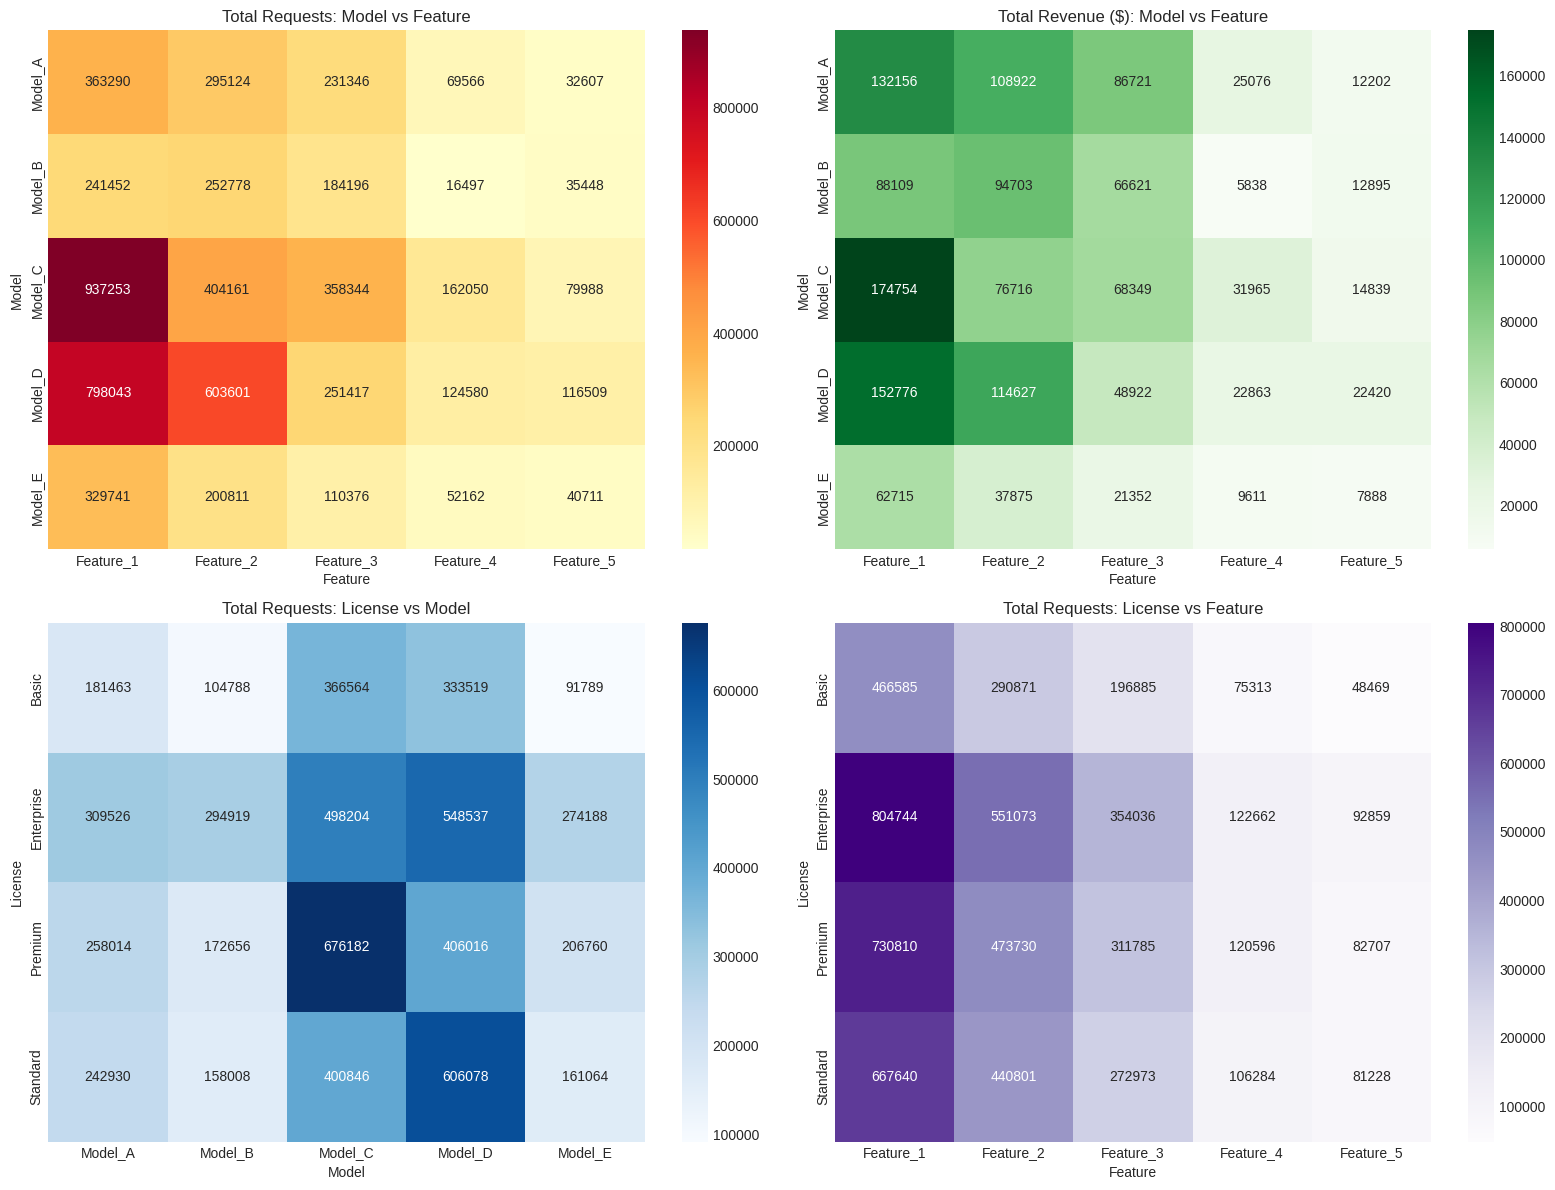

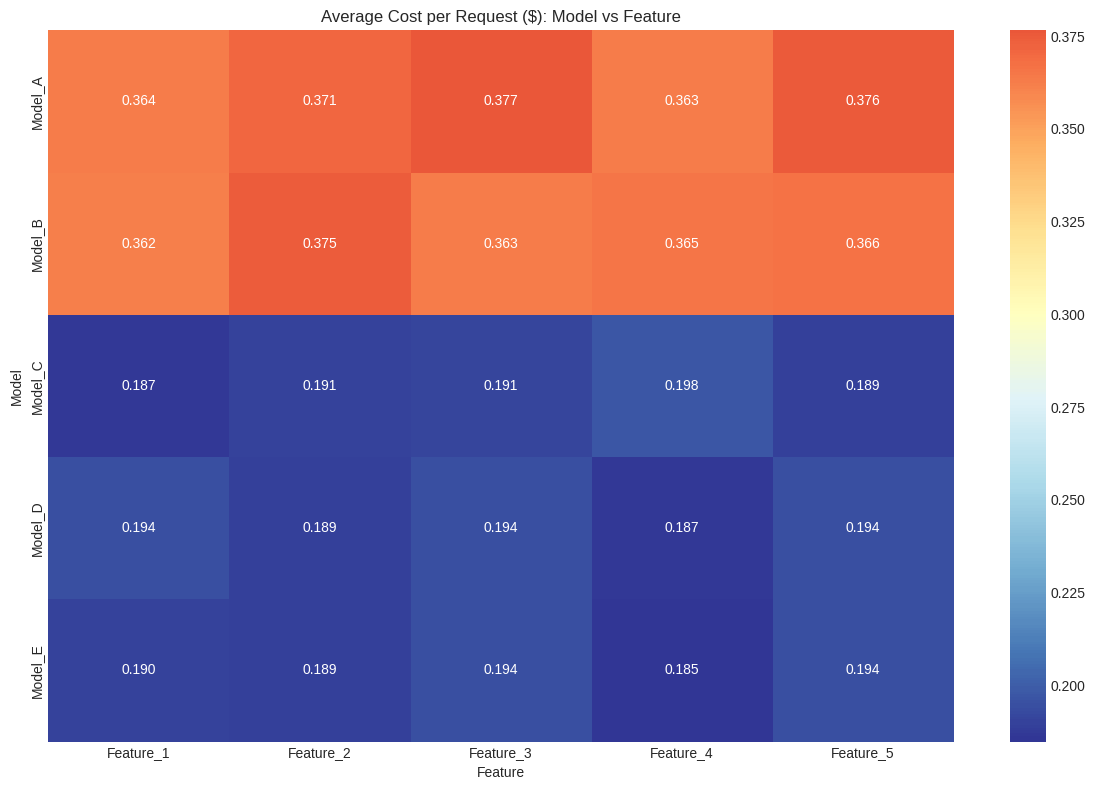

In [32]:
# Create comprehensive cross-dimensional heatmaps
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Model-Feature requests heatmap
ax1 = axes[0, 0]
sns.heatmap(requests_pivot, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax1)
ax1.set_title('Total Requests: Model vs Feature')
ax1.set_xlabel('Feature')
ax1.set_ylabel('Model')

# Model-Feature revenue heatmap
ax2 = axes[0, 1]
sns.heatmap(revenue_pivot, annot=True, fmt='.0f', cmap='Greens', ax=ax2)
ax2.set_title('Total Revenue ($): Model vs Feature')
ax2.set_xlabel('Feature')
ax2.set_ylabel('Model')

# License-Model requests distribution
license_model_pivot = df.pivot_table(
    values='requests_cnt', 
    index='license', 
    columns='model', 
    aggfunc='sum', 
    fill_value=0
)
ax3 = axes[1, 0]
sns.heatmap(license_model_pivot, annot=True, fmt='.0f', cmap='Blues', ax=ax3)
ax3.set_title('Total Requests: License vs Model')
ax3.set_xlabel('Model')
ax3.set_ylabel('License')

# License-Feature requests distribution
license_feature_pivot = df.pivot_table(
    values='requests_cnt', 
    index='license', 
    columns='feature', 
    aggfunc='sum', 
    fill_value=0
)
ax4 = axes[1, 1]
sns.heatmap(license_feature_pivot, annot=True, fmt='.0f', cmap='Purples', ax=ax4)
ax4.set_title('Total Requests: License vs Feature')
ax4.set_xlabel('Feature')
ax4.set_ylabel('License')

plt.tight_layout()
plt.show()

# Additional visualization: Cost per request by combinations
plt.figure(figsize=(12, 8))
cost_per_request_pivot = df.pivot_table(
    values='cost_per_request', 
    index='model', 
    columns='feature', 
    aggfunc='mean', 
    fill_value=0
)
sns.heatmap(cost_per_request_pivot, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0.3)
plt.title('Average Cost per Request ($): Model vs Feature')
plt.xlabel('Feature')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

## 8. Business Recommendations & Key Findings

### 8.1 Executive Summary of Key Findings

Based on the comprehensive analysis of 3 months of LLM usage data in IDEs (122,746 records, 1,866 users), here are the critical business insights:

#### 📈 **Business Growth Trajectory**
- **Strong month-over-month growth**: +22-25% in both revenue and requests
- **Growing revenue per user**: $277 (March) → $323 (May), +17% improvement
- **Expanding user base**: 1,455 → 1,864 active users (+28%)

#### 💰 **Revenue Segmentation**
- **Premium/Enterprise users** (27% of users) generate **58% of revenue**
- **High-activity users** (68% of base) contribute **70%+ of revenue**
- **Enterprise customers** are 5x more profitable: $1,885/user vs $357/user (Basic)

#### 🔧 **Product Performance**
- **Model_C dominates**: 31% market share in requests, top revenue generator
- **Feature_1 is essential**: 97% user adoption, 42% of all requests
- **Feature_4/5 underutilized**: Only 6% market share each, opportunity for growth

#### ⏰ **Usage Patterns**
- **Strong weekday focus**: 70% drop in weekend activity
- **B2B nature confirmed**: Peak usage Monday-Friday
- **Friday peak**: Highest daily activity (91K requests average)

### 8.2 Strategic Recommendations

#### 🎯 **1. Revenue Optimization (High Priority)**

**Focus on Enterprise/Premium Growth:**
- Target Enterprise segment expansion - they generate 5x revenue per user
- Develop Enterprise-specific features and dedicated support
- Create Premium upgrade incentives for Standard users ($519/user potential)

**Model Portfolio Strategy:**
- **Promote Model_C**: Highest volume + revenue, cost-effective at $0.19/request
- **Optimize Model_A/B pricing**: Currently 2x more expensive, assess value proposition
- **Sunset or reposition Model_E**: Lowest adoption and revenue performance

#### 🚀 **2. Product Development (Medium Priority)**

**Feature Enhancement:**
- **Invest in Feature_1**: 97% adoption rate, clear market validation
- **Revitalize Feature_4/5**: Only 6% market share each, significant untapped potential
- **Cross-feature integration**: Enable Feature_1 + Feature_4/5 workflows

**User Experience:**
- **Improve weekend engagement**: 70% activity drop suggests UX barriers
- **Enhance Feature_2/3 adoption**: Good usage but room for growth
- **Mobile/remote access**: Support developers working outside traditional hours

#### 📊 **3. Customer Success & Retention (High Priority)**

**Segment-Specific Strategies:**
- **Basic users (38% of base)**: Focus on Feature_4/5 adoption to increase value
- **Standard users (38% of base)**: Upgrade path to Premium/Enterprise
- **High-activity users (68%)**: Retention programs, advanced features access

**Usage Pattern Optimization:**
- **Weekday focus**: Optimize for developer productivity during peak hours
- **Cross-license promotion**: Basic users missing advanced features adoption
- **Weekend initiatives**: Special programs to increase weekend engagement

#### 🔧 **4. Operational Improvements (Medium Priority)**

**Cost Management:**
- **Model efficiency**: Promote Model_C/D/E over expensive Model_A/B where suitable
- **Feature cost analysis**: Feature_1 most cost-effective at $0.273/request
- **License cost optimization**: All licenses show similar cost efficiency

**Data-Driven Decisions:**
- **Monthly tracking**: Continue monitoring 20%+ monthly growth rate
- **Cohort analysis**: Track user journey from Basic → Premium → Enterprise
- **Feature adoption funnels**: Measure Feature_4/5 improvement initiatives

### 8.3 Immediate Action Items (Next 90 Days)

#### 🏃‍♂️ **Quick Wins (30 days)**
1. **Launch Enterprise outreach campaign** - Target Standard users for upgrade
2. **Feature_4/5 promotion** - In-app tutorials, feature highlighting
3. **Model_C positioning** - Promote as "cost-effective, high-performance" option
4. **Weekend engagement experiment** - Special pricing or features for weekend usage

#### 🎯 **Medium-term initiatives (60-90 days)**
1. **Premium user retention program** - Advanced features, priority support
2. **Feature integration roadmap** - Connect Feature_1 with underused features
3. **Cost optimization review** - Analyze Model_A/B pricing strategy
4. **User onboarding improvement** - Focus on Feature adoption journey

### 8.4 Success Metrics to Track

#### 📈 **Growth Metrics**
- **Monthly revenue growth**: Target >20% (current: 22-25%)
- **User base expansion**: Target >25% monthly growth
- **Revenue per user**: Target >$350/month average

#### 🎯 **Product Metrics**
- **Feature_4/5 adoption**: Target >15% market share (current: 6%)
- **Enterprise conversion rate**: Track Standard → Enterprise upgrades
- **Weekend activity ratio**: Target <50% weekday/weekend gap (current: 70%)

#### 💰 **Financial Metrics**
- **Enterprise revenue share**: Target >35% (current: 31.5%)
- **Cost per request optimization**: Maintain <$0.28 average
- **User lifetime value**: Track cohort progression Basic → Premium → Enterprise

In [33]:
# Generate final summary statistics for business presentation
print("FINAL BUSINESS SUMMARY STATISTICS")
print("=" * 60)

# Key business metrics
total_users = df['uuid'].nunique()
total_revenue = df['spent_amount'].sum()
total_requests = df['requests_cnt'].sum()
avg_revenue_per_user = total_revenue / total_users

# Growth metrics
march_revenue = monthly_trends.loc['March', 'total_revenue']
may_revenue = monthly_trends.loc['May', 'total_revenue']
total_growth = ((may_revenue - march_revenue) / march_revenue) * 100

# Segment performance
enterprise_revenue = license_stats.loc['Enterprise', 'total_revenue']
enterprise_share = (enterprise_revenue / total_revenue) * 100
high_activity_users = activity_segments['High Activity']
high_activity_share = (high_activity_users / total_users) * 100

print(f"\n📊 BUSINESS OVERVIEW:")
print(f"   Total Revenue: ${total_revenue:,.2f}")
print(f"   Total Users: {total_users:,}")
print(f"   Total Requests: {total_requests:,.0f}")
print(f"   Average Revenue per User: ${avg_revenue_per_user:.2f}")

print(f"\n📈 GROWTH PERFORMANCE:")
print(f"   3-Month Growth: +{total_growth:.1f}%")
print(f"   Monthly Average Growth: +{total_growth/2:.1f}%")
print(f"   Revenue Trend: ${march_revenue:,.0f} → ${may_revenue:,.0f}")

print(f"\n🎯 SEGMENT INSIGHTS:")
print(f"   Enterprise Revenue Share: {enterprise_share:.1f}%")
print(f"   High-Activity Users: {high_activity_share:.1f}% of base")
print(f"   Premium/Enterprise Combined: {(license_stats.loc['Premium', 'unique_users'] + license_stats.loc['Enterprise', 'unique_users']):,} users")

print(f"\n🔧 PRODUCT PERFORMANCE:")
print(f"   Top Model (Model_C): ${model_stats.loc['Model_C', 'total_revenue']:,.2f}")
print(f"   Top Feature (Feature_1): ${feature_stats.loc['Feature_1', 'total_revenue']:,.2f}")  
print(f"   Feature_1 Adoption: {(feature_stats.loc['Feature_1', 'unique_users']/total_users)*100:.1f}%")

print(f"\n⚡ EFFICIENCY METRICS:")
print(f"   Average Cost per Request: ${avg_cost_per_request:.3f}")
print(f"   Most Efficient Model: Model_C (${model_cost.loc['Model_C']:.3f}/request)")
print(f"   Request-Revenue Correlation: {correlation:.3f}")

print(f"\n🎪 USAGE PATTERNS:")
print(f"   Weekday vs Weekend Activity: {dow_analysis.loc['Friday', 'total_requests']/dow_analysis.loc['Sunday', 'total_requests']:.1f}x difference")
print(f"   Peak Activity Day: Friday ({dow_analysis.loc['Friday', 'total_requests']:,.0f} requests)")
print(f"   Business Hours Focus: {((dow_analysis.loc['Monday':'Friday', 'total_requests'].sum()) / dow_analysis['total_requests'].sum() * 100):.1f}% of activity")

print(f"\n" + "=" * 60)
print("ANALYSIS COMPLETE - READY FOR BUSINESS PRESENTATION")
print("=" * 60)

FINAL BUSINESS SUMMARY STATISTICS

📊 BUSINESS OVERVIEW:
   Total Revenue: $1,500,913.34
   Total Users: 1,866
   Total Requests: 6,292,051
   Average Revenue per User: $804.35

📈 GROWTH PERFORMANCE:
   3-Month Growth: +49.4%
   Monthly Average Growth: +24.7%
   Revenue Trend: $403,473 → $602,801

🎯 SEGMENT INSIGHTS:
   Enterprise Revenue Share: 31.5%
   High-Activity Users: 63.6% of base
   Premium/Enterprise Combined: 498 users

🔧 PRODUCT PERFORMANCE:
   Top Model (Model_C): $366,621.74
   Top Feature (Feature_1): $610,509.16
   Feature_1 Adoption: 96.9%

⚡ EFFICIENCY METRICS:
   Average Cost per Request: $0.279
   Most Efficient Model: Model_C ($0.190/request)
   Request-Revenue Correlation: 0.953

🎪 USAGE PATTERNS:
   Weekday vs Weekend Activity: 4.2x difference
   Peak Activity Day: Friday (91,259 requests)
   Business Hours Focus: 90.2% of activity

ANALYSIS COMPLETE - READY FOR BUSINESS PRESENTATION


## 9. Models vs License

In [43]:
import pandas as pd
import numpy as np
import altair as alt
import ipywidgets as widgets
from ipywidgets import interact, Layout

global_user_stats = df.groupby(['uuid', 'license']).agg(
    total_requests=('requests_cnt', 'sum'),
    total_spent=('spent_amount', 'sum'),
    active_days=('day_id', 'nunique')
).reset_index()

global_user_stats = global_user_stats[global_user_stats['active_days'] > 0]
global_user_stats['avg_daily_requests'] = global_user_stats['total_requests'] / global_user_stats['active_days']

global_x_domain = (
    global_user_stats['avg_daily_requests'].min()*0.9,
    global_user_stats['avg_daily_requests'].max()*1.2
)
positive_spent = global_user_stats[global_user_stats['total_spent'] > 0]
global_y_domain = (
    positive_spent['total_spent'].min()*0.9 if not positive_spent.empty else 0.1,
    global_user_stats['total_spent'].max()*1.4
)

total_overall_revenue = df['spent_amount'].sum()


def create_final_plot_pro_style_final(licenses_to_filter, mode):
    if not licenses_to_filter:
        uuids_to_highlight = global_user_stats['uuid'].unique()
        title_suffix = "All Users"
    else:
        target_uuids = global_user_stats[global_user_stats['license'].isin(licenses_to_filter)]['uuid'].unique()
        if mode == 'Include':
            uuids_to_highlight = target_uuids
            title_suffix = f"Users who have had: {', '.join(licenses_to_filter)}"
        else:
            all_uuids = set(global_user_stats['uuid'].unique())
            target_uuids_set = set(target_uuids)
            uuids_to_highlight = list(all_uuids - target_uuids_set)
            title_suffix = f"Users who NEVER had: {', '.join(licenses_to_filter)}"

    source_data = global_user_stats.copy()
    source_data['group'] = np.where(
        source_data['uuid'].isin(uuids_to_highlight),
        source_data['license'],
        'Others'
    )
    
    scatter_plot = alt.Chart(source_data).mark_circle(
        stroke='white'
    ).encode(
        x=alt.X('avg_daily_requests:Q', scale=alt.Scale(type="log", domain=global_x_domain, zero=False), title='Average Daily Requests (Activity)'),
        y=alt.Y('total_spent:Q', scale=alt.Scale(type="log", domain=global_y_domain, zero=False), title='Total Spent ($)'),
        color=alt.Color('license:N', legend=alt.Legend(title="License Type")),
        size=alt.Size('total_spent:Q',
                      scale=alt.Scale(domain=global_y_domain, range=[50, 1000]),
                      legend=None),
        opacity=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0.08)),
        strokeWidth=alt.condition(alt.FieldOneOfPredicate(field='uuid', oneOf=uuids_to_highlight), alt.value(1), alt.value(0)),
        order=alt.Order('z_order:Q'),
        tooltip=[
            'uuid:N', 'license:N',
            alt.Tooltip('total_spent:Q', format='$,.2f'),
            alt.Tooltip('avg_daily_requests:Q', format='.1f'),
            'active_days:Q'
        ]
    ).transform_calculate(
        z_order="datum.group != 'Others' ? 1 : 0"
    ).properties(
        title=f'User Value Analysis: {title_suffix}',
        width=650,
        height=500
    ).interactive()


    filtered_revenue = source_data[source_data['group'] != 'Others']['total_spent'].sum()
    percent_of_total_revenue = (filtered_revenue / total_overall_revenue) * 100 if total_overall_revenue > 0 else 0
    bar_chart = alt.Chart(source_data).mark_bar(width=50).encode(
        y=alt.Y('sum(total_spent):Q', scale=alt.Scale(domain=[0, total_overall_revenue]), axis=alt.Axis(title='Total Revenue ($)', format='~s')),
        x=alt.X('category:N', axis=None, title=''),
        color=alt.condition(alt.datum.group == 'Others', alt.value('lightgray'), alt.Color('group:N', legend=None)),
        order=alt.Order('sort_order:Q', sort='ascending'),
        tooltip=[
            alt.Tooltip('group:N', title='License Group'),
            alt.Tooltip('sum(total_spent):Q', title='Revenue', format='$,.0f'),
            alt.Tooltip('sum(total_requests):Q', title='Total Requests', format=',.0f'),
            alt.Tooltip('count(uuid):Q', title='Unique Users')
        ]
    ).transform_calculate(
        category='" "',
        sort_order="datum.group == 'Others' ? 1 : 0"
    ).properties(
        title=f"Contribution ({percent_of_total_revenue:.1f}% of Total)",
        width=50,
        height=450
    )

    table_data = source_data[source_data['group'] != 'Others'].groupby('group').agg(
        total_spent=('total_spent', 'sum'),
        total_requests=('total_requests', 'sum'),
        unique_users=('uuid', 'nunique')
    ).reset_index()

    if not table_data.empty and filtered_revenue > 0:
        table_data['percentage'] = (table_data['total_spent'] / filtered_revenue)
    else:
        table_data['percentage'] = 0

    base_table = alt.Chart(table_data).properties(width=150, title="Share of Filtered")

    common_tooltip = [
        alt.Tooltip('group:N', title='License Group'),
        alt.Tooltip('total_spent:Q', title='Revenue', format='$,.0f'),
        alt.Tooltip('total_requests:Q', title='Total Requests', format=',.0f'),
        alt.Tooltip('unique_users:Q', title='Unique Users')
    ]

    table_names = base_table.mark_text(align='left', dx=-80).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text='group:N',
        tooltip=common_tooltip
    )
    table_percents = base_table.mark_text(align='left', dx=10).encode(
        y=alt.Y('group:N', axis=None, title=None, sort=alt.SortField('total_spent', order='descending')),
        text=alt.Text('percentage:Q', format='.1%'),
        tooltip=common_tooltip
    )
    summary_table = (table_names + table_percents)



    dashboard = (scatter_plot | bar_chart | summary_table).properties(
        title=alt.TitleParams(text='User Value Interactive Dashboard', anchor='middle', fontSize=18)
    ).configure_view(
        stroke=None 
    )

    return dashboard





all_licenses = sorted(df['license'].unique().tolist())

interact(
    create_final_plot_pro_style_final,
    licenses_to_filter=widgets.SelectMultiple(
        options=all_licenses,
        value=['Premium', 'Enterprise'],
        description='Filter by Licenses:',
        style={'description_width': 'initial'},
        layout=Layout(width='50%')
    ),
    mode=widgets.RadioButtons(
        options=['Include', 'Exclude'],
        value='Include',
        description='Filter Mode:',
        style={'description_width': 'initial'}
    )
);

interactive(children=(SelectMultiple(description='Filter by Licenses:', index=(2, 1), layout=Layout(width='50%…

False


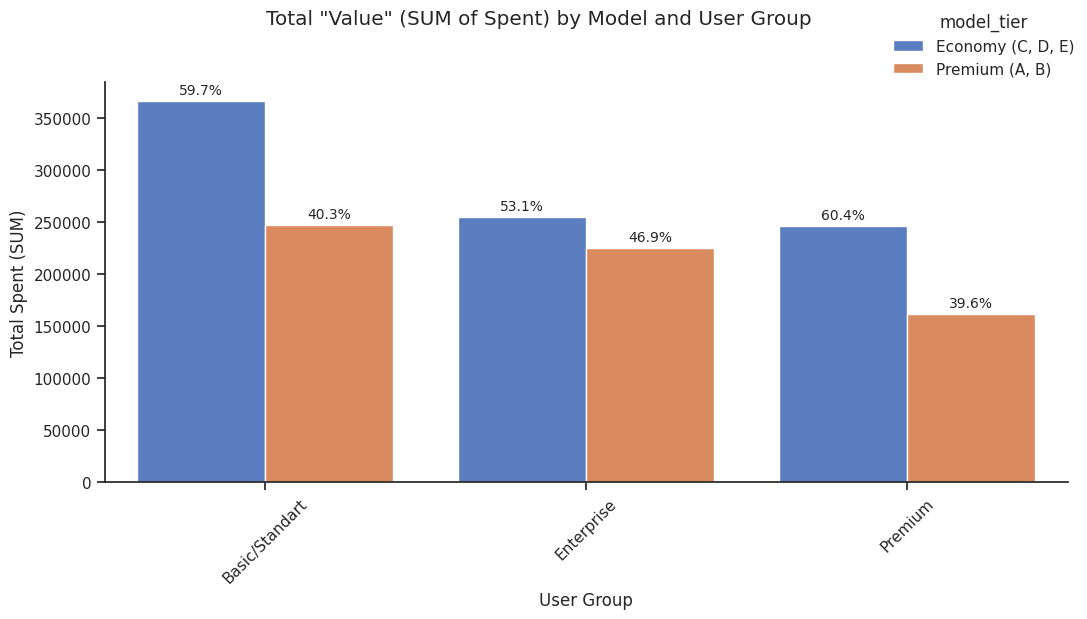

In [41]:
global_user_stats = df.groupby(['uuid', 'license', 'model']).agg(
        total_requests=('requests_cnt', 'sum'),
        total_spent=('spent_amount', 'sum'),
        active_days=('day_id', 'nunique')).reset_index()

uuids_to_highlight = global_user_stats['uuid'].unique()
title_suffix = "All Users"

enterprise_uuids = global_user_stats[global_user_stats['license'].isin(['Enterprise'])]['uuid'].unique()
premium_uuids = global_user_stats[global_user_stats['license'].isin(['Premium'])]['uuid'].unique()
all_uuids_series = global_user_stats['uuid']
basic_standart_uuids_series = all_uuids_series[~all_uuids_series.isin(enterprise_uuids) & ~all_uuids_series.isin(premium_uuids)]

print(np.isin(enterprise_uuids, premium_uuids).any())

economy_models = ['Model_C', 'Model_D', 'Model_E']

global_user_stats['model_tier'] = global_user_stats['model'].apply(
        lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)')

conditions = [global_user_stats['uuid'].isin(enterprise_uuids), 
            global_user_stats['uuid'].isin(premium_uuids),
            global_user_stats['uuid'].isin(basic_standart_uuids_series)]

choices = ['Enterprise', 'Premium', 'Basic/Standart']

global_user_stats['user_group'] = np.select(conditions, choices, default='Basic/Standard')
user_totals_by_group_tier = global_user_stats.groupby(
    ['user_group', 'model_tier', 'uuid']
)['total_spent'].sum().reset_index()

sns.set_theme(style="ticks", palette="pastel")

g = sns.catplot(
    data=user_totals_by_group_tier, 
    kind='bar',
    x='user_group',
    y='total_spent',
    hue='model_tier',
    estimator=sum,
    errorbar=None,
    palette="muted",
    height=6,
    aspect=1.5
)

ax = g.ax

group_totals = user_totals_by_group_tier.groupby('user_group')['total_spent'].sum()
group_labels = [tick.get_text() for tick in ax.get_xticklabels()]

patches = ax.patches

n_groups = len(group_labels)


for i, p in enumerate(patches):
    height = p.get_height()
    group_name = group_labels[i % n_groups]
    group_total = group_totals[group_name]

    if group_total > 0:
        percentage = (height / group_total) * 100
        label = f"{percentage:.1f}%"
        
    x = p.get_x() + p.get_width() / 2
    y = height + (ax.get_ylim()[1] * 0.01)
    
    if percentage > 0:
        ax.text(x, y, label, ha='center', va='bottom', fontsize=10)

sns.move_legend(g, "upper right")

g.set_axis_labels("User Group", "Total Spent (SUM)")
g.fig.suptitle('Total "Value" (SUM of Spent) by Model and User Group', y=1.03)
g.ax.tick_params(axis='x', labelrotation=45)

plt.tight_layout()
plt.show()

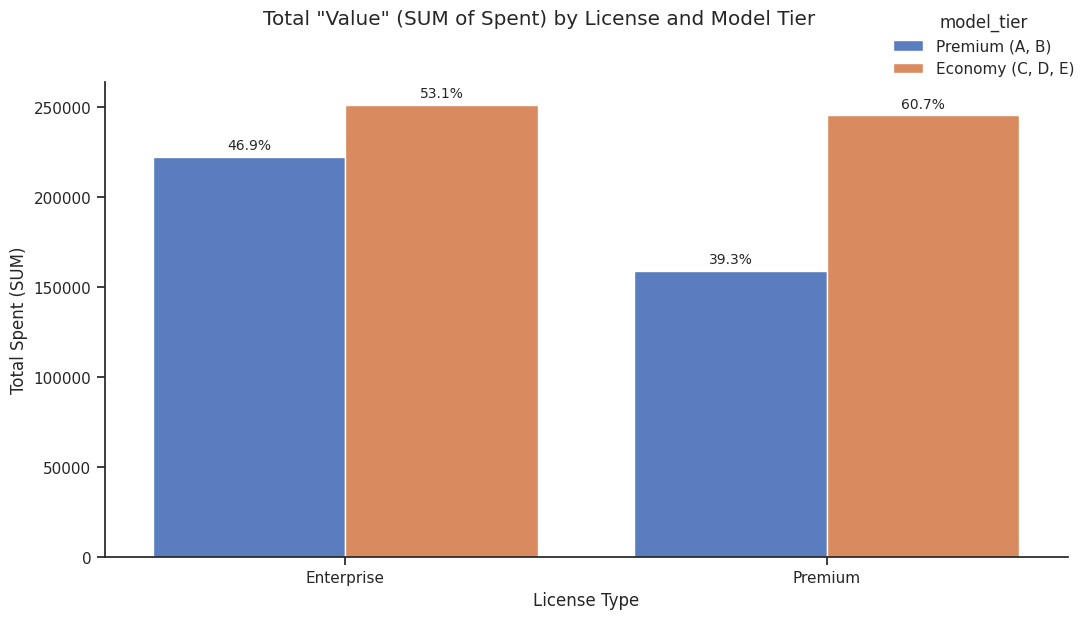

In [44]:
global_user_stats = df.groupby(['license', 'model']).agg(
        total_requests=('requests_cnt', 'sum'),
        total_spent=('spent_amount', 'sum'),
        active_days=('day_id', 'nunique')).reset_index()

economy_models = ['Model_C', 'Model_D', 'Model_E']
global_user_stats['model_tier'] = global_user_stats['model'].apply(
        lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)')


licenses_to_show = ['Enterprise', 'Premium']
plot_data = global_user_stats[global_user_stats['license'].isin(licenses_to_show)]


sns.set_theme(style="ticks", palette="pastel")

g = sns.catplot(
    data=plot_data,
    kind='bar',
    x='license',
    y='total_spent',
    hue='model_tier',
    estimator=sum,
    errorbar=None,
    palette="muted",
    height=6,
    aspect=1.5
)

ax = g.ax

group_totals = plot_data.groupby('license')['total_spent'].sum()
group_labels = [tick.get_text() for tick in ax.get_xticklabels()]
patches = ax.patches
n_groups = len(group_labels)

for i, p in enumerate(patches):
    height = p.get_height()
    
    group_name = group_labels[i % n_groups] 
    group_total = group_totals[group_name]

    if group_total > 0:
        percentage = (height / group_total) * 100
        label = f"{percentage:.1f}%"
    else:
        label = "0.0%"
        
    x = p.get_x() + p.get_width() / 2
    y = height + (ax.get_ylim()[1] * 0.01)

    if percentage > 0:
        ax.text(x, y, label, ha='center', va='bottom', fontsize=10)

sns.move_legend(g, "upper right")

g.set_axis_labels("License Type", "Total Spent (SUM)")
g.fig.suptitle('Total "Value" (SUM of Spent) by License and Model Tier', y=1.03)
g.ax.tick_params(axis='x', labelrotation=0)

plt.tight_layout()
plt.show()

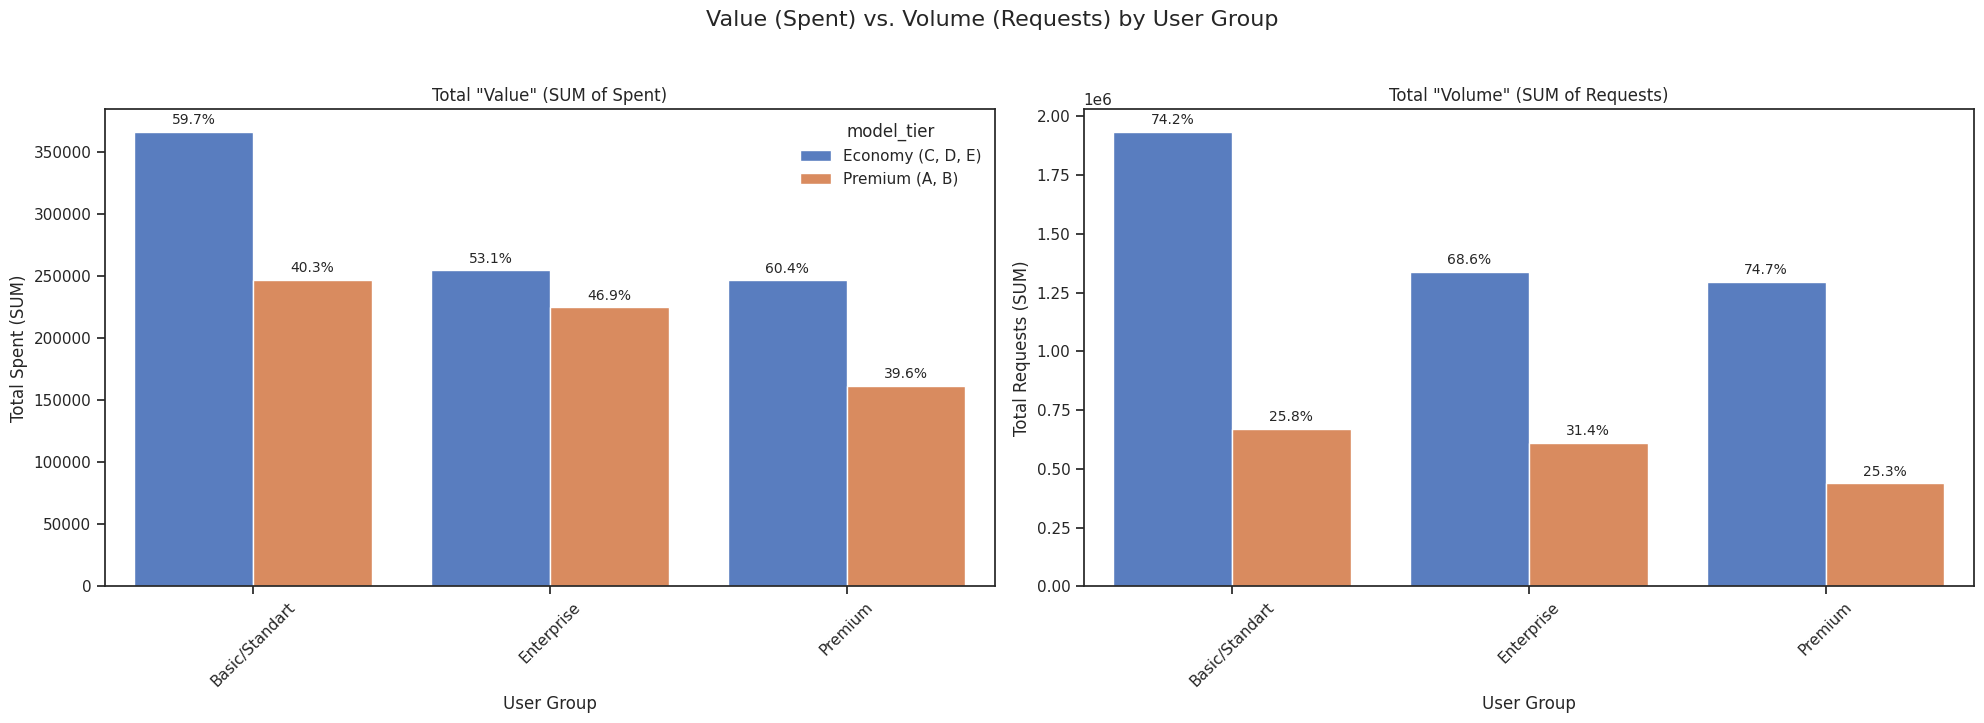

In [46]:

global_user_stats = df.groupby(['uuid', 'license', 'model']).agg(
        total_requests=('requests_cnt', 'sum'),
        total_spent=('spent_amount', 'sum'),
        active_days=('day_id', 'nunique')).reset_index()

uuids_to_highlight = global_user_stats['uuid'].unique()
title_suffix = "All Users"
enterprise_uuids = global_user_stats[global_user_stats['license'].isin(['Enterprise'])]['uuid'].unique()
premium_uuids = global_user_stats[global_user_stats['license'].isin(['Premium'])]['uuid'].unique()
all_uuids_series = global_user_stats['uuid']
basic_standart_uuids_series = all_uuids_series[~all_uuids_series.isin(enterprise_uuids) & ~all_uuids_series.isin(premium_uuids)]

economy_models = ['Model_C', 'Model_D', 'Model_E']
global_user_stats['model_tier'] = global_user_stats['model'].apply(
        lambda x: 'Economy (C, D, E)' if x in economy_models else 'Premium (A, B)')

conditions = [global_user_stats['uuid'].isin(enterprise_uuids), 
            global_user_stats['uuid'].isin(premium_uuids),
            global_user_stats['uuid'].isin(basic_standart_uuids_series)]
choices = ['Enterprise', 'Premium', 'Basic/Standart']
global_user_stats['user_group'] = np.select(conditions, choices, default='Basic/Standard')

user_totals_by_group_tier = global_user_stats.groupby(
    ['user_group', 'model_tier', 'uuid']
)['total_spent'].sum().reset_index()

user_totals_requests = global_user_stats.groupby(
    ['user_group', 'model_tier', 'uuid']
)['total_requests'].sum().reset_index()

sns.set_theme(style="ticks", palette="pastel")
fig, axes = plt.subplots(1, 2, figsize=(20, 7))

ax1 = axes[0]
sns.barplot(
    data=user_totals_by_group_tier, 
    x='user_group',
    y='total_spent',
    hue='model_tier',
    estimator=sum,
    errorbar=None,
    palette="muted",
    ax=ax1
)

group_totals = user_totals_by_group_tier.groupby('user_group')['total_spent'].sum()
group_labels = [tick.get_text() for tick in ax1.get_xticklabels()]
patches = ax1.patches
n_groups = len(group_labels)

for i, p in enumerate(patches):
    height = p.get_height()
    group_name = group_labels[i % n_groups]
    group_total = group_totals[group_name]

    if group_total > 0:
        percentage = (height / group_total) * 100
        label = f"{percentage:.1f}%"
        if percentage > 0:
            x = p.get_x() + p.get_width() / 2
            y = height + (ax1.get_ylim()[1] * 0.01)
            ax1.text(x, y, label, ha='center', va='bottom', fontsize=10)

ax1.set_title('Total "Value" (SUM of Spent)')
ax1.set_xlabel("User Group")
ax1.set_ylabel("Total Spent (SUM)")
ax1.tick_params(axis='x', labelrotation=45)
sns.move_legend(ax1, "upper right")

ax2 = axes[1]
sns.barplot(
    data=user_totals_requests,
    x='user_group',
    y='total_requests',
    hue='model_tier',
    estimator=sum,
    errorbar=None,
    palette="muted",
    ax=ax2
)

group_totals_req = user_totals_requests.groupby('user_group')['total_requests'].sum()
group_labels_req = [tick.get_text() for tick in ax2.get_xticklabels()]
patches_req = ax2.patches
n_groups_req = len(group_labels_req)

for i, p in enumerate(patches_req):
    height = p.get_height()
    group_name = group_labels_req[i % n_groups_req]
    group_total = group_totals_req[group_name]

    if group_total > 0:
        percentage = (height / group_total) * 100
        label = f"{percentage:.1f}%"
        if percentage > 0:
            x = p.get_x() + p.get_width() / 2
            y = height + (ax2.get_ylim()[1] * 0.01)
            ax2.text(x, y, label, ha='center', va='bottom', fontsize=10)

ax2.set_title('Total "Volume" (SUM of Requests)')
ax2.set_xlabel("User Group")
ax2.set_ylabel("Total Requests (SUM)")
ax2.tick_params(axis='x', labelrotation=45)
ax2.get_legend().remove()

fig.suptitle('Value (Spent) vs. Volume (Requests) by User Group', fontsize=16, y=1.03)
plt.tight_layout()
plt.show()

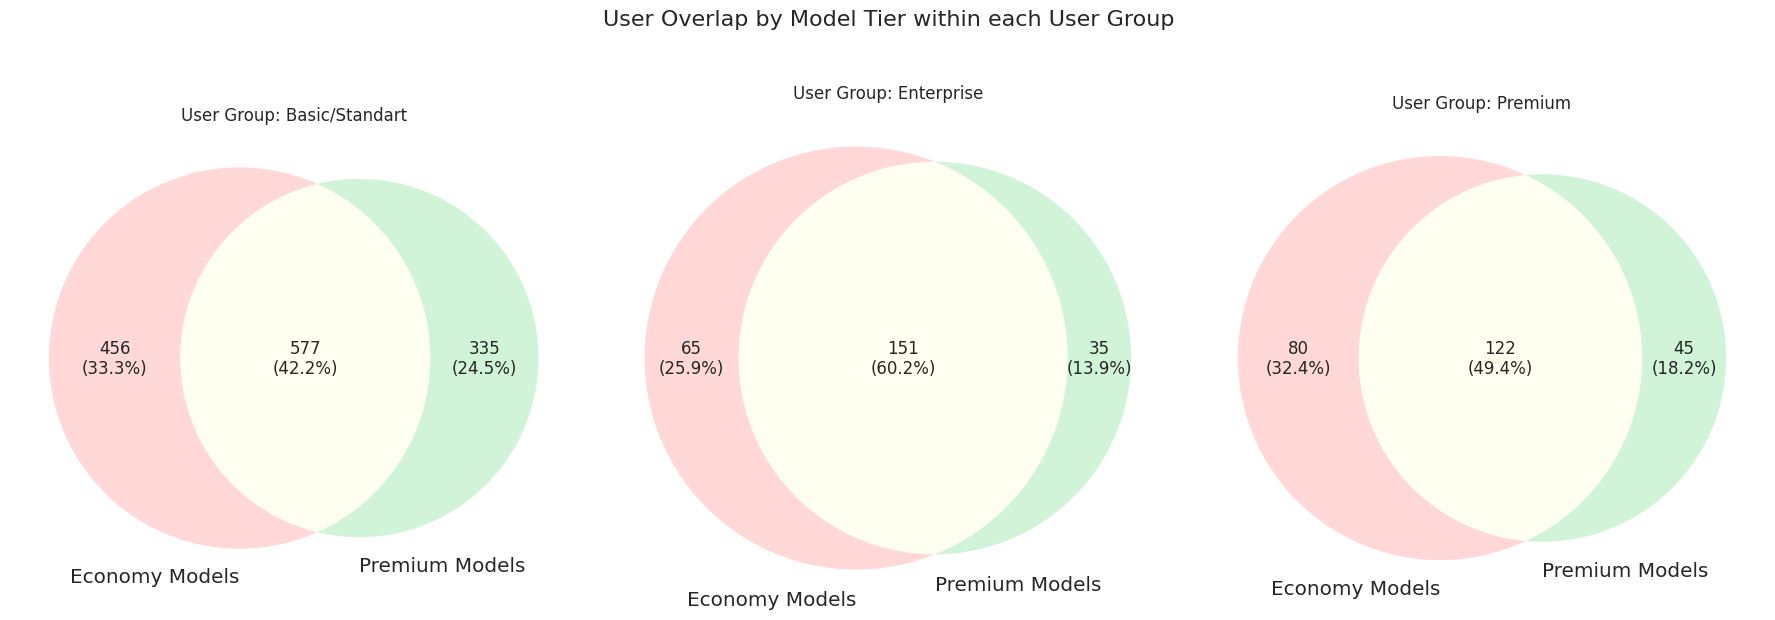

In [42]:
from matplotlib_venn import venn2

custom_order = ['Basic/Standart', 'Enterprise', 'Premium']

fig, axes = plt.subplots(1, n_groups, figsize=(18, 6))

for ax, group in zip(axes, custom_order):
    group_data = global_user_stats[global_user_stats['user_group'] == group]
    
    economy_users = set(
        group_data[group_data['model_tier'] == 'Economy (C, D, E)']['uuid']
    )
    
    premium_users = set(
        group_data[group_data['model_tier'] == 'Premium (A, B)']['uuid']
    )
    
    total_users_in_group = len(economy_users.union(premium_users))
    intersection_count = len(economy_users.intersection(premium_users))
    only_economy_count = len(economy_users) - intersection_count
    only_premium_count = len(premium_users) - intersection_count
    
    
    venn2(
        subsets=(
            only_economy_count, 
            only_premium_count,
            intersection_count                  
        ),
        set_labels=('Economy Models', 'Premium Models'),
        ax=ax,
        subset_label_formatter=(
            lambda x: f"{x}\n({(x/total_users_in_group)*100:.1f}%)"
            if total_users_in_group > 0 else "0"
        )
    )
    
    ax.set_title(f"User Group: {group}")

fig.suptitle('User Overlap by Model Tier within each User Group', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

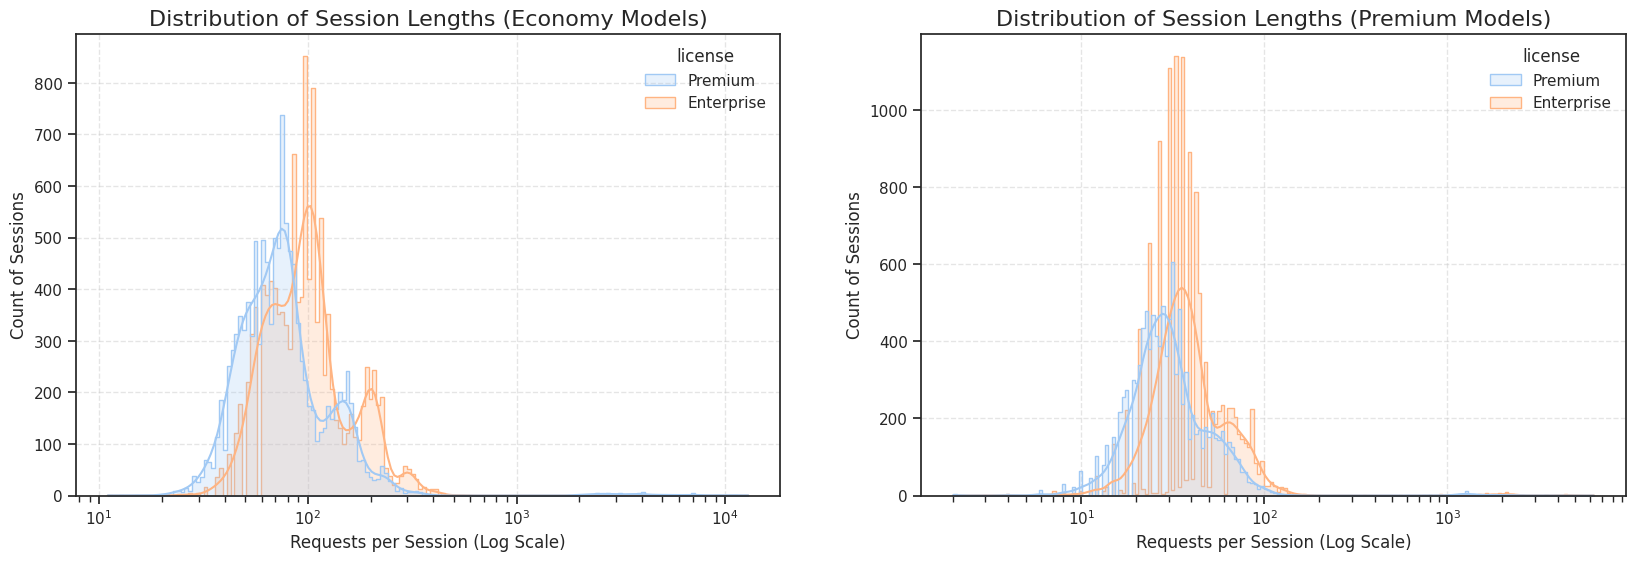

In [58]:

fig, ax = plt.subplots(1, 2, figsize=(20, 6))

data0 = target_licenses_df[target_licenses_df['model_tier'] == 'Economy-Cost (C, D, E)']
data1 = target_licenses_df[target_licenses_df['model_tier'] == 'Premium-Cost (A, B)']

ax1 = ax[0]
sns.histplot(
    data=data0,
    x='requests_cnt',
    hue='license',
    kde=True,
    log_scale=True,
    element='step',
    common_norm=False,
    ax=ax1
)
ax1.set_title('Distribution of Session Lengths (Economy Models)', fontsize=16)
ax1.set_xlabel('Requests per Session (Log Scale)', fontsize=12)
ax1.set_ylabel('Count of Sessions', fontsize=12)
ax1.grid(True, which='major', linestyle='--', alpha=0.5)

ax2 = ax[1]
sns.histplot(
    data=data1,
    x='requests_cnt',
    hue='license',
    kde=True,
    log_scale=True,
    element='step',
    common_norm=False,
    ax=ax2
)
ax2.set_title('Distribution of Session Lengths (Premium Models)', fontsize=16)
ax2.set_xlabel('Requests per Session (Log Scale)', fontsize=12)
ax2.set_ylabel('Count of Sessions', fontsize=12)
ax2.grid(True, which='major', linestyle='--', alpha=0.5)

plt.show()


Building new 'Spent Amount' violin plots...
Saved violin_spent_honest.png
Building new 'Requests Count' violin plots...
Saved violin_requests_honest.png


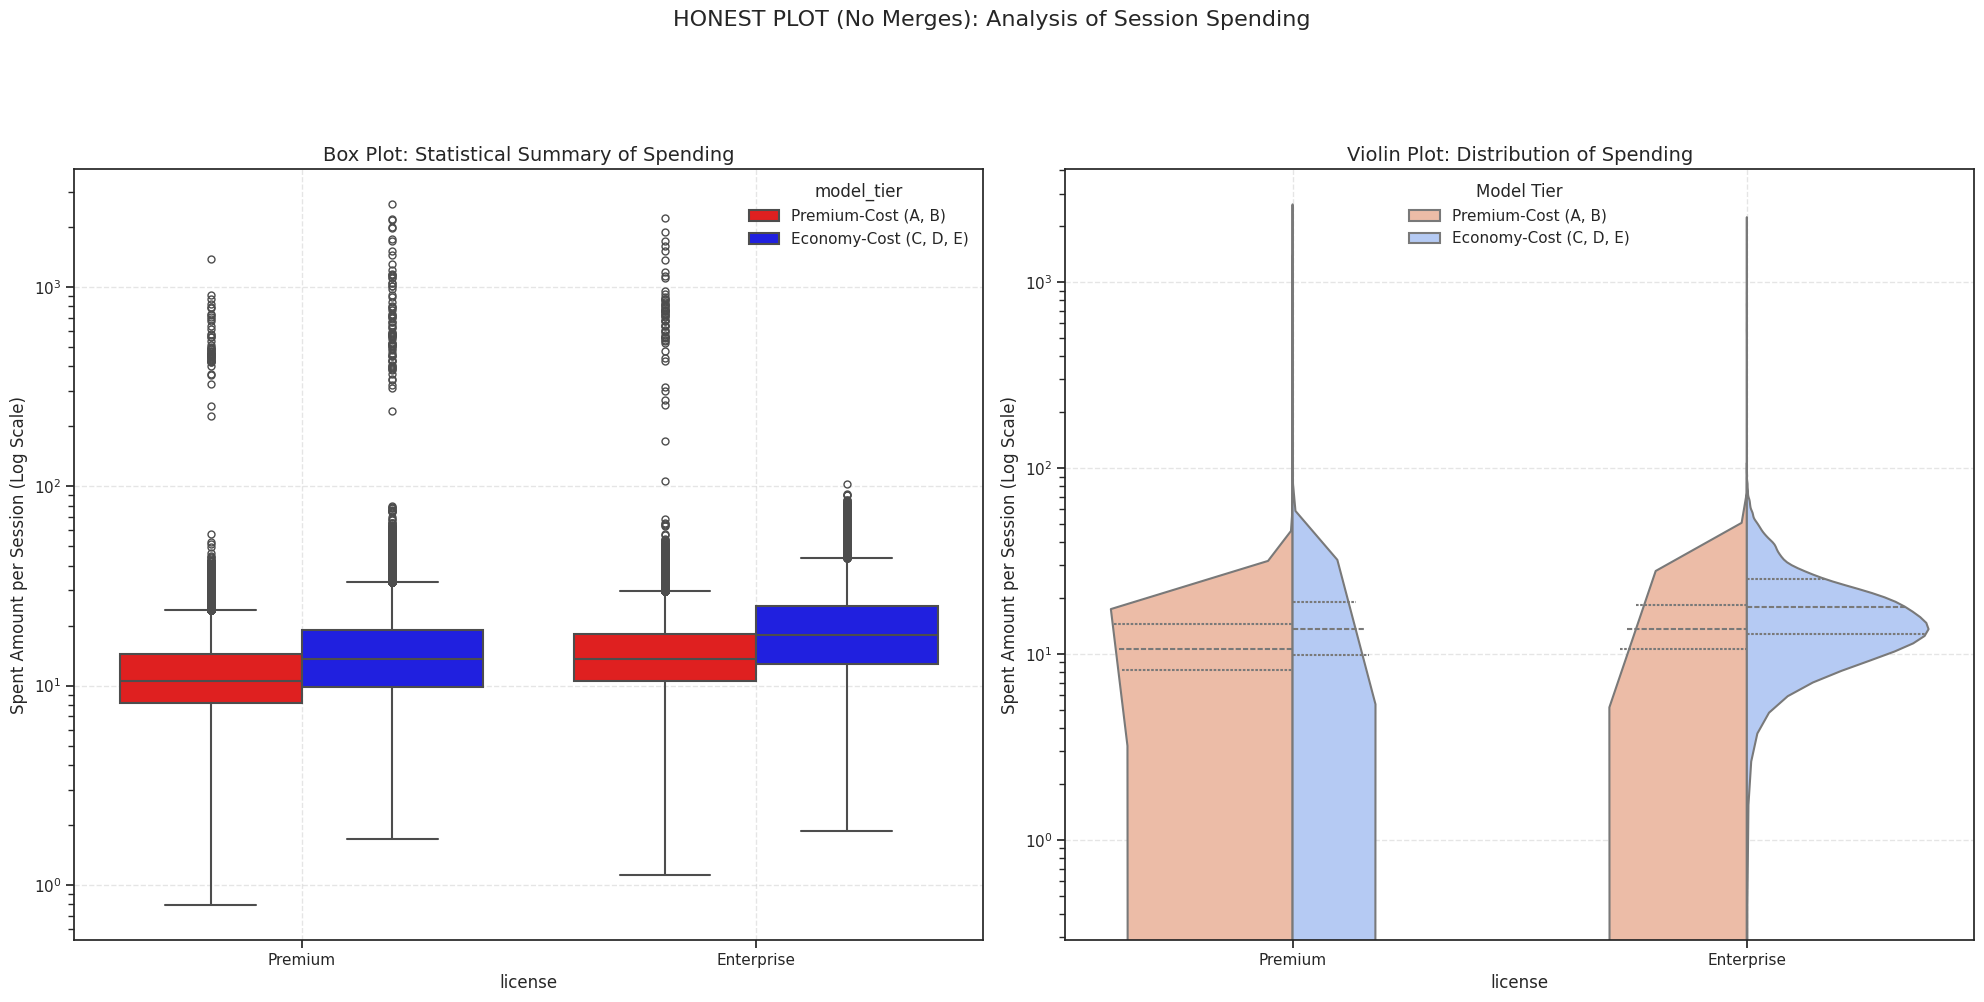

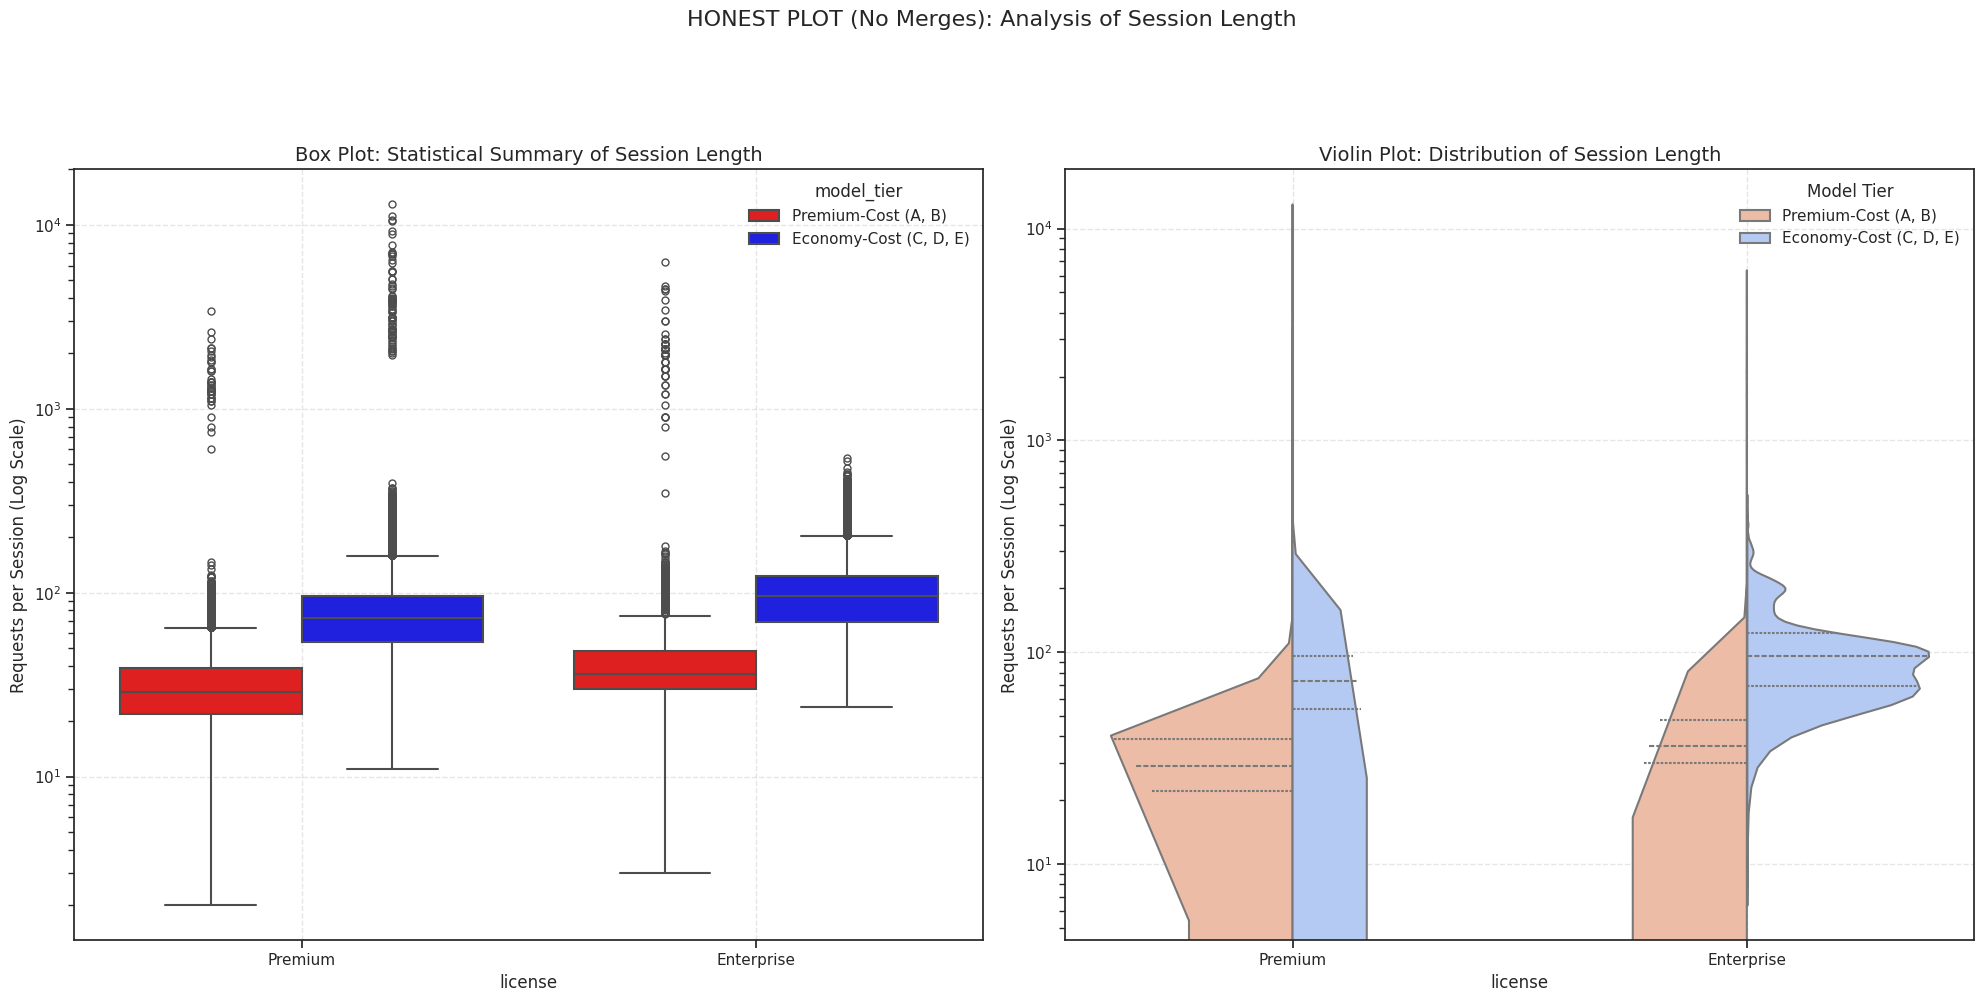

In [ ]:
df_honest = df[df['license'].isin(['Enterprise', 'Premium'])].copy()

premium_models_list = ['Model_A', 'Model_B']
df_honest['model_tier'] = df_honest['model'].apply(
    lambda x: 'Premium-Cost (A, B)' if x in premium_models_list else 'Economy-Cost (C, D, E)'
)

print("Building new 'Spent Amount' violin plots...")
fig_spent, axes_spent = plt.subplots(1, 2, figsize=(20, 10))
fig_spent.suptitle('HONEST PLOT (No Merges): Analysis of Session Spending', fontsize=16, y=1.03)

# 3.1. Box Plot (spent_amount)
ax1_spent = axes_spent[0]
sns.boxplot(
    data=df_honest,
    x='license',
    y='spent_amount',
    hue='model_tier',
    palette={'Premium-Cost (A, B)': '#FF0000', 'Economy-Cost (C, D, E)': '#0000FF'},
    linewidth=1.5,
    fliersize=5,
    ax=ax1_spent
)
ax1_spent.set_title("Box Plot: Statistical Summary of Spending", fontsize=14)
ax1_spent.set_ylabel("Spent Amount per Session (Log Scale)", fontsize=12)
ax1_spent.set_yscale('log')
ax1_spent.grid(True, which='major', linestyle='--', alpha=0.5)

# 3.2. Violin Plot (spent_amount)
ax2_spent = axes_spent[1]
sns.violinplot(
    data=df_honest,
    x='license',
    y='spent_amount',
    hue='model_tier',
    split=True,
    inner='quartile',
    palette='coolwarm_r',
    linewidth=1.5,
    ax=ax2_spent
)
ax2_spent.set_title("Violin Plot: Distribution of Spending", fontsize=14)
ax2_spent.set_ylabel("Spent Amount per Session (Log Scale)", fontsize=12)
ax2_spent.set_yscale('log')
handles_spent, labels_spent = ax2_spent.get_legend_handles_labels()
ax2_spent.legend(handles_spent[0:2], labels_spent[0:2], title='Model Tier')
ax2_spent.grid(True, which='major', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
print("Saved violin_spent_honest.png")


print("Building new 'Requests Count' violin plots...")
fig_req, axes_req = plt.subplots(1, 2, figsize=(20, 10))
fig_req.suptitle('HONEST PLOT (No Merges): Analysis of Session Length', fontsize=16, y=1.03)

# 4.1. Box Plot (requests_cnt)
ax1_req = axes_req[0]
sns.boxplot(
    data=df_honest,
    x='license',
    y='requests_cnt',
    hue='model_tier',
    palette={'Premium-Cost (A, B)': '#FF0000', 'Economy-Cost (C, D, E)': '#0000FF'},
    linewidth=1.5,
    fliersize=5,
    ax=ax1_req
)
ax1_req.set_title("Box Plot: Statistical Summary of Session Length", fontsize=14)
ax1_req.set_ylabel("Requests per Session (Log Scale)", fontsize=12)
ax1_req.set_yscale('log')
ax1_req.grid(True, which='major', linestyle='--', alpha=0.5)

# 4.2. Violin Plot (requests_cnt)
ax2_req = axes_req[1]
sns.violinplot(
    data=df_honest,
    x='license',
    y='requests_cnt',
    hue='model_tier',
    split=True,
    inner='quartile',
    palette='coolwarm_r',
    linewidth=1.5,
    ax=ax2_req
)
ax2_req.set_title("Violin Plot: Distribution of Session Length", fontsize=14)
ax2_req.set_ylabel("Requests per Session (Log Scale)", fontsize=12)
ax2_req.set_yscale('log')
handles_req, labels_req = ax2_req.get_legend_handles_labels()
ax2_req.legend(handles_req[0:2], labels_req[0:2], title='Model Tier')
ax2_req.grid(True, which='major', linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
print("Saved violin_requests_honest.png")

In [59]:
user_license_map = df.groupby('uuid')['license'].agg(
    lambda x: x.mode()[0] if not x.empty else 'Unknown'
).reset_index()

user_stats_with_license = user_stats.merge(user_license_map, on='uuid')

pareto_df = user_stats_with_license.sort_values(by='total_spent', ascending=False)

total_spent_all = pareto_df['total_spent'].sum()
total_requests_all = pareto_df['total_requests'].sum()
n_users = len(pareto_df)

pareto_df['cum_spent_pct'] = 100 * pareto_df['total_spent'].cumsum() / total_spent_all
pareto_df['cum_requests_pct'] = 100 * pareto_df['total_requests'].cumsum() / total_requests_all

idx_1_pct = int(n_users * 0.01)
idx_5_pct = int(n_users * 0.05)
idx_20_pct = int(n_users * 0.20)

cut_1_pct = pareto_df.iloc[idx_1_pct - 1]
cut_5_pct = pareto_df.iloc[idx_5_pct - 1]
cut_20_pct = pareto_df.iloc[idx_20_pct - 1]

def get_dominant_licenses(df_slice):
    return ", ".join(df_slice['license'].value_counts().index[:2].tolist())

lic_top_1 = get_dominant_licenses(pareto_df.iloc[:idx_1_pct])
lic_top_5 = get_dominant_licenses(pareto_df.iloc[:idx_5_pct])
lic_top_20 = get_dominant_licenses(pareto_df.iloc[:idx_20_pct])
lic_bottom_80 = get_dominant_licenses(pareto_df.iloc[idx_20_pct:])

data = {
    'Segment': ['Top 1%', 'Top 5%', 'Top 20%', 'Bottom 80%'],
    'User %': ['1%', '5%', '20%', '80%'],
    'Total Revenue %': [
        cut_1_pct['cum_spent_pct'],
        cut_5_pct['cum_spent_pct'],
        cut_20_pct['cum_spent_pct'],
        100.0 - cut_20_pct['cum_spent_pct']
    ],
    'Total Requests %': [
        cut_1_pct['cum_requests_pct'],
        cut_5_pct['cum_requests_pct'],
        cut_20_pct['cum_requests_pct'],
        100.0 - cut_20_pct['cum_requests_pct']
    ],
    'Dominant Licenses': [lic_top_1, lic_top_5, lic_top_20, lic_bottom_80]
}

final_pareto_table = pd.DataFrame(data).set_index('Segment')

final_pareto_table['Total Revenue %'] = final_pareto_table['Total Revenue %'].map('{:.1f}%'.format)
final_pareto_table['Total Requests %'] = final_pareto_table['Total Requests %'].map('{:.1f}%'.format)

print("--- Value Table 4: Pareto Analysis (Revenue Distribution) ---")
print(final_pareto_table)

--- Value Table 4: Pareto Analysis (Revenue Distribution) ---
           User % Total Revenue % Total Requests %     Dominant Licenses
Segment                                                                 
Top 1%         1%           15.0%            15.4%  Standard, Enterprise
Top 5%         5%           25.9%            28.4%   Enterprise, Premium
Top 20%       20%           55.6%            57.9%   Enterprise, Premium
Bottom 80%    80%           44.4%            42.1%       Basic, Standard


--- Starting Event-Based Analysis (Journey to Enterprise) ---
Count of enterprise cohort - 251
Count of base cohort - 1398
Count of cohort_a_uuids - 17


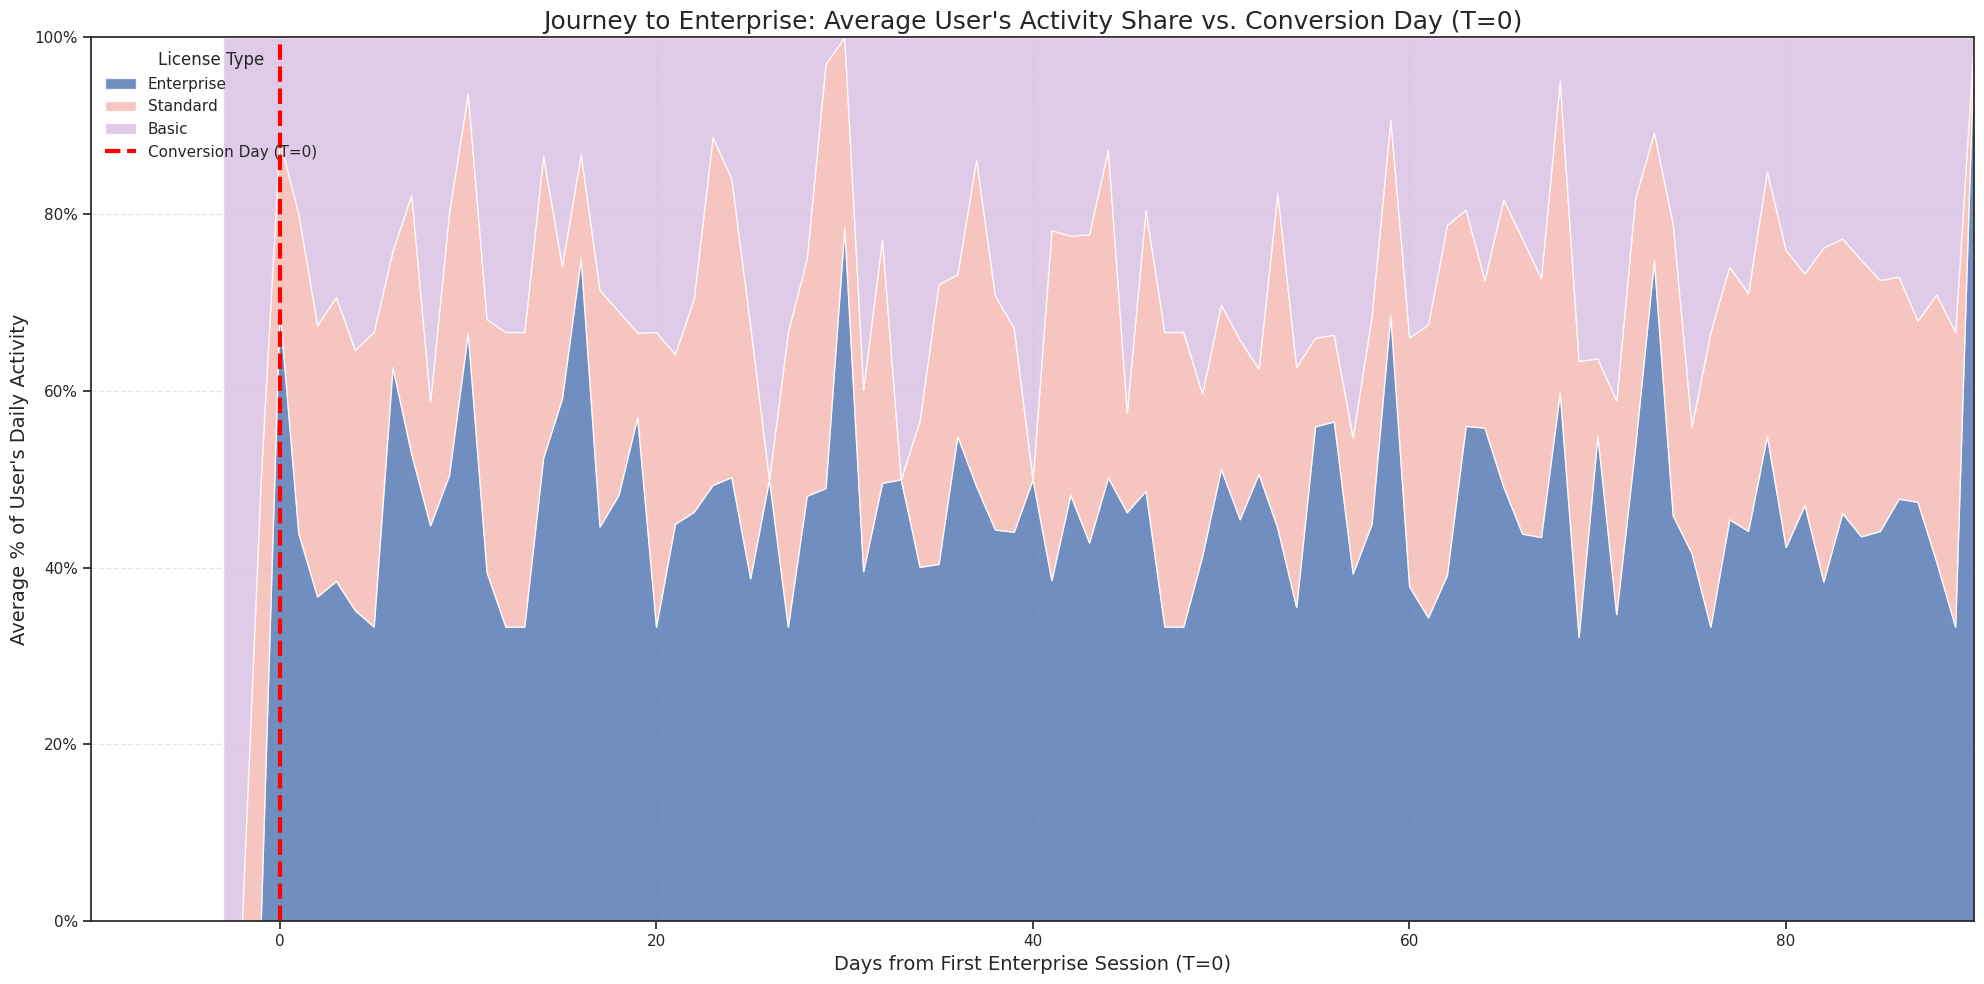


--- Starting Event-Based Analysis (Journey to Premium) ---
Count of premium cohort - 247
Count of base cohort - 1398
Count of cohort_b_uuids - 13


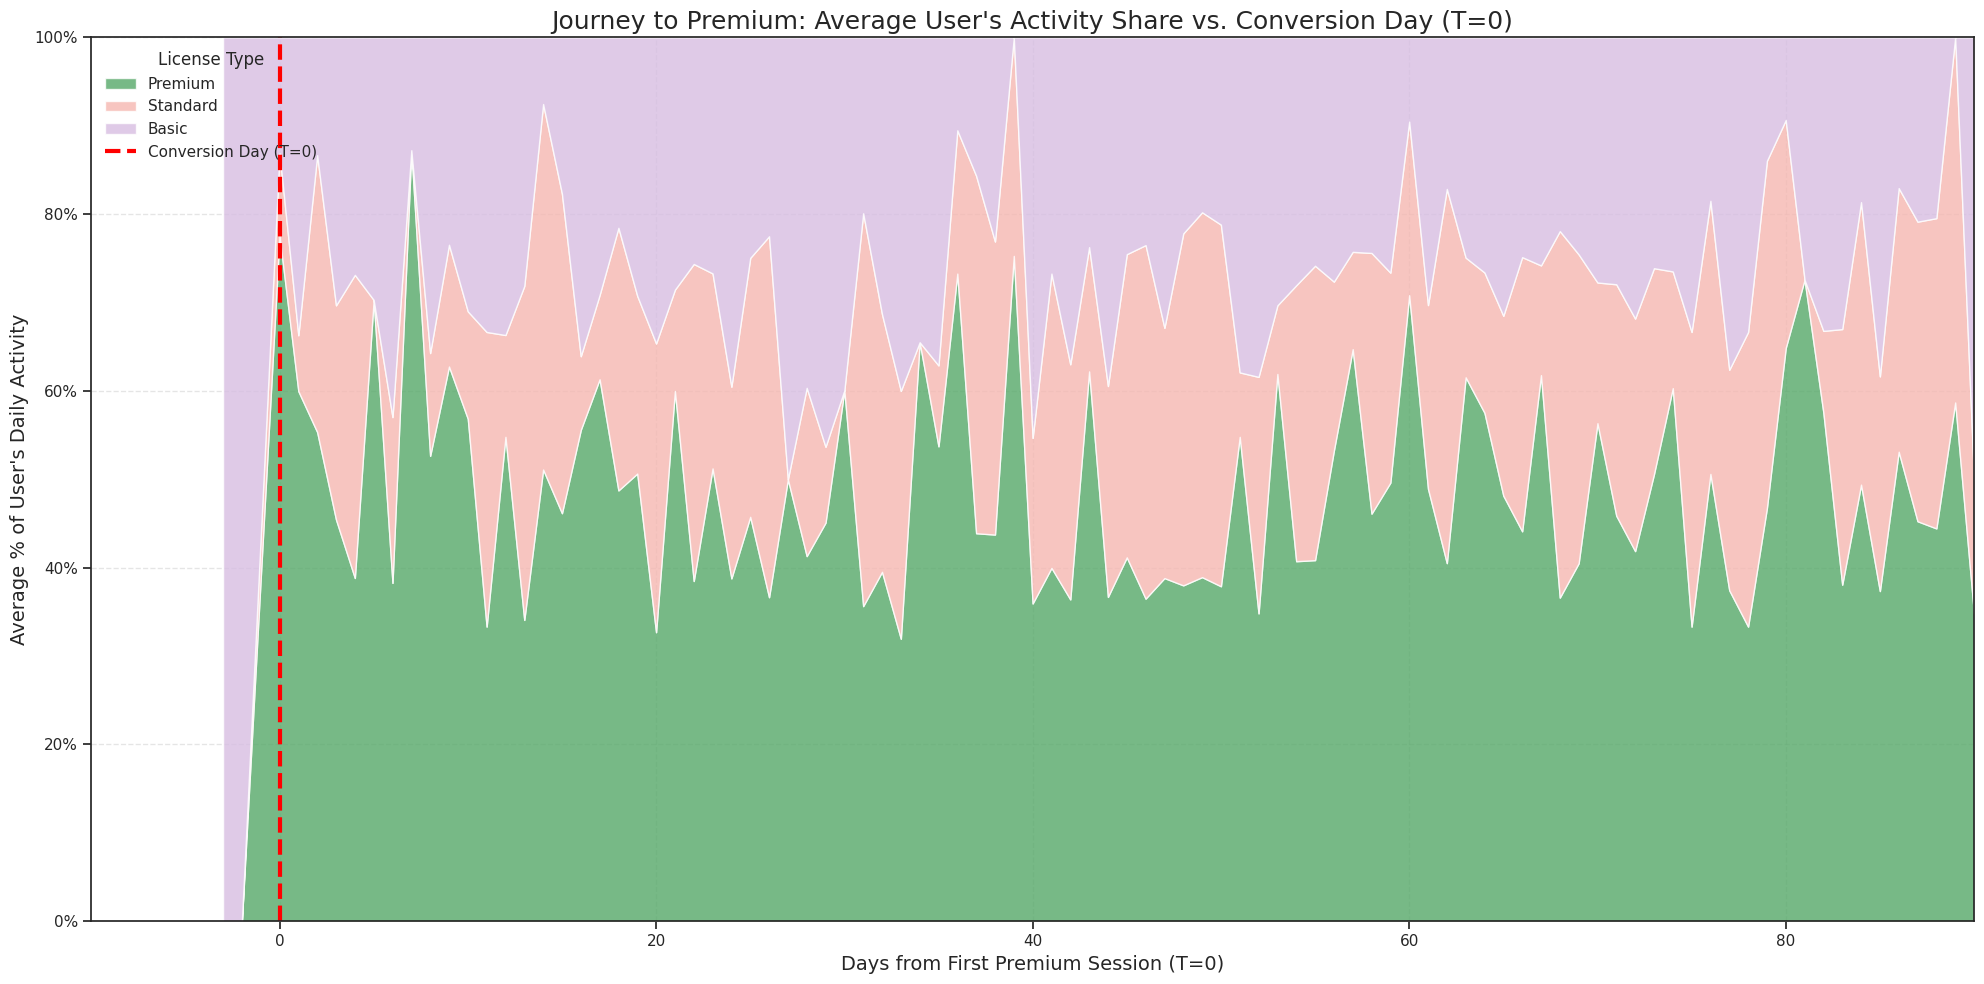

In [ ]:
print("--- Starting Event-Based Analysis (Journey to Enterprise) ---")

enterprise_uuids = set(df[df['license'] == 'Enterprise']['uuid'].unique())
print(f"Count of enterprise cohort - {len(enterprise_uuids)}")
base_uuids = set(df[df['license'].isin(['Basic', 'Standard'])]['uuid'].unique())
print(f"Count of base cohort - {len(base_uuids)}")

cohort_a_uuids = list(enterprise_uuids.intersection(base_uuids))
cohort_df = df[df['uuid'].isin(cohort_a_uuids)].copy()
print(f"Count of cohort_a_uuids - {len(cohort_a_uuids)}")

enterprise_sessions = cohort_df[cohort_df['license'] == 'Enterprise']
conversion_day_map = enterprise_sessions.groupby('uuid')['day_id'].min().reset_index()
conversion_day_map = conversion_day_map.rename(columns={'day_id': 'conversion_day'})

aligned_df = pd.merge(cohort_df, conversion_day_map, on='uuid', how='left')
aligned_df['days_from_conversion'] = (aligned_df['day_id'] - aligned_df['conversion_day']).dt.days

user_daily_total = aligned_df.groupby(['uuid', 'days_from_conversion'])['requests_cnt'].sum().reset_index()
user_daily_total = user_daily_total.rename(columns={'requests_cnt': 'total_user_requests'})

user_license_daily = aligned_df.groupby(['uuid', 'days_from_conversion', 'license'])['requests_cnt'].sum().reset_index()

norm_df = pd.merge(
    user_license_daily,
    user_daily_total,
    on=['uuid', 'days_from_conversion']
)

norm_df['user_activity_share'] = (norm_df['requests_cnt'] / norm_df['total_user_requests']).fillna(0)

final_trend = norm_df.groupby(['days_from_conversion', 'license'])['user_activity_share'].mean().reset_index()

final_pivot = final_trend.pivot_table(
    index='days_from_conversion',
    columns='license',
    values='user_activity_share',
    fill_value=0
)

final_pivot_total = final_pivot.sum(axis=1)
final_percentage = final_pivot.divide(final_pivot_total, axis=0).fillna(0)

final_percentage = final_percentage.loc[-10:90]

license_order = ['Enterprise', 'Standard', 'Basic']
for lic in license_order:
    if lic not in final_percentage.columns:
        final_percentage[lic] = 0
final_percentage = final_percentage[license_order]

colors = ['#4C72B0', '#F5B7B1', '#D7BDE2']

plt.figure(figsize=(20, 10))
plt.stackplot(
    final_percentage.index,
    [final_percentage[col] for col in license_order],
    labels=license_order,
    colors=colors,
    alpha=0.8
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=3, label='Conversion Day (T=0)')
plt.title('Journey to Enterprise: Average User\'s Activity Share vs. Conversion Day (T=0)', fontsize=18)
plt.xlabel(f'Days from First Enterprise Session (T=0)', fontsize=14)
plt.ylabel('Average % of User\'s Daily Activity', fontsize=14)
plt.legend(loc='upper left', title='License Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-10, 90)
plt.ylim(0, 1)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()


print("\n--- Starting Event-Based Analysis (Journey to Premium) ---")

premium_uuids = set(df[df['license'] == 'Premium']['uuid'].unique())
print(f"Count of premium cohort - {len(premium_uuids)}")
base_uuids = set(df[df['license'].isin(['Basic', 'Standard'])]['uuid'].unique())
print(f"Count of base cohort - {len(base_uuids)}")

cohort_b_uuids = list(premium_uuids.intersection(base_uuids))
cohort_df = df[df['uuid'].isin(cohort_b_uuids)].copy()
print(f"Count of cohort_b_uuids - {len(cohort_b_uuids)}")

premium_sessions = cohort_df[cohort_df['license'] == 'Premium']
conversion_day_map = premium_sessions.groupby('uuid')['day_id'].min().reset_index()
conversion_day_map = conversion_day_map.rename(columns={'day_id': 'conversion_day'})

aligned_df = pd.merge(cohort_df, conversion_day_map, on='uuid', how='left')
aligned_df['days_from_conversion'] = (aligned_df['day_id'] - aligned_df['conversion_day']).dt.days

user_daily_total = aligned_df.groupby(['uuid', 'days_from_conversion'])['requests_cnt'].sum().reset_index()
user_daily_total = user_daily_total.rename(columns={'requests_cnt': 'total_user_requests'})

user_license_daily = aligned_df.groupby(['uuid', 'days_from_conversion', 'license'])['requests_cnt'].sum().reset_index()

norm_df = pd.merge(
    user_license_daily,
    user_daily_total,
    on=['uuid', 'days_from_conversion']
)

norm_df['user_activity_share'] = (norm_df['requests_cnt'] / norm_df['total_user_requests']).fillna(0)

final_trend = norm_df.groupby(['days_from_conversion', 'license'])['user_activity_share'].mean().reset_index()

final_pivot = final_trend.pivot_table(
    index='days_from_conversion',
    columns='license',
    values='user_activity_share',
    fill_value=0
)

final_pivot_total = final_pivot.sum(axis=1)
final_percentage = final_pivot.divide(final_pivot_total, axis=0).fillna(0)

final_percentage = final_percentage.loc[-10:90]

license_order = ['Premium', 'Standard', 'Basic']
for lic in license_order:
    if lic not in final_percentage.columns:
        final_percentage[lic] = 0
final_percentage = final_percentage[license_order]

colors = ['#55A868', '#F5B7B1', '#D7BDE2']

plt.figure(figsize=(20, 10))
plt.stackplot(
    final_percentage.index,
    [final_percentage[col] for col in license_order],
    labels=license_order,
    colors=colors,
    alpha=0.8
)

plt.axvline(x=0, color='red', linestyle='--', linewidth=3, label='Conversion Day (T=0)')
plt.title('Journey to Premium: Average User\'s Activity Share vs. Conversion Day (T=0)', fontsize=18)
plt.xlabel(f'Days from First Premium Session (T=0)', fontsize=14)
plt.ylabel('Average % of User\'s Daily Activity', fontsize=14)
plt.legend(loc='upper left', title='License Type')
plt.grid(True, linestyle='--', alpha=0.5)
plt.xlim(-10, 90)
plt.ylim(0, 1)
ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
plt.tight_layout()
plt.show()

In [ ]:
print("--- Starting 7.2: Weekday vs. Weekend Analysis ---")

# 1. First, get the TOTAL daily requests per license
daily_license_requests = df.groupby(['day_id', 'license', 'day_of_week'])['requests_cnt'].sum().reset_index()

# 2. Define day types
weekdays = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
daily_license_requests['day_type'] = daily_license_requests['day_of_week'].apply(
    lambda x: 'Weekday' if x in weekdays else 'Weekend'
)

# 3. Calculate the AVERAGE daily requests for each group
avg_daily_activity = daily_license_requests.groupby(['license', 'day_type'])['requests_cnt'].mean().reset_index()

# 4. Pivot the data to create the comparison table
activity_pivot = avg_daily_activity.pivot_table(
    index='license',
    columns='day_type',
    values='requests_cnt'
).round(1)

# 5. Calculate the Concentration Ratio
activity_pivot['Concentration_Ratio (Wd/We)'] = (activity_pivot['Weekday'] / activity_pivot['Weekend']).round(2)

# 6. Clean up for presentation
activity_pivot.columns.name = 'Analysis'
activity_pivot = activity_pivot[['Weekday', 'Weekend', 'Concentration_Ratio (Wd/We)']]
activity_pivot = activity_pivot.reindex(['Enterprise', 'Premium', 'Standard', 'Basic'])

print("Analysis: Weekday vs Weekend Activity by License Type")
# This will print the DataFrame directly without needing 'tabulate'
print(activity_pivot)

--- Starting 7.2: Weekday vs. Weekend Analysis ---
Analysis: Weekday vs Weekend Activity by License Type
Analysis    Weekday  Weekend  Concentration_Ratio (Wd/We)
license                                                  
Enterprise  27051.4   6186.5                         4.37
Premium     24292.3   5208.5                         4.66
Standard    21152.8   7185.1                         2.94
Basic       14498.5   5026.8                         2.88


--- Plotting 7.2: Combined Weekday/Weekend Analysis ---


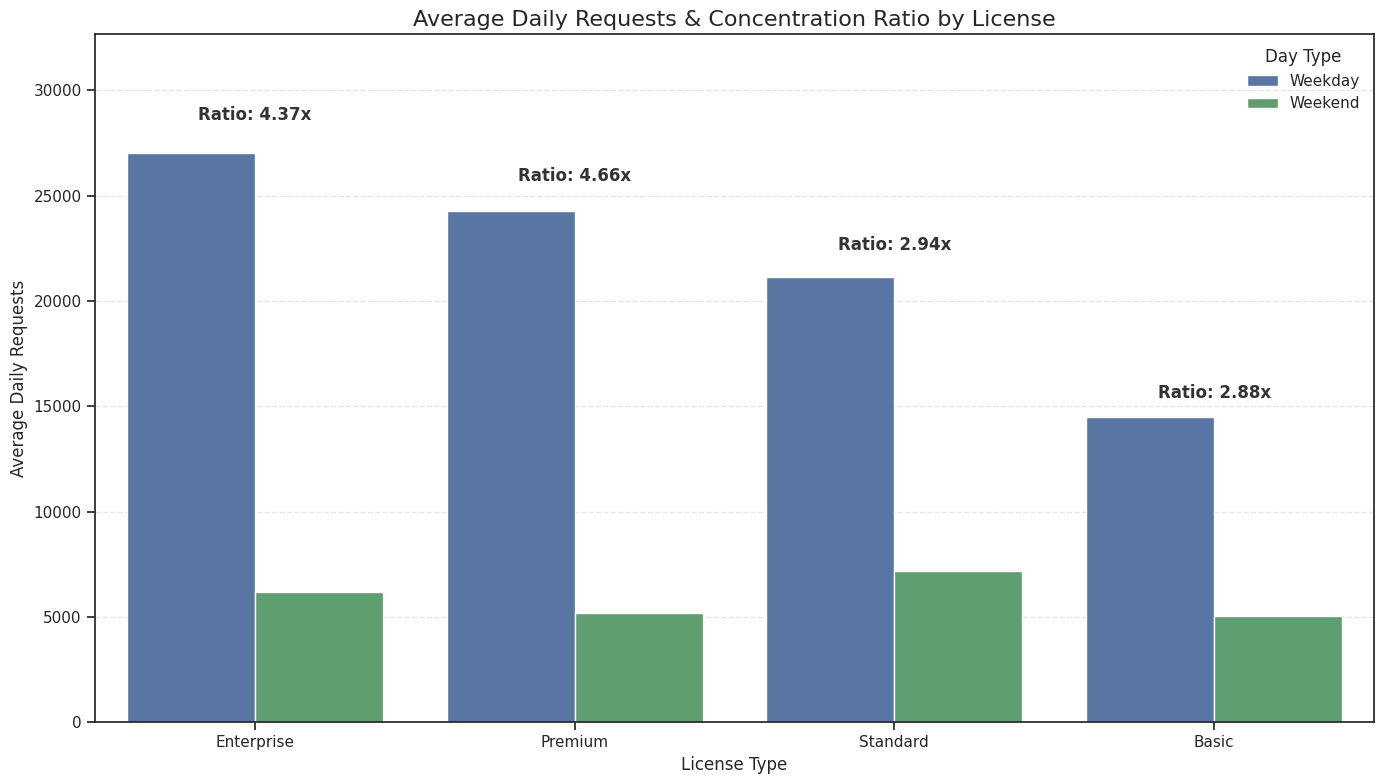

In [ ]:
print("--- Plotting 7.2: Combined Weekday/Weekend Analysis ---")

plot_df = activity_pivot.reset_index().melt(
    id_vars='license',
    value_vars=['Weekday', 'Weekend'],
    var_name='Day Type',
    value_name='Average Daily Requests'
)

license_order = ['Enterprise', 'Premium', 'Standard', 'Basic']
plot_df = plot_df[plot_df['license'].isin(license_order)]

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=plot_df,
    x='license',
    y='Average Daily Requests',
    hue='Day Type',
    palette={'Weekday': '#4C72B0', 'Weekend': '#55A868'},
    order=license_order
)

plt.title('Average Daily Requests & Concentration Ratio by License', fontsize=16)
plt.ylabel('Average Daily Requests', fontsize=12)
plt.xlabel('License Type', fontsize=12)
plt.legend(title='Day Type', loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5, axis='y')

current_y_limit = ax.get_ylim()[1]
ax.set_ylim(top=current_y_limit * 1.15) 

max_heights = plot_df.groupby('license')['Average Daily Requests'].max().reindex(license_order)
ratios = activity_pivot['Concentration_Ratio (Wd/We)'].reindex(license_order)

x_coords_map = {label.get_text(): i for i, label in enumerate(ax.get_xticklabels())}

for license_name in license_order:
    if license_name not in x_coords_map:
        continue
        
    x_pos = x_coords_map[license_name]
    height = max_heights.loc[license_name]
    ratio = ratios.loc[license_name]

    if pd.notna(height) and pd.notna(ratio):
        ax.text(
            x_pos,
            height * 1.05,
            f"Ratio: {ratio:.2f}x", 
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold',
            color='#333333'
        )

plt.tight_layout()
plt.show()

--- 8.1. Monthly Trend Summary ---

--- Monthly Spend & Share: LICENSE ---


license,Spend_Basic,Spend_Enterprise,Spend_Premium,Spend_Standard,Share_Basic,Share_Enterprise,Share_Premium,Share_Standard
month_name,,,,,,,,
March,70054.60,145040.03,96724.34,91654.21,0.173629,0.359479,0.239729,0.227163
April,84432.45,149673.57,135529.54,125003.26,0.170695,0.302592,0.273997,0.252716
May,101766.81,178524.17,171717.62,150792.74,0.168823,0.296158,0.284866,0.250153



--- Monthly Spend & Share: MODEL ---


model,Spend_Model_A,Spend_Model_B,Spend_Model_C,Spend_Model_D,Spend_Model_E,Share_Model_A,Share_Model_B,Share_Model_C,Share_Model_D,Share_Model_E
month_name,,,,,,,,,,
March,89295.04,70830.99,92491.17,104891.45,45964.53,0.221316,0.175553,0.229237,0.259971,0.113922
April,123642.10,87053.16,120114.33,119906.01,43923.22,0.249964,0.175993,0.242832,0.242411,0.088799
May,152139.94,110281.93,154016.24,136809.77,49553.46,0.252388,0.182949,0.255501,0.226957,0.082205



--- Monthly Spend & Share: FEATURE ---


feature,Spend_Feature_1,Spend_Feature_2,Spend_Feature_3,Spend_Feature_4,Spend_Feature_5,Share_Feature_1,Share_Feature_2,Share_Feature_3,Share_Feature_4,Share_Feature_5
month_name,,,,,,,,,,
March,168997.79,115137.26,78455.05,22741.59,18141.49,0.418858,0.285365,0.194449,0.056365,0.044963
April,200414.70,146488.79,93882.53,30715.41,23137.39,0.405174,0.296153,0.189800,0.062097,0.046776
May,241096.67,171217.46,119626.93,41895.19,28965.09,0.399960,0.284036,0.198452,0.069501,0.048051



--- 8.2. Plotting 3x2 Weekly Trend Canvas (All Line Plots) ---
Saved 3x2 canvas to weekly_trends_canvas_3x2_all_lines.png


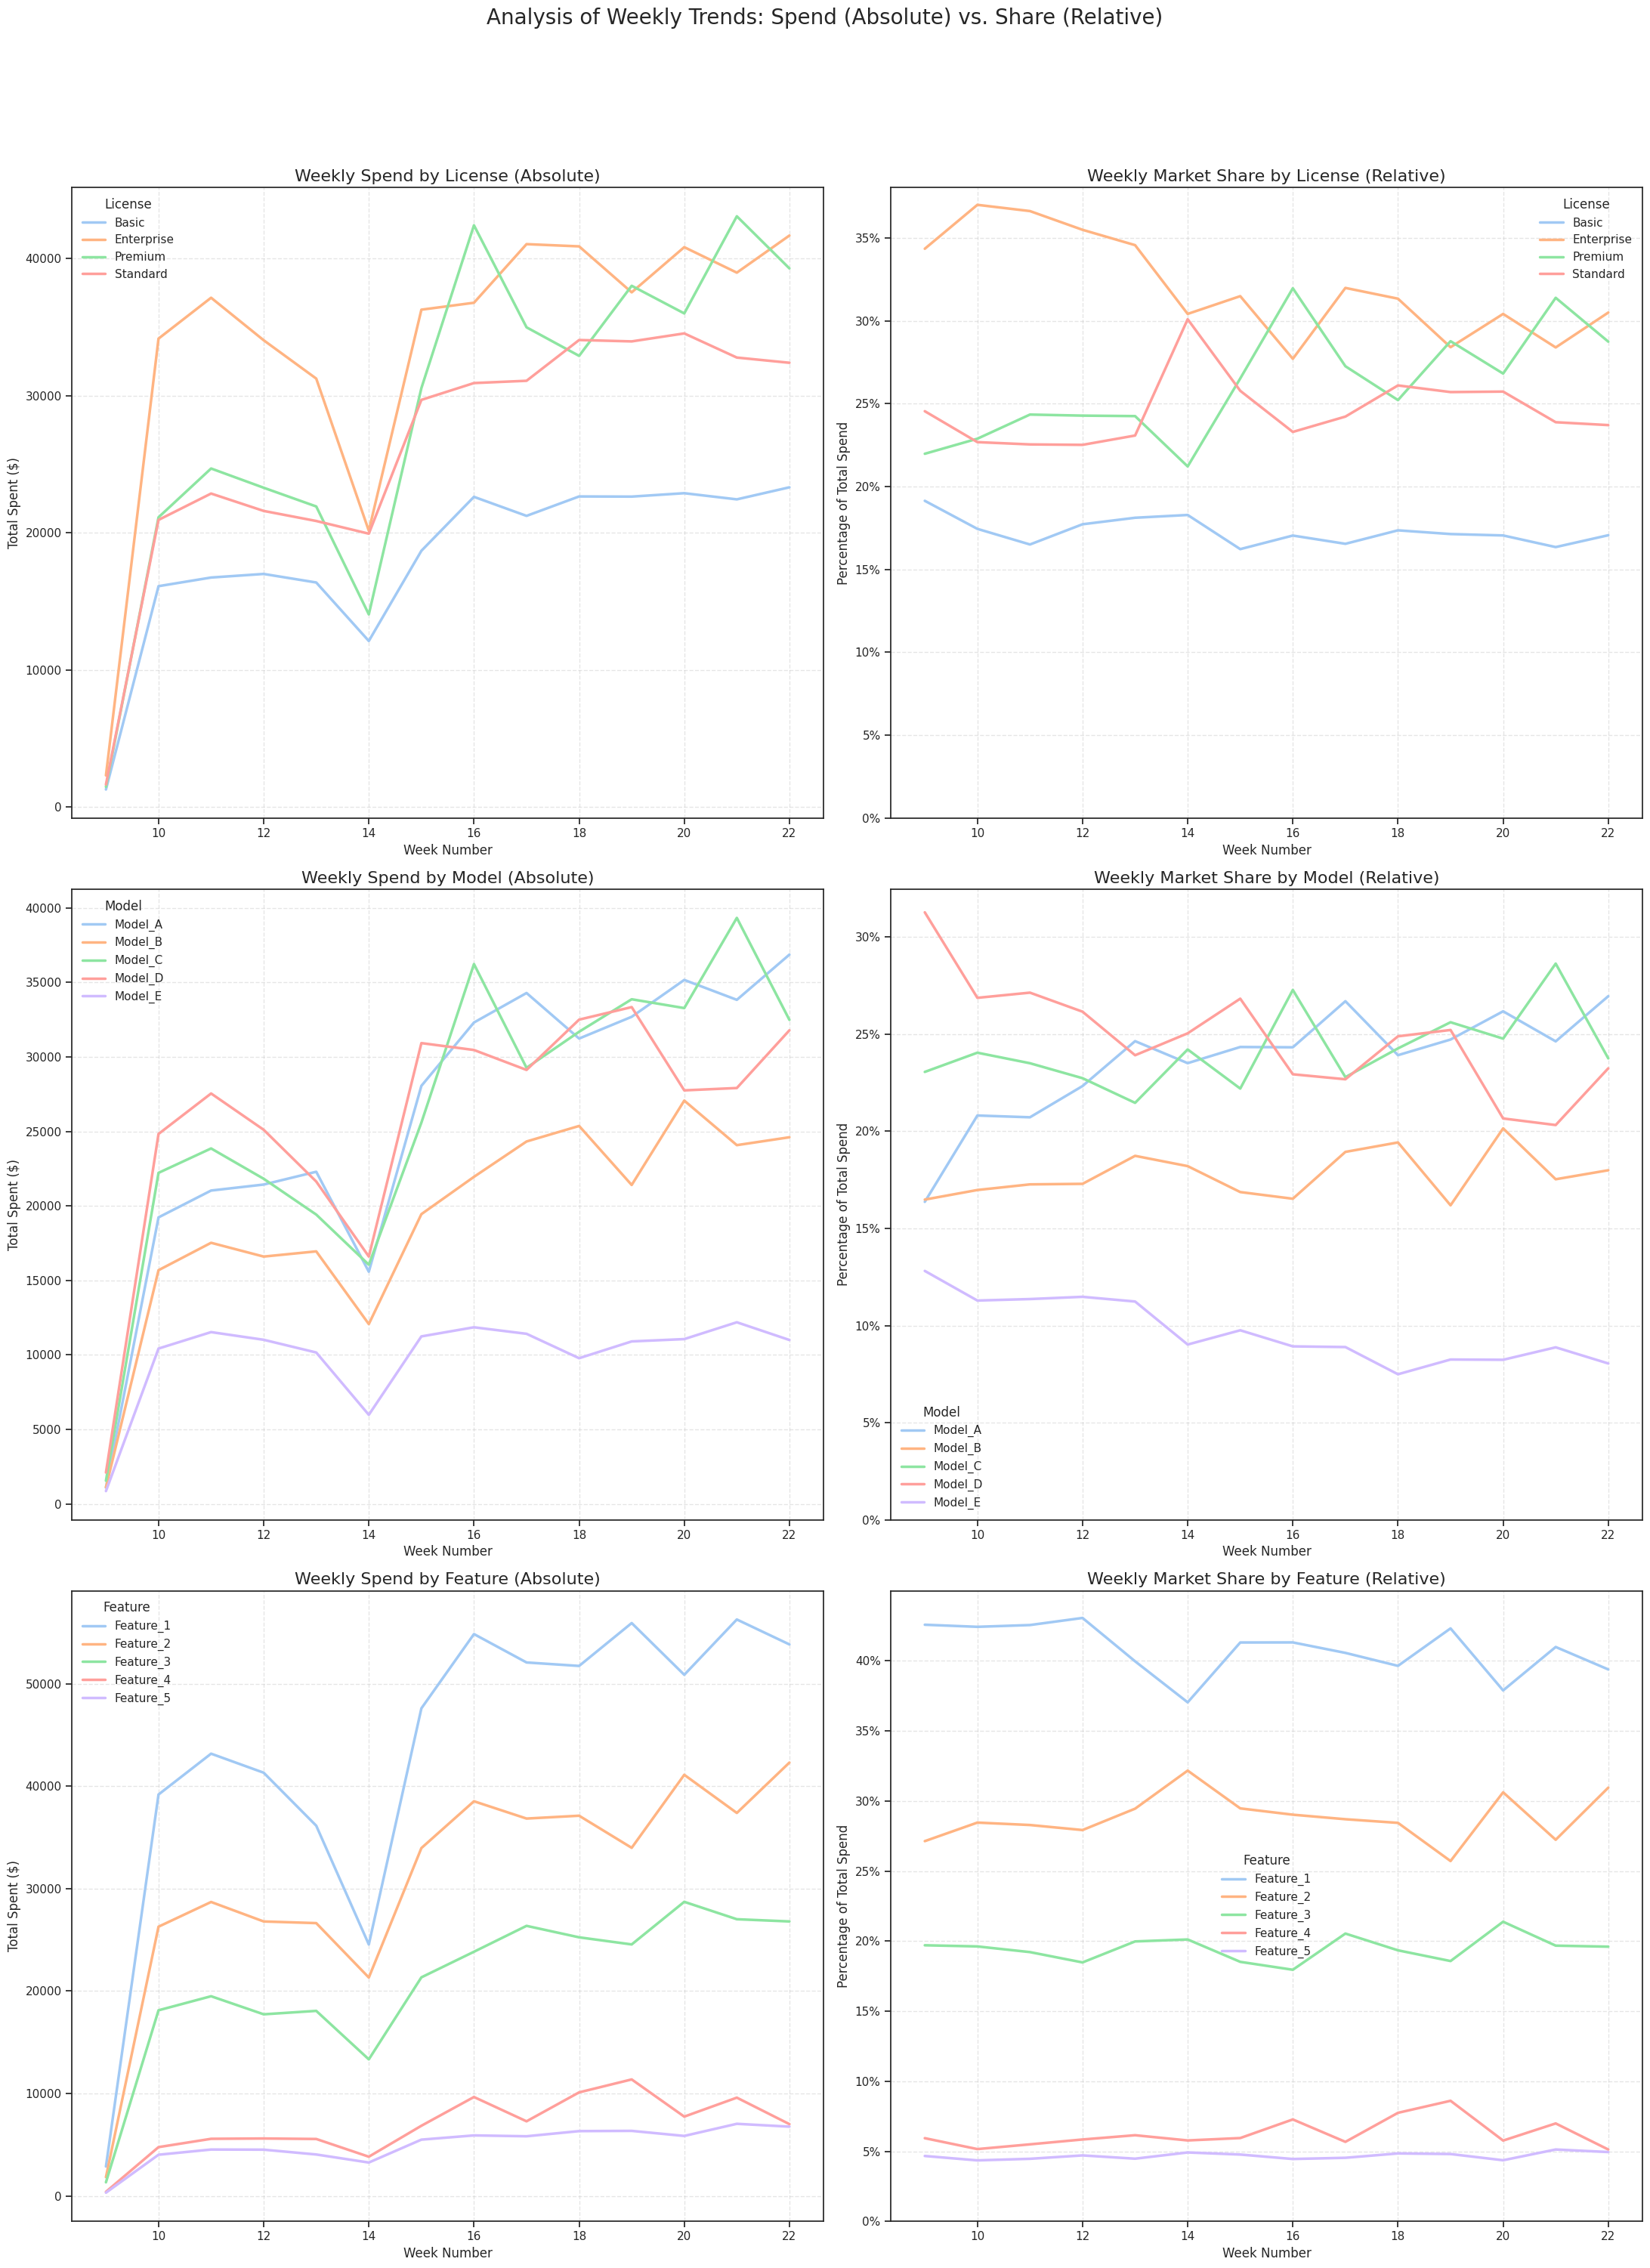

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
from IPython.display import display

print("--- 8.1. Monthly Trend Summary ---")

month_order = ['March', 'April', 'May']
monthly_total_spent = df.groupby('month_name')['spent_amount'].sum().reindex(month_order)

monthly_license = df.groupby(['month_name', 'license'])['spent_amount'].sum().unstack().reindex(month_order)
monthly_license_share = monthly_license.divide(monthly_total_spent, axis=0).fillna(0)
print("\n--- Monthly Spend & Share: LICENSE ---")
display(pd.concat([
    monthly_license.add_prefix('Spend_'),
    monthly_license_share.add_prefix('Share_')
], axis=1))

monthly_model = df.groupby(['month_name', 'model'])['spent_amount'].sum().unstack().reindex(month_order)
monthly_model_share = monthly_model.divide(monthly_total_spent, axis=0).fillna(0)
print("\n--- Monthly Spend & Share: MODEL ---")
display(pd.concat([
    monthly_model.add_prefix('Spend_'),
    monthly_model_share.add_prefix('Share_')
], axis=1))

monthly_feature = df.groupby(['month_name', 'feature'])['spent_amount'].sum().unstack().reindex(month_order)
monthly_feature_share = monthly_feature.divide(monthly_total_spent, axis=0).fillna(0)
print("\n--- Monthly Spend & Share: FEATURE ---")
display(pd.concat([
    monthly_feature.add_prefix('Spend_'),
    monthly_feature_share.add_prefix('Share_')
], axis=1))


print("\n--- 8.2. Plotting 3x2 Weekly Trend Canvas (All Line Plots) ---")

weekly_total_spent = df.groupby('week_number')['spent_amount'].sum()

weekly_license_spend = df.groupby(['week_number', 'license'])['spent_amount'].sum().unstack().fillna(0)
weekly_license_share = weekly_license_spend.divide(weekly_total_spent, axis=0).fillna(0)
license_list = weekly_license_spend.columns.tolist()

weekly_model_spend = df.groupby(['week_number', 'model'])['spent_amount'].sum().unstack().fillna(0)
weekly_model_share = weekly_model_spend.divide(weekly_total_spent, axis=0).fillna(0)
model_list = weekly_model_spend.columns.tolist()

weekly_feature_spend = df.groupby(['week_number', 'feature'])['spent_amount'].sum().unstack().fillna(0)
weekly_feature_share = weekly_feature_spend.divide(weekly_total_spent, axis=0).fillna(0)
feature_list = weekly_feature_spend.columns.tolist()


fig, axes = plt.subplots(3, 2, figsize=(22, 30))
fig.suptitle('Analysis of Weekly Trends: Spend (Absolute) vs. Share (Relative)', fontsize=20, y=1.03)
week_index = weekly_total_spent.index

ax = axes[0, 0]
for lic in license_list:
    sns.lineplot(x=week_index, y=weekly_license_spend[lic], ax=ax, label=lic, linewidth=2.5)
ax.set_title('Weekly Spend by License (Absolute)', fontsize=16)
ax.set_ylabel('Total Spent ($)', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='License')
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[0, 1]
for lic in license_list:
    sns.lineplot(x=week_index, y=weekly_license_share[lic], ax=ax, label=lic, linewidth=2.5)
ax.set_title('Weekly Market Share by License (Relative)', fontsize=16)
ax.set_ylabel('Percentage of Total Spend', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='License')
ax.set_ylim(0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1, 0]
for mod in model_list:
    sns.lineplot(x=week_index, y=weekly_model_spend[mod], ax=ax, label=mod, linewidth=2.5)
ax.set_title('Weekly Spend by Model (Absolute)', fontsize=16)
ax.set_ylabel('Total Spent ($)', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Model')
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[1, 1]
for mod in model_list:
    sns.lineplot(x=week_index, y=weekly_model_share[mod], ax=ax, label=mod, linewidth=2.5)
ax.set_title('Weekly Market Share by Model (Relative)', fontsize=16)
ax.set_ylabel('Percentage of Total Spend', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Model')
ax.set_ylim(0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[2, 0]
for feat in feature_list:
    sns.lineplot(x=week_index, y=weekly_feature_spend[feat], ax=ax, label=feat, linewidth=2.5)
ax.set_title('Weekly Spend by Feature (Absolute)', fontsize=16)
ax.set_ylabel('Total Spent ($)', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Feature')
ax.grid(True, linestyle='--', alpha=0.5)

ax = axes[2, 1]
for feat in feature_list:
    sns.lineplot(x=week_index, y=weekly_feature_share[feat], ax=ax, label=feat, linewidth=2.5)
ax.set_title('Weekly Market Share by Feature (Relative)', fontsize=16)
ax.set_ylabel('Percentage of Total Spend', fontsize=12)
ax.set_xlabel('Week Number', fontsize=12)
ax.legend(title='Feature')
ax.set_ylim(0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()